In [1]:
from google.colab import drive
drive.mount('/content/drive')

ModuleNotFoundError: No module named 'google'

In [ ]:
import torch
DER_CKPT_PATH = "/content/drive/MyDrive/DECEN/best_sentence_level_bert_focal.pt"
ckpt = torch.load(DER_CKPT_PATH)
print(f"情緒類別清單: {ckpt['label2id']}")
print(f"類別數量: {len(ckpt['label2id'])}")

情緒類別清單: {'O': 0, 'D': 1, 'W': 2, 'A': 3, 'U': 4}
類別數量: 5


# 2/25 decen

In [ ]:
!pip install -q numpy==1.26.4 transformers==4.44.2 accelerate==0.33.0 matplotlib seaborn sklearn

ERROR: Could not find a version that satisfies the requirement numpy==1.26.4
ERROR: No matching distribution found for numpy==1.26.4


In [ ]:
pip install -U --force-reinstall transformers==4.44.2

  Using cached typing_extensions-4.13.2-py3-none-any.whl (45 kB)
  Using cached colorama-0.4.6-py2.py3-none-any.whl (25 kB)
  Attempting uninstall: urllib3
    Found existing installation: urllib3 1.26.4
    Uninstalling urllib3-1.26.4:
      Successfully uninstalled urllib3-1.26.4
  Attempting uninstall: idna
    Found existing installation: idna 2.10
    Uninstalling idna-2.10:
      Successfully uninstalled idna-2.10
  Attempting uninstall: colorama
    Found existing installation: colorama 0.4.4
    Uninstalling colorama-0.4.4:
      Successfully uninstalled colorama-0.4.4
  Attempting uninstall: certifi
    Found existing installation: certifi 2020.12.5
    Uninstalling certifi-2020.12.5:
      Successfully uninstalled certifi-2020.12.5
  Attempting uninstall: typing-extensions
    Found existing installation: typing-extensions 4.13.2
    Uninstalling typing-extensions-4.13.2:
      Successfully uninstalled typing-extensions-4.13.2
  Attempting uninstall: tqdm
    Found existing i

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
conda-repo-cli 1.0.4 requires pathlib, which is not installed.
anaconda-project 0.9.1 requires ruamel-yaml, which is not installed.
scipy 1.6.2 requires numpy<1.23.0,>=1.16.5, but you have numpy 1.24.4 which is incompatible.
pylint 2.7.4 requires astroid<2.7,>=2.5.2, but you have astroid 2.5 which is incompatible.


In [ ]:
import numpy, transformers, accelerate, sklearn

print("numpy", numpy.__version__)
print("transformers", transformers.__version__)
print("accelerate", accelerate.__version__)
print("sklearn", sklearn.__version__)
# numpy 1.26.4
# transformers 4.44.2
# accelerate 0.33.0
# sklearn 1.6.1


ModuleNotFoundError: No module named 'accelerate'

In [ ]:
import pandas as pd

# ========= 1) 檔案路徑 =========
df1_path = "/content/drive/MyDrive/DECEN/post_level_dataset_800.csv"
df2_path = "/content/drive/MyDrive/few-shot/merged_stage3_full.csv"

# ========= 2) 讀取資料 =========
df1 = pd.read_csv(df1_path)
df2 = pd.read_csv(df2_path)

print("df1 columns:", df1.columns.tolist())
print("df2 columns:", df2.columns.tolist())
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)

# ========= 3) df2 取唯一 post_id + caption =========
# 只保留你需要的欄位
df2_post = df2[["post_id", "caption"]].copy()

# 去除重複（因為 df2 是 word-level，會有很多重複 post_id/caption）
df2_post = df2_post.drop_duplicates(subset=["post_id", "caption"]).reset_index(drop=True)

# 新增標籤 y=1
df2_post["y"] = 1

print("df2_post (unique post-level) shape:", df2_post.shape)
display(df2_post.head())

# ========= 4) df1 欄位整理（只保留 post-level 需要欄位） =========
# 如果 df1 已經就是 post_id, caption, y，這段也可保留當保險
df1_post = df1[["post_id", "caption", "y"]].copy()

# ========= 5) 合併 df1 + df2_post =========
merged = pd.concat([df1_post, df2_post], ignore_index=True)

# ========= 6) 去除重複（避免 df1 本來已有相同貼文） =========
# 如果同一 post_id + caption 重複，只保留第一筆
merged = merged.drop_duplicates(subset=["post_id", "caption"], keep="first").reset_index(drop=True)

print("merged shape:", merged.shape)
print("label distribution:")
print(merged["y"].value_counts(dropna=False))

display(merged.head(10))

# ========= 7) 儲存 =========
out_path = "/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv"
merged.to_csv(out_path, index=False, encoding="utf-8-sig")

print(f"✅ 已儲存：{out_path}")

df1 columns: ['post_id', 'caption', 'y']
df2 columns: ['post_id', 'caption', 'word', 'human_label', 'gpt_label_1', 'gpt_label_2', 'gpt_label_3', 'gpt_label_4', 'gpt_label_5', 'word_order']
df1 shape: (800, 3)
df2 shape: (9030, 10)
df2_post (unique post-level) shape: (200, 3)


,post_id,caption,y
0,801,你知道什麼是愛？不是一個句子，也不是一個表情符號，可能還是一個人的無法形容的感覺。今天我感到...,1
1,802,每天都有新的開始，然而每天的開始都像是一個長期無人之地。 我開始失去興趣了，我的自信心也開始...,1
2,803,每天也一樣這樣，缺乏那種興奮和對未來的期待，現在的生活像是無目的的旅行。 我開始忘記自己想要...,1
3,804,我覺得我每天都在走在灰色地帶。每天不再有那樣的興趣，我什麼也沒好好想看或玩。雖然我知道這不是...,1
4,805,我最近什麼都不想做了。 這是輕微的失望，但它讓我感到無法突破的困擾感。 這種感受似乎很常...,1


merged shape: (963, 3)
label distribution:
y
1    576
0    387
Name: count, dtype: int64


,post_id,caption,y
0,keke.lifediary,‼️更正第8項為：誠品480商場‼️\n \n👇🏻加入keke大家庭👇🏻\nKeke 帶我去...,0
1,yahoofoodhongkong,主打蛋包飯的「米青蛋包飯公司」是人氣番茄湯麵專門店「番茄師兄」的姊妹店，數月前進駐荔枝角D2...,0
2,2569713370816930416_3218617152,.\n最近每天晚上都在哭，但我並不希望停止哭泣；我最不想成為的，就是再也不會因為分離而哭的人...,1
3,hao_emo520,更新文案⬇️\n🌃進入主頁 @hao_emo520\n.\n.\n.\n#十二星座#摩羯#水...,0
4,2558235872593928150_3218617152,活著好難，活著真的真的好難。\n我不懂我做錯了什麼。,1
5,keke.lifediary,還有什麼尷尬時刻XDD??\n留言分享一下吧🙌\n\n👇🏻加入keke大家庭👇🏻\nKeke...,0
6,3194991693095595546_5611656677,｜2023.9.19｜\n⁡\n 這裡已經是我唯一的所在了，現實裡的歸屬感都沒有在這個帳號裡...,1
7,i.m_lizfish_,-\n愛笑的人運氣不會太差☺️\n-\n#日常 #街拍 #夜晚 #daily #night,0
8,amerio_daily,原來麻辣燙係米線界嘅自由斟🤣🤣\n\n我第一次可以將寬粉、薯粉、米線同粉絲等\n撈埋喺同一個...,0
9,doll.baby1314,我知道有三個人喜歡你嗎？\n我，我啊，就是我🤗\nline領取完整版🔥⏩ @571cscom...,0


✅ 已儲存：/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv


In [ ]:
import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, cohen_kappa_score, roc_auc_score
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ============================================
# 1. 全域設定與種子固定
# ============================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 路徑設定
DER_CKPT_PATH = "/content/drive/MyDrive/DECEN/best_sentence_level_bert_focal.pt"
POST_CSV = "/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv"
SAVE_DIR = "/content/drive/MyDrive/DECEN/"
PRECOMPUTED_PATH = os.path.join(SAVE_DIR, "precomputed_features.pt")
MODEL_NAME = "bert-base-chinese"

# 超參數
MAX_SENT_LEN = 128
MAX_SENTS_PER_POST = 20
EMO_DIM = 128
DD_HIDDEN = 128
BATCH_SIZE = 16 # 預算完後 Batch Size 可以調大
# LR = 1e-5 #2e-5
EPOCHS = 20

# ============================================
# 修改後的 Optimizer 設定 (分層學習率)
# ============================================

# ============================================
# 2. 損失函數：Focal Loss (對齊論文 alpha=0.5)
# ============================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# ============================================
# 3. 模型定義 (DER 與修正後的 DECEN)
# ============================================

class DER_Inference(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.classifier = nn.Linear(768, n)
    def forward(self, ids, mask):
        out = self.bert(ids, mask)
        return self.classifier(out.last_hidden_state[:, 0])

class ECR_Module(nn.Module):
    """
    對齊 DECEN 論文的 Emotion-Context Relationship 模組
    公式: alpha = softmax(v^T * tanh(W_e * Re + W_c * Rc + b))
    """
    def __init__(self, emo_dim, ctx_dim):
        super().__init__()
        self.W_e = nn.Linear(emo_dim, emo_dim)
        self.W_c = nn.Linear(ctx_dim, emo_dim)
        self.v = nn.Linear(emo_dim, 1, bias=False)

    def forward(self, Re, Rc, mask):
        # Re: (B, T, Emo_dim), Rc: (B, T, Ctx_dim)
        combined = torch.tanh(self.W_e(Re) + self.W_c(Rc)) # (B, T, Emo_dim)
        score = self.v(combined).squeeze(-1) # (B, T)
        score = score.masked_fill(~mask, -1e9)
        alpha = torch.softmax(score, dim=1) # (B, T)
        return alpha

class DECEN_Model(nn.Module):
    def __init__(self, emo_class_num, emo_dim, dd_hidden):
        super().__init__()
        self.emo_proj = nn.Linear(emo_class_num, emo_dim)
        self.ctx_down = nn.Linear(768, emo_dim) # 將 768 降維到與 emo_dim 一致以便融合

        # ECR 模組
        self.ecr = ECR_Module(emo_dim, 768)

        # DD 模組 (BiLSTM)
        self.bilstm = nn.LSTM(emo_dim, dd_hidden, batch_first=True, bidirectional=True)
        self.classifier = nn.Linear(dd_hidden * 2, 2)


    def forward(self, Rc_pad, Re_probs_pad, lengths, mask, ablation="full"):
        # 1. 情緒特徵投影
        Re_pad = self.emo_proj(Re_probs_pad) # (B, T, Emo_dim)
        Rc_low = self.ctx_down(Rc_pad)       # (B, T, Emo_dim)

        # 2. ECR 融合 (依據論文論文公式 R~ = alpha * Rc + Re)

        if ablation == "no_ecr":
            R_tilde = Rc_low + Re_pad
        elif ablation == "no_emotion":
            R_tilde = Rc_low
        elif ablation == "no_context":
            R_tilde = Re_pad
        else:
            alpha = self.ecr(Re_pad, Rc_pad, mask) # (B, T)
            R_tilde = alpha.unsqueeze(-1) * Rc_low + Re_pad

        # 3. BiLSTM 分類
        packed = nn.utils.rnn.pack_padded_sequence(R_tilde, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.bilstm(packed)
        feat = torch.cat((hn[-2], hn[-1]), dim=-1) # 拼接雙向最後狀態
        return self.classifier(feat)

# ============================================
# 4. 預處理階段：提取特徵並儲存
# ============================================

SENT_SPLIT_RE = re.compile(r'([。！？!?\n]+)')

def split_sentences(text):
    text = str(text).strip()
    if not text: return [" "]
    parts = SENT_SPLIT_RE.split(text)
    sents, buf = [], ""
    for part in parts:
        if not part: continue
        buf += part
        if SENT_SPLIT_RE.fullmatch(part):
            sents.append(buf.strip()); buf = ""
    if buf.strip(): sents.append(buf.strip())
    return sents[:MAX_SENTS_PER_POST]

def precompute_features():
    if os.path.exists(PRECOMPUTED_PATH):
        print("偵測到預算特徵，跳過預處理...")
        return torch.load(PRECOMPUTED_PATH)

    print("開始預處理：提取 BERT 與 情緒向量 (此過程僅執行一次)...")
    df = pd.read_csv(POST_CSV)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # 載入 DER 模型
    ckpt = torch.load(DER_CKPT_PATH, map_location=device)
    der_model = DER_Inference(len(ckpt["label2id"])).to(device)
    der_model.load_state_dict(ckpt["model_state"], strict=False)
    der_model.eval()

    # 載入基礎 BERT
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
    base_bert.eval()

    all_data = []

    with torch.no_grad():
        for i, row in tqdm(df.iterrows(), total=len(df)):
            sents = split_sentences(row["caption"])
            num_s = len(sents)

            # Tokenization
            inputs = tokenizer(sents, truncation=True, padding=True, max_length=MAX_SENT_LEN, return_tensors="pt").to(device)

            # 1. 提取 Context Embedding (Rc)
            outputs = base_bert(**inputs)
            Rc = outputs.last_hidden_state[:, 0, :].cpu() # (num_s, 768)

            # 2. 提取 Emotion Probs (Re)
            der_logits = der_model(inputs["input_ids"], inputs["attention_mask"])
            Re_probs = torch.softmax(der_logits, dim=-1).cpu() # (num_s, emo_class_num)

            all_data.append({
                "Rc": Rc,
                "Re_probs": Re_probs,
                "y": int(row["y"]),
                "num_s": num_s
            })

    torch.save(all_data, PRECOMPUTED_PATH)
    return all_data

# ============================================
# 5. 訓練用 Dataset 與 DataLoader
# ============================================

class PrecomputedDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def precomputed_collate_fn(batch):
    B = len(batch)
    lengths = torch.tensor([b["num_s"] for b in batch], dtype=torch.long)
    T_max = lengths.max().item()

    ctx_dim = batch[0]["Rc"].shape[1]
    emo_dim = batch[0]["Re_probs"].shape[1]

    Rc_pad = torch.zeros((B, T_max, ctx_dim))
    Re_probs_pad = torch.zeros((B, T_max, emo_dim))
    mask = torch.zeros((B, T_max), dtype=torch.bool)
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.long)

    for i, b in enumerate(batch):
        l = b["num_s"]
        Rc_pad[i, :l] = b["Rc"]
        Re_probs_pad[i, :l] = b["Re_probs"]
        mask[i, :l] = True

    return {
        "Rc": Rc_pad.to(device),
        "Re_probs": Re_probs_pad.to(device),
        "lengths": lengths.to(device),
        "mask": mask.to(device),
        "ys": ys.to(device)
    }

# ============================================
# 6. 主執行程式
# ============================================


# 第一步：預算
all_precomputed_data = precompute_features()

# 第二步：切割資料
train_data, test_data = train_test_split(all_precomputed_data, test_size=0.2, random_state=42)

# 第三步：實驗迴圈
SEEDS = [1, 7, 13, 21, 42]
ABLATION_MODES = ["full", "no_ecr", "no_emotion", "no_context"]
all_results = []

# 取得情緒類別數量 (從預算資料中取得)
emo_class_num = all_precomputed_data[0]["Re_probs"].shape[1]

for mode in ABLATION_MODES:
    for seed in SEEDS:
        print(f"\n>>> 執行: 模式={mode}, Seed={seed} <<<")
        seed_everything(seed)

        train_loader = DataLoader(PrecomputedDataset(train_data), batch_size=BATCH_SIZE, shuffle=True, collate_fn=precomputed_collate_fn)
        test_loader = DataLoader(PrecomputedDataset(test_data), batch_size=BATCH_SIZE, collate_fn=precomputed_collate_fn)

        model = DECEN_Model(emo_class_num, EMO_DIM, DD_HIDDEN).to(device)
        # optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
        # 1. 將參數分組
        # 我們希望 ecr 模組和 classifier 使用較大的 LR (1e-4)
        # 其餘部分 (主要是 ctx_down 和 emo_proj) 使用較小的 LR (1e-5)
        head_params = list(model.ecr.parameters()) + list(model.classifier.parameters())
        base_params = [p for n, p in model.named_parameters() if "ecr" not in n and "classifier" not in n]

        optimizer = torch.optim.AdamW([
           {'params': base_params, 'lr': 1e-5},      # 基礎層使用小 LR
           {'params': head_params, 'lr': 1e-4}       # ECR 與分類器使用大 LR
        ], weight_decay=0.01)

        print(f"Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4")

        criterion = FocalLoss(alpha=0.5) # 對齊論文

        best_f1 = -1

        for epoch in range(EPOCHS):
            model.train()
            for batch in train_loader:
                logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                loss = criterion(logits, batch["ys"])
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            # 評估
            model.eval()
            all_preds, all_labels, all_probs = [], [], []
            with torch.no_grad():
                for batch in test_loader:
                    out = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                    all_probs.extend(torch.softmax(out, dim=-1)[:, 1].cpu().numpy())
                    all_preds.extend(out.argmax(dim=-1).cpu().numpy())
                    all_labels.extend(batch["ys"].cpu().numpy())

            p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_metrics = {
                    "mode": mode, "seed": seed, "f1": f1, "precision": p, "recall": r,
                    "accuracy": accuracy_score(all_labels, all_preds),
                    "kappa": cohen_kappa_score(all_labels, all_preds),
                    "auc": roc_auc_score(all_labels, all_probs)
                }
              # 【新增】儲存當前模式下最強的模型權重
                save_path = os.path.join(SAVE_DIR, f"best_decen_{mode}_seed{seed}.pt")
                torch.save(model.state_dict(), save_path)
                print(f"找到更強的模型！已儲存至: {save_path}")

        all_results.append(best_metrics)
        print(f"完成! Best F1: {best_f1:.4f}")

# 顯示最終結果
results_df = pd.DataFrame(all_results)
print("\n--- 實驗總結報告 ---")
print(results_df.groupby("mode").agg(["mean", "std"]).drop(columns="seed"))

偵測到預算特徵，跳過預處理...

>>> 執行: 模式=full, Seed=1 <<<
Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
完成! Best F1: 0.9328

>>> 執行: 模式=full, Seed=7 <<<
Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed7.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed7.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best

In [ ]:

import os
import re
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, cohen_kappa_score, roc_auc_score
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm

# ============================================
# 1. 全域設定與種子固定
# ============================================
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 路徑設定
DER_CKPT_PATH = "/content/drive/MyDrive/DECEN/best_sentence_level_bert_focal.pt"
POST_CSV = "/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv"
SAVE_DIR = "/content/drive/MyDrive/DECEN/"
PRECOMPUTED_PATH = os.path.join(SAVE_DIR, "precomputed_features.pt")
MODEL_NAME = "bert-base-chinese"

# 超參數
MAX_SENT_LEN = 128
MAX_SENTS_PER_POST = 20
EMO_DIM = 128
DD_HIDDEN = 128
BATCH_SIZE = 16 # 預算完後 Batch Size 可以調大
# LR = 1e-5 #2e-5
EPOCHS = 10

# ============================================
# 修改後的 Optimizer 設定 (分層學習率)
# ============================================


# ============================================
# 2. 損失函數：Focal Loss (對齊論文 alpha=0.5)
# ============================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return focal_loss.mean()

# ============================================
# 3. 模型定義 (DER 與修正後的 DECEN)
# ============================================

class DER_Inference(nn.Module):
    def __init__(self, n):
        super().__init__()
        self.bert = AutoModel.from_pretrained(MODEL_NAME)
        self.classifier = nn.Linear(768, n)
    def forward(self, ids, mask):
        out = self.bert(ids, mask)
        return self.classifier(out.last_hidden_state[:, 0])

class ECR_Module(nn.Module):
    """
    對齊 DECEN 論文的 Emotion-Context Relationship 模組
    公式: alpha = softmax(v^T * tanh(W_e * Re + W_c * Rc + b))
    """
    def __init__(self, emo_dim, ctx_dim):
        super().__init__()
        self.W_e = nn.Linear(emo_dim, emo_dim)
        self.W_c = nn.Linear(ctx_dim, emo_dim)
        self.v = nn.Linear(emo_dim, 1, bias=False)
        # self.dropout = nn.Dropout(0.1) # 加入這行

    def forward(self, Re, Rc, mask):
        # Re: (B, T, Emo_dim), Rc: (B, T, Ctx_dim)
        combined = torch.tanh(self.W_e(Re) + self.W_c(Rc)) # (B, T, Emo_dim)
        # combined = self.dropout(combined) # 加入這行
        score = self.v(combined).squeeze(-1) # (B, T)
        score = score.masked_fill(~mask, -1e9)
        alpha = torch.softmax(score, dim=1) # (B, T)
        return alpha

class DECEN_Model(nn.Module):
    def __init__(self, emo_class_num, emo_dim, dd_hidden):
        super().__init__()
        self.emo_proj = nn.Linear(emo_class_num, emo_dim)
        self.ctx_down = nn.Linear(768, emo_dim)

        self.ecr = ECR_Module(emo_dim, 768)
        self.bilstm = nn.LSTM(emo_dim, dd_hidden, batch_first=True, bidirectional=True)

        # 增加一個 LayerNorm 穩定特徵分布
        self.norm = nn.LayerNorm(emo_dim)
        self.classifier = nn.Linear(dd_hidden * 2, 2)

    def forward(self, Rc_pad, Re_probs_pad, lengths, mask, ablation="full"):
        Re_pad = self.emo_proj(Re_probs_pad) # (B, T, Emo_dim)
        Rc_low = self.ctx_down(Rc_pad)       # (B, T, Emo_dim)

        if ablation == "full":
            alpha = self.ecr(Re_pad, Rc_pad, mask) # (B, T)
            # 修正：殘差結構。Rc_low 是主幹，alpha 調節 Re_pad 的注入
            # 這樣即便 alpha 學不好，Rc_low 的訊息也能完整保留
            R_tilde = self.norm(Rc_low + (alpha.unsqueeze(-1) * Re_pad))

        elif ablation == "no_ecr":
            R_tilde = self.norm(Rc_low + Re_pad)
        elif ablation == "no_emotion":
            R_tilde = Rc_low
        elif ablation == "no_context":
            R_tilde = Re_pad
        else:
            R_tilde = Rc_low

        packed = nn.utils.rnn.pack_padded_sequence(R_tilde, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (hn, _) = self.bilstm(packed)
        feat = torch.cat((hn[-2], hn[-1]), dim=-1)
        return self.classifier(feat)

# ============================================
# 4. 預處理階段：提取特徵並儲存
# ============================================

SENT_SPLIT_RE = re.compile(r'([。！？!?\n]+)')

def split_sentences(text):
    text = str(text).strip()
    if not text: return [" "]
    parts = SENT_SPLIT_RE.split(text)
    sents, buf = [], ""
    for part in parts:
        if not part: continue
        buf += part
        if SENT_SPLIT_RE.fullmatch(part):
            sents.append(buf.strip()); buf = ""
    if buf.strip(): sents.append(buf.strip())
    return sents[:MAX_SENTS_PER_POST]

def precompute_features():
    if os.path.exists(PRECOMPUTED_PATH):
        print("偵測到預算特徵，跳過預處理...")
        return torch.load(PRECOMPUTED_PATH)

    print("開始預處理：提取 BERT 與 情緒向量 (此過程僅執行一次)...")
    df = pd.read_csv(POST_CSV)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # 載入 DER 模型
    ckpt = torch.load(DER_CKPT_PATH, map_location=device)
    der_model = DER_Inference(len(ckpt["label2id"])).to(device)
    der_model.load_state_dict(ckpt["model_state"], strict=False)
    der_model.eval()

    # 載入基礎 BERT
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device)
    base_bert.eval()

    all_data = []

    with torch.no_grad():
        for i, row in tqdm(df.iterrows(), total=len(df)):
            sents = split_sentences(row["caption"])
            num_s = len(sents)

            # Tokenization
            inputs = tokenizer(sents, truncation=True, padding=True, max_length=MAX_SENT_LEN, return_tensors="pt").to(device)

            # 1. 提取 Context Embedding (Rc)
            outputs = base_bert(**inputs)
            Rc = outputs.last_hidden_state[:, 0, :].cpu() # (num_s, 768)

            # 2. 提取 Emotion Probs (Re)
            der_logits = der_model(inputs["input_ids"], inputs["attention_mask"])
            Re_probs = torch.softmax(der_logits, dim=-1).cpu() # (num_s, emo_class_num)

            all_data.append({
                "Rc": Rc,
                "Re_probs": Re_probs,
                "y": int(row["y"]),
                "num_s": num_s
            })

    torch.save(all_data, PRECOMPUTED_PATH)
    return all_data

# ============================================
# 5. 訓練用 Dataset 與 DataLoader
# ============================================

class PrecomputedDataset(Dataset):
    def __init__(self, data_list):
        self.data = data_list
    def __len__(self):
        return len(self.data)
    def __getitem__(self, idx):
        return self.data[idx]

def precomputed_collate_fn(batch):
    B = len(batch)
    lengths = torch.tensor([b["num_s"] for b in batch], dtype=torch.long)
    T_max = lengths.max().item()

    ctx_dim = batch[0]["Rc"].shape[1]
    emo_dim = batch[0]["Re_probs"].shape[1]

    Rc_pad = torch.zeros((B, T_max, ctx_dim))
    Re_probs_pad = torch.zeros((B, T_max, emo_dim))
    mask = torch.zeros((B, T_max), dtype=torch.bool)
    ys = torch.tensor([b["y"] for b in batch], dtype=torch.long)

    for i, b in enumerate(batch):
        l = b["num_s"]
        Rc_pad[i, :l] = b["Rc"]
        Re_probs_pad[i, :l] = b["Re_probs"]
        mask[i, :l] = True

    return {
        "Rc": Rc_pad.to(device),
        "Re_probs": Re_probs_pad.to(device),
        "lengths": lengths.to(device),
        "mask": mask.to(device),
        "ys": ys.to(device)
    }

# ============================================
# 6. 主執行程式
# ============================================

# 第一步：預算
all_precomputed_data = precompute_features()

# 第二步：切割資料
train_data, test_data = train_test_split(all_precomputed_data, test_size=0.2, random_state=42)

# 第三步：實驗迴圈
SEEDS = [1, 7, 13, 21, 42]
ABLATION_MODES = ["full", "no_ecr", "no_emotion", "no_context"]
all_results = []

# 取得情緒類別數量 (從預算資料中取得)
emo_class_num = all_precomputed_data[0]["Re_probs"].shape[1]

for mode in ABLATION_MODES:
    for seed in SEEDS:
        print(f"\n>>> 執行: 模式={mode}, Seed={seed} <<<")
        seed_everything(seed)

        train_loader = DataLoader(PrecomputedDataset(train_data), batch_size=BATCH_SIZE, shuffle=True, collate_fn=precomputed_collate_fn)
        test_loader = DataLoader(PrecomputedDataset(test_data), batch_size=BATCH_SIZE, collate_fn=precomputed_collate_fn)

        model = DECEN_Model(emo_class_num, EMO_DIM, DD_HIDDEN).to(device)
        # optimizer = torch.optim.AdamW(model.parameters(), lr=LR)
        # 1. 將參數分組
        # 我們希望 ecr 模組和 classifier 使用較大的 LR (1e-4)
        # 其餘部分 (主要是 ctx_down 和 emo_proj) 使用較小的 LR (1e-5)
        head_params = list(model.ecr.parameters()) + list(model.classifier.parameters())
        base_params = [p for n, p in model.named_parameters() if "ecr" not in n and "classifier" not in n]

        optimizer = torch.optim.AdamW([
           {'params': base_params, 'lr': 1e-5},      # 基礎層使用小 LR
           {'params': head_params, 'lr': 1e-4}       # ECR 與分類器使用大 LR
        ], weight_decay=0.01)

        print(f"Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4")

        criterion = FocalLoss(alpha=0.5) # 對齊論文
        # criterion = FocalLoss(alpha=0.75, gamma=2.0) # 提高 alpha 以補償 Recall
        best_f1 = -1

        for epoch in range(EPOCHS):
            model.train()
            for batch in train_loader:
                logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                loss = criterion(logits, batch["ys"])
                optimizer.zero_grad(); loss.backward(); optimizer.step()

            # 評估
            model.eval()
            all_preds, all_labels, all_probs = [], [], []
            with torch.no_grad():
                for batch in test_loader:
                    out = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation=mode)
                    all_probs.extend(torch.softmax(out, dim=-1)[:, 1].cpu().numpy())
                    all_preds.extend(out.argmax(dim=-1).cpu().numpy())
                    all_labels.extend(batch["ys"].cpu().numpy())

            p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary', zero_division=0)
            if f1 > best_f1:
                best_f1 = f1
                best_metrics = {
                    "mode": mode, "seed": seed, "f1": f1, "precision": p, "recall": r,
                    "accuracy": accuracy_score(all_labels, all_preds),
                    "kappa": cohen_kappa_score(all_labels, all_preds),
                    "auc": roc_auc_score(all_labels, all_probs)
                }
                # 【新增】儲存當前模式下最強的模型權重
                save_path = os.path.join(SAVE_DIR, f"best_decen_{mode}_seed{seed}.pt")
                torch.save(model.state_dict(), save_path)
                print(f"找到更強的模型！已儲存至: {save_path}")

        all_results.append(best_metrics)
        print(f"完成! Best F1: {best_f1:.4f}")

# 顯示最終結果
results_df = pd.DataFrame(all_results)
print("\n--- 實驗總結報告 ---")
print(results_df.groupby("mode").agg(["mean", "std"]).drop(columns="seed"))

偵測到預算特徵，跳過預處理...

>>> 執行: 模式=full, Seed=1 <<<
Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed1.pt
完成! Best F1: 0.9791

>>> 執行: 模式=full, Seed=7 <<<
Optimizer 已設定：Base LR = 1e-5, Head (ECR/Cls) LR = 1e-4
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed7.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed7.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best_decen_full_seed7.pt
找到更強的模型！已儲存至: /content/drive/MyDrive/DECEN/best

In [ ]:
# 設定你想使用的特定模型路徑
BEST_MODEL_PATH = "/content/drive/MyDrive/DECEN/best_decen_full_seed42.pt"

# 1. 初始化模型架構 (參數需與訓練時一致)
# emo_class_num 應根據你 precomputed_features 產出的維度設定
model = DECEN_Model(emo_class_num=5, emo_dim=128, dd_hidden=128).to(device)

# 2. 載入權重
if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval() # 切換至評估模式
    print(f"✅ 已成功載入 Full 模式 (Seed 42) 的最強模型！")
else:
    print(f"❌ 找不到檔案，請檢查路徑是否正確：{BEST_MODEL_PATH}")

✅ 已成功載入 Full 模式 (Seed 42) 的最強模型！


In [ ]:
#使用溫度校準 (T=0.1)：讓機率分布重新回歸到強大的雙峰分布（0.9與0.1）。
#採用百分位數門檻：自動找出最可靠的 Top 10% 樣本。
#輸出標註建議 CSV
import pandas as pd
import numpy as np
import torch

def run_semi_auto_labeling(model, unlabeled_loader, device, temperature=0.1, top_k_percent=0.1):
    model.eval()
    all_probs = []

    print(f"正在對未標註資料進行推論 (使用溫度校準 T={temperature})...")

    with torch.no_grad():
        for batch in unlabeled_loader:
            # 獲取原始 Logits
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")

            # 套用溫度校準：Logits / T
            # T < 1 會拉大差距，讓機率更兩極化
            probs = torch.softmax(logits / temperature, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())

    all_probs = np.array(all_probs)

    # 計算百分位數門檻 (基於你的分布)
    upper_bound = np.percentile(all_probs, 100 * (1 - top_k_percent))
    lower_bound = np.percentile(all_probs, 100 * top_k_percent)

    print(f"--- 標註決策報告 ---")
    print(f"經過溫度校準後的機率最大值: {all_probs.max():.4f}")
    print(f"經過溫度校準後的機率最小值: {all_probs.min():.4f}")
    print(f"建議抑鬱門檻 (Top {top_k_percent*100}%): p > {upper_bound:.4f}")
    print(f"建議健康門檻 (Bottom {top_k_percent*100}%): p < {lower_bound:.4f}")

    return all_probs, upper_bound, lower_bound

# 假設你有一份未標註的 dataframe: df_unlabeled
# probs, up, low = run_semi_auto_labeling(model, unlabeled_loader, device)

# df_unlabeled['p_depression'] = probs
# df_unlabeled['pseudo_label'] = -1  # 先預設為未標註
# df_unlabeled.loc[df_unlabeled['p_depression'] > up, 'pseudo_label'] = 1
# df_unlabeled.loc[df_unlabeled['p_depression'] < low, 'pseudo_label'] = 0

# # 儲存結果
# df_labeled = df_unlabeled[df_unlabeled['pseudo_label'] != -1]
# df_labeled.to_csv("pseudo_labeled_data.csv", index=False)

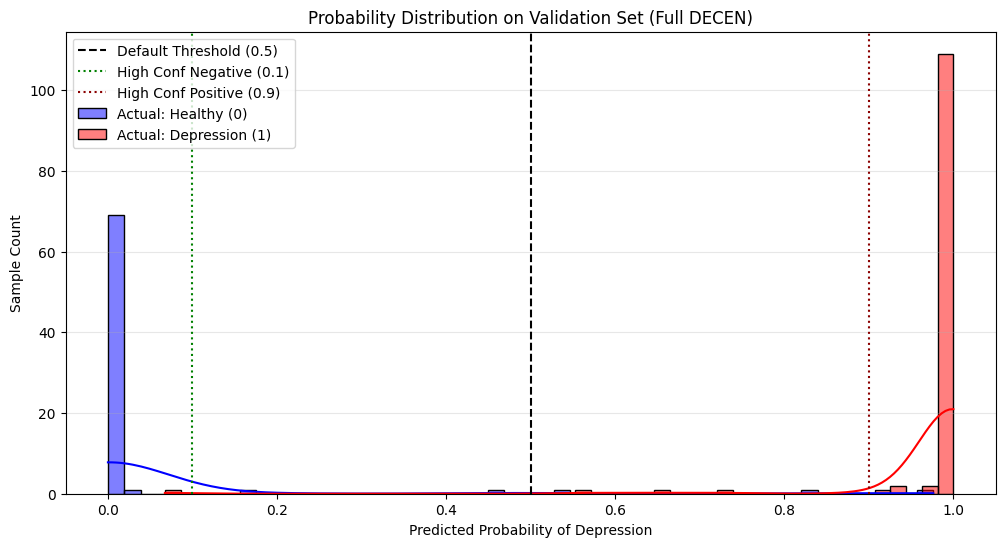

--- 驗證集信心度報告 ---
總樣本數: 193
信心度 > 0.9 的樣本數: 115 筆
  其中標註正確 (True Positive): 114
  其中標註錯誤 (False Positive): 1 (若為 0 則標註極安全)

信心度 < 0.1 的樣本數: 71 筆
  其中標註正確 (True Negative): 70
  其中標註錯誤 (False Negative): 1

模糊地帶 (0.1 <= p <= 0.9): 7 筆 (建議人工覆核區)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def check_val_distribution(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # 使用 Full 模式
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            # probs = torch.softmax(logits, dim=-1)[:, 1] # 取得抑鬱類別 (label=1) 的機率
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["ys"].cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # 繪製圖表
    plt.figure(figsize=(12, 6))

    # 繪製不同標籤的分布
    sns.histplot(all_probs[all_labels == 0], bins=50, color='blue', label='Actual: Healthy (0)', kde=True, alpha=0.5)
    sns.histplot(all_probs[all_labels == 1], bins=50, color='red', label='Actual: Depression (1)', kde=True, alpha=0.5)

    plt.title("Probability Distribution on Validation Set (Full DECEN)")
    plt.xlabel("Predicted Probability of Depression")
    plt.ylabel("Sample Count")
    plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
    plt.axvline(x=0.1, color='green', linestyle=':', label='High Conf Negative (0.1)')
    plt.axvline(x=0.9, color='darkred', linestyle=':', label='High Conf Positive (0.9)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # 統計區間
    total = len(all_probs)
    correct_high_p = np.sum((all_probs > 0.9) & (all_labels == 1))
    wrong_high_p = np.sum((all_probs > 0.9) & (all_labels == 0))

    print(f"--- 驗證集信心度報告 ---")
    print(f"總樣本數: {total}")
    print(f"信心度 > 0.9 的樣本數: {np.sum(all_probs > 0.9)} 筆")
    print(f"  其中標註正確 (True Positive): {correct_high_p}")
    print(f"  其中標註錯誤 (False Positive): {wrong_high_p} (若為 0 則標註極安全)")
    print(f"\n信心度 < 0.1 的樣本數: {np.sum(all_probs < 0.1)} 筆")
    print(f"  其中標註正確 (True Negative): {np.sum((all_probs < 0.1) & (all_labels == 0))}")
    print(f"  其中標註錯誤 (False Negative): {np.sum((all_probs < 0.1) & (all_labels == 1))}")
    mid_count = np.sum((all_probs >= 0.1) & (all_probs <= 0.9))
    print(f"\n模糊地帶 (0.1 <= p <= 0.9): {mid_count} 筆 (建議人工覆核區)")

# 呼叫
check_val_distribution(model, test_loader, device)

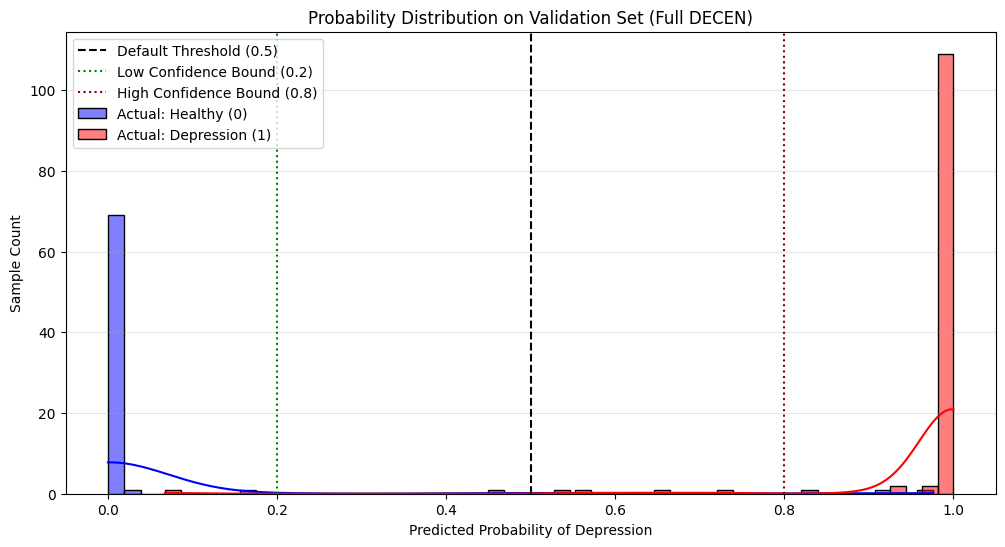

--- 驗證集信心度報告 ---
總樣本數: 193
信心度 > 0.8 (預測抑鬱): 116 筆
  - 正確標記 (True Positive): 114
  - 錯誤標記 (False Positive): 2

信心度 < 0.2 (預測健康): 72 筆
  - 正確標記 (True Negative): 71
  - 錯誤標記 (False Negative): 1

模糊地帶 (0.2 <= p <= 0.8): 5 筆 (建議人工覆核區)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def check_val_distribution(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # 確保使用 Full DECEN 模式
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            # probs = torch.softmax(logits, dim=-1)[:, 1] # 取得 label=1 (抑鬱) 的機率
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["ys"].cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # 繪製圖表
    plt.figure(figsize=(12, 6))

    # 繪製健康樣本 (Label 0) 的分布
    sns.histplot(all_probs[all_labels == 0], bins=50, color='blue', label='Actual: Healthy (0)', kde=True, alpha=0.5)
    # 繪製抑鬱樣本 (Label 1) 的分布
    sns.histplot(all_probs[all_labels == 1], bins=50, color='red', label='Actual: Depression (1)', kde=True, alpha=0.5)

    plt.title("Probability Distribution on Validation Set (Full DECEN)")
    plt.xlabel("Predicted Probability of Depression")
    plt.ylabel("Sample Count")
    plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
    plt.axvline(x=0.2, color='green', linestyle=':', label='Low Confidence Bound (0.2)')
    plt.axvline(x=0.8, color='darkred', linestyle=':', label='High Confidence Bound (0.8)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # 統計報告
    total = len(all_probs)
    high_p_mask = all_probs > 0.8
    low_p_mask = all_probs < 0.2

    print(f"--- 驗證集信心度報告 ---")
    print(f"總樣本數: {total}")
    print(f"信心度 > 0.8 (預測抑鬱): {np.sum(high_p_mask)} 筆")
    print(f"  - 正確標記 (True Positive): {np.sum((high_p_mask) & (all_labels == 1))}")
    print(f"  - 錯誤標記 (False Positive): {np.sum((high_p_mask) & (all_labels == 0))}")

    print(f"\n信心度 < 0.2 (預測健康): {np.sum(low_p_mask)} 筆")
    print(f"  - 正確標記 (True Negative): {np.sum((low_p_mask) & (all_labels == 0))}")
    print(f"  - 錯誤標記 (False Negative): {np.sum((low_p_mask) & (all_labels == 1))}")

    mid_count = np.sum((all_probs >= 0.2) & (all_probs <= 0.8))
    print(f"\n模糊地帶 (0.2 <= p <= 0.8): {mid_count} 筆 (建議人工覆核區)")

# 執行檢查
check_val_distribution(model, test_loader, device)

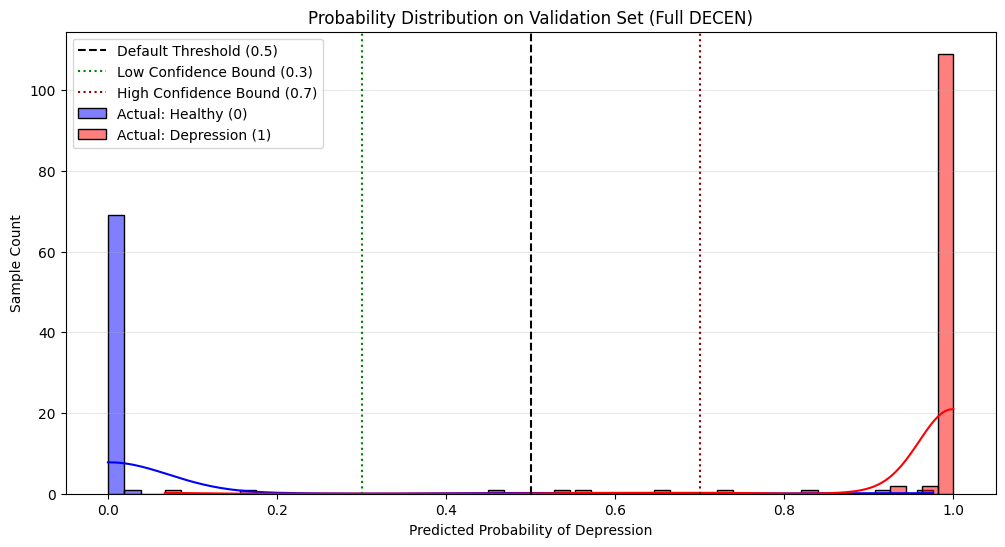

--- 驗證集信心度報告 ---
總樣本數: 193
信心度 > 0.7 (預測抑鬱): 117 筆
  - 正確標記 (True Positive): 115
  - 錯誤標記 (False Positive): 2

信心度 < 0.3 (預測健康): 72 筆
  - 正確標記 (True Negative): 71
  - 錯誤標記 (False Negative): 1

模糊地帶 (0.3 <= p <= 0.7): 4 筆 (建議人工覆核區)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def check_val_distribution(model, dataloader, device):
    model.eval()
    all_probs = []
    all_labels = []

    with torch.no_grad():
        for batch in dataloader:
            # 確保使用 Full DECEN 模式
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            # probs = torch.softmax(logits, dim=-1)[:, 1] # 取得 label=1 (抑鬱) 的機率
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["ys"].cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # 繪製圖表
    plt.figure(figsize=(12, 6))

    # 繪製健康樣本 (Label 0) 的分布
    sns.histplot(all_probs[all_labels == 0], bins=50, color='blue', label='Actual: Healthy (0)', kde=True, alpha=0.5)
    # 繪製抑鬱樣本 (Label 1) 的分布
    sns.histplot(all_probs[all_labels == 1], bins=50, color='red', label='Actual: Depression (1)', kde=True, alpha=0.5)

    plt.title("Probability Distribution on Validation Set (Full DECEN)")
    plt.xlabel("Predicted Probability of Depression")
    plt.ylabel("Sample Count")
    plt.axvline(x=0.5, color='black', linestyle='--', label='Default Threshold (0.5)')
    plt.axvline(x=0.3, color='green', linestyle=':', label='Low Confidence Bound (0.3)')
    plt.axvline(x=0.7, color='darkred', linestyle=':', label='High Confidence Bound (0.7)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # 統計報告
    total = len(all_probs)
    high_p_mask = all_probs > 0.7
    low_p_mask = all_probs < 0.3

    print(f"--- 驗證集信心度報告 ---")
    print(f"總樣本數: {total}")
    print(f"信心度 > 0.7 (預測抑鬱): {np.sum(high_p_mask)} 筆")
    print(f"  - 正確標記 (True Positive): {np.sum((high_p_mask) & (all_labels == 1))}")
    print(f"  - 錯誤標記 (False Positive): {np.sum((high_p_mask) & (all_labels == 0))}")

    print(f"\n信心度 < 0.3 (預測健康): {np.sum(low_p_mask)} 筆")
    print(f"  - 正確標記 (True Negative): {np.sum((low_p_mask) & (all_labels == 0))}")
    print(f"  - 錯誤標記 (False Negative): {np.sum((low_p_mask) & (all_labels == 1))}")

    mid_count = np.sum((all_probs >= 0.3) & (all_probs <= 0.7))
    print(f"\n模糊地帶 (0.3 <= p <= 0.7): {mid_count} 筆 (建議人工覆核區)")

# 執行檢查
check_val_distribution(model, test_loader, device)

In [ ]:
# 請在執行完 check_val_distribution 後執行
print("前 10 筆預測機率值:", all_probs[:10])
print("機率最大值:", np.max(all_probs))
print("機率最小值:", np.min(all_probs))
print("機率平均值:", np.mean(all_probs))

前 10 筆預測機率值: [np.float32(0.52187353), np.float32(0.39117846), np.float32(0.8080514), np.float32(0.6246361), np.float32(0.42889738), np.float32(0.4552214), np.float32(0.45369542), np.float32(0.3837178), np.float32(0.43177858), np.float32(0.43193275)]
機率最大值: 0.83393884
機率最小值: 0.37020072
機率平均值: 0.5521693


# DECEN 半自動標註前1000筆


In [ ]:
import pandas as pd
import os
from pathlib import Path
from collections import defaultdict

# ==================== 設定篩選條件 ====================
folder_path = '/content/drive/MyDrive/depress_dataset/downloaded_media_depress'  # 請根據實際路徑調整

# 篩選條件（可以調整這些參數）
target_years = range(2021, 2026)  # 目標年份範圍：2020-2025
min_posts_in_range = 20  # 在目標年份範圍內至少要有多少筆貼文
min_active_years = 3  # 至少要有幾年有貼文（確保時間跨度夠長）

# ==================== 資料讀取與分析 ====================
user_data = {}
user_year_data = defaultdict(lambda: defaultdict(int))
total_users = 0
total_records = 0

print("正在分析資料...")
for file_name in os.listdir(folder_path):
    if file_name.endswith('_posts.csv'):
        user_name = file_name.replace('_posts.csv', '')
        file_path = os.path.join(folder_path, file_name)

        try:
            df = pd.read_csv(file_path)

            if len(df) > 0:
                # 解析日期
                df['taken_at'] = pd.to_datetime(df['taken_at'], errors='coerce')
                df['year'] = df['taken_at'].dt.year

                # 統計每年的貼文數
                year_counts = df['year'].value_counts().to_dict()

                record_count = len(df)
                user_data[user_name] = {
                    'total': record_count,
                    'years': year_counts
                }

                total_users += 1
                total_records += record_count

                # 記錄每個使用者每年的貼文數
                for year, count in year_counts.items():
                    if pd.notna(year):
                        user_year_data[user_name][int(year)] = count

        except Exception as e:
            print(f"讀取 {file_name} 時發生錯誤: {e}")

# ==================== 整體統計 ====================
print("\n" + "=" * 70)
print("📊 整體統計結果")
print("=" * 70)
print(f"👥 使用者總數: {total_users}")
print(f"📝 總資料筆數: {total_records:,}")
print(f"📈 平均筆數/人: {total_records/total_users:.2f}" if total_users > 0 else "平均筆數/人: 0")

# ==================== 年份分布分析 ====================
print("\n" + "=" * 70)
print("📅 年份分布分析")
print("=" * 70)

all_years = defaultdict(int)
for user, years in user_year_data.items():
    for year, count in years.items():
        all_years[year] += count

years_df = pd.DataFrame([
    {'年份': year, '貼文數': count, '百分比': f"{count/total_records*100:.1f}%"}
    for year, count in sorted(all_years.items())
])
print(years_df.to_string(index=False))

# ==================== 進階篩選分析 ====================
print("\n" + "=" * 70)
print(f"🔍 進階篩選條件（適合時間序列分析）")
print("=" * 70)
print(f"📌 年份範圍: {min(target_years)}-{max(target_years)}")
print(f"📌 最少貼文數: {min_posts_in_range} 筆")
print(f"📌 最少活躍年數: {min_active_years} 年")

# 執行篩選
filtered_users_details = []
for user, info in user_data.items():
    # 計算在目標年份範圍內的貼文數
    posts_in_range = sum(
        count for year, count in info['years'].items()
        if pd.notna(year) and year in target_years
    )

    # 計算在目標年份範圍內有貼文的年數
    active_years_in_range = sum(
        1 for year, count in info['years'].items()
        if pd.notna(year) and year in target_years and count > 0
    )

    # 計算整體活躍年數
    total_active_years = len([y for y in info['years'].keys() if pd.notna(y)])

    # 計算年份跨度
    years_list = [int(y) for y in info['years'].keys() if pd.notna(y)]
    year_span = max(years_list) - min(years_list) + 1 if years_list else 0

    # 判斷是否符合篩選條件
    meets_criteria = (
        posts_in_range >= min_posts_in_range and
        active_years_in_range >= min_active_years
    )

    filtered_users_details.append({
        '使用者名稱': user,
        '總貼文數': info['total'],
        '2021-2025貼文數': posts_in_range,
        '2021-2025活躍年數': active_years_in_range,
        '總活躍年數': total_active_years,
        '年份跨度': year_span,
        '符合條件': '✓' if meets_criteria else '✗'
    })

# 建立結果表格
result_df = pd.DataFrame(filtered_users_details)
result_df = result_df.sort_values('2021-2025貼文數', ascending=False).reset_index(drop=True)
result_df.index = result_df.index + 1

print("\n所有使用者評估結果：")
print(result_df.to_string())

# 統計符合條件的使用者
qualified_users = result_df[result_df['符合條件'] == '✓']
print("\n" + "=" * 70)
print(f"✅ 符合條件的使用者數: {len(qualified_users)} / {total_users}")
print(f"   符合率: {len(qualified_users)/total_users*100:.1f}%")

if len(qualified_users) > 0:
    print(f"\n   這些使用者的統計:")
    print(f"   • 平均貼文數: {qualified_users['總貼文數'].mean():.0f} 筆")
    print(f"   • 平均活躍年數: {qualified_users['2021-2025活躍年數'].mean():.1f} 年")
    print(f"   • 總貼文數: {qualified_users['總貼文數'].sum():,} 筆")

# ==================== 各使用者年份分布詳情 ====================
print("\n" + "=" * 70)
print("👤 各使用者年份分布詳情（僅顯示符合條件的使用者）")
print("=" * 70)

for _, row in qualified_users.iterrows():
    user = row['使用者名稱']
    years = user_data[user]['years']
    total = user_data[user]['total']

    print(f"\n{user} (總計: {total} 筆, 2021-2025: {row['2021-2025貼文數']} 筆)")
    year_list = sorted([(year, count) for year, count in years.items() if pd.notna(year)])

    if year_list:
        max_count = max([c for _, c in year_list])
        for year, count in year_list:
            year_int = int(year)
            in_range = "★" if year_int in target_years else " "
            bar = "█" * int(count / max_count * 40)
            print(f"  {in_range} {year_int}: {count:4d} 筆 {bar}")

# ==================== 匯出結果 ====================
print("\n" + "=" * 70)
print("💾 符合條件的使用者列表（可用於後續分析）")
print("=" * 70)
qualified_user_list = sorted(qualified_users['使用者名稱'].tolist())
print(qualified_user_list)
print(f"\n共 {len(qualified_user_list)} 位使用者適合進行時間序列分析")

# ==================== 建議 ====================
print("\n" + "=" * 70)
print("💡 建議")
print("=" * 70)
if len(qualified_users) < 5:
    print("⚠️  符合條件的使用者較少，建議調整篩選條件：")
    print(f"   • 降低最少貼文數（目前: {min_posts_in_range}）")
    print(f"   • 降低最少活躍年數（目前: {min_active_years}）")
elif len(qualified_users) == total_users:
    print("✓ 所有使用者都符合條件，可考慮提高篩選標準以獲得更穩定的時間序列")
else:
    print(f"✓ 篩選條件適中，已選出 {len(qualified_users)} 位適合時間序列分析的使用者")

正在分析資料...
讀取 moody_com__posts.csv 時發生錯誤: No columns to parse from file
讀取 xh_0525_posts.csv 時發生錯誤: No columns to parse from file

📊 整體統計結果
👥 使用者總數: 269
📝 總資料筆數: 130,387
📈 平均筆數/人: 484.71

📅 年份分布分析
  年份   貼文數   百分比
2012   908  0.7%
2013  1446  1.1%
2014   858  0.7%
2015  1022  0.8%
2016  1470  1.1%
2017  2513  1.9%
2018  4691  3.6%
2019  7991  6.1%
2020 10767  8.3%
2021 15277 11.7%
2022 17290 13.3%
2023 21653 16.6%
2024 27845 21.4%
2025 16656 12.8%

🔍 進階篩選條件（適合時間序列分析）
📌 年份範圍: 2021-2025
📌 最少貼文數: 20 筆
📌 最少活躍年數: 3 年

所有使用者評估結果：
                           使用者名稱   總貼文數  2021-2025貼文數  2021-2025活躍年數  總活躍年數  年份跨度 符合條件
1                      beauty321   6045          3852              5     10    10    ✓
2             formless.particles   3951          3720              5      8     8    ✓
3                      ilikeheho   5389          3534              5      8     8    ✓
4                        bookstw   3563          3012              5      9     9    ✓
5                   coolhealthtw   2

In [ ]:
import pandas as pd
import os

# 1. 建立符合條件的資料池
all_posts_list = []

print(f"正在整合 {len(qualified_user_list)} 位使用者的資料...")

for user in qualified_user_list:
    file_path = os.path.join(folder_path, f"{user}_posts.csv")
    try:
        df = pd.read_csv(file_path, encoding='utf-8-sig')

        # 基本清洗與轉換
        df['taken_at'] = pd.to_datetime(df['taken_at'], errors='coerce')
        df['year'] = df['taken_at'].dt.year

        # 只保留目標年份 (2021-2025) 且內文不為空的貼文
        mask = (df['year'].isin(target_years)) & (df['caption'].notna())
        df_filtered = df[mask].copy()

        # 增加使用者標記，方便後續時間序列對齊
        df_filtered['username'] = user

        all_posts_list.append(df_filtered[['username', 'taken_at', 'caption', 'post_id']])

    except Exception as e:
        print(f"處理 {user} 時發生錯誤: {e}")

# 合併成總表
unlabeled_pool = pd.concat(all_posts_list, ignore_index=True)
print(f"✅ 整合完成！待標註池總筆數: {len(unlabeled_pool):,}")

# 2. 隨機抽取第一輪 (1,000 筆) 進行自動標註
# 確保每一筆都來自盡可能不同的使用者（或完全隨機）
batch_1 = unlabeled_pool.sample(n=1000, random_state=42).copy()

# 檢查一下這 1000 筆涵蓋了多少個使用者
covered_users = batch_1['username'].nunique()
print(f"第一輪標註涵蓋了 {covered_users} 位不同的使用者。")

batch_1.to_csv("/content/drive/MyDrive/depress_dataset/batch_1_to_label.csv", index=False, encoding='utf-8-sig')
print("🚀 第一輪 1,000 筆資料已準備好存入 batch_1_to_label.csv")

正在整合 181 位使用者的資料...
✅ 整合完成！待標註池總筆數: 88,617
第一輪標註涵蓋了 155 位不同的使用者。
🚀 第一輪 1,000 筆資料已準備好存入 batch_1_to_label.csv


In [ ]:
# 設定你想使用的特定模型路徑
BEST_MODEL_PATH = "/content/drive/MyDrive/DECEN/best_decen_full_seed42.pt"

# 1. 初始化模型架構 (參數需與訓練時一致)
# emo_class_num 應根據你 precomputed_features 產出的維度設定
model = DECEN_Model(emo_class_num=5, emo_dim=128, dd_hidden=128).to(device)

# 2. 載入權重
if os.path.exists(BEST_MODEL_PATH):
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    model.eval() # 切換至評估模式
    print(f"✅ 已成功載入 Full 模式 (Seed 42) 的最強模型！")
else:
    print(f"❌ 找不到檔案，請檢查路徑是否正確：{BEST_MODEL_PATH}")

✅ 已成功載入 Full 模式 (Seed 42) 的最強模型！


In [ ]:
import torch
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader
from tqdm import tqdm

# ============================================
# 1. 修改後的 Collate Function (相容無標籤資料)
# ============================================
def precomputed_collate_fn(batch):
    B = len(batch)
    lengths = torch.tensor([b["num_s"] for b in batch], dtype=torch.long)
    T_max = lengths.max().item()

    ctx_dim = batch[0]["Rc"].shape[1]
    emo_dim = batch[0]["Re_probs"].shape[1]

    Rc_pad = torch.zeros((B, T_max, ctx_dim))
    Re_probs_pad = torch.zeros((B, T_max, emo_dim))
    mask = torch.zeros((B, T_max), dtype=torch.bool)

    # 關鍵修正：若無標籤 'y'，則填入 0 (推論模式下不影響結果)
    if "y" in batch[0]:
        ys = torch.tensor([b["y"] for b in batch], dtype=torch.long)
    else:
        ys = torch.zeros(B, dtype=torch.long)

    for i, b in enumerate(batch):
        l = b["num_s"]
        Rc_pad[i, :l] = b["Rc"]
        Re_probs_pad[i, :l] = b["Re_probs"]
        mask[i, :l] = True

    return {
        "Rc": Rc_pad.to(device),
        "Re_probs": Re_probs_pad.to(device),
        "lengths": lengths.to(device),
        "mask": mask.to(device),
        "ys": ys.to(device)
    }

# ============================================
# 2. 定義推論用的 Dataset
# ============================================
class InferenceDataset(torch.utils.data.Dataset):
    def __init__(self, df, tokenizer, base_bert, der_model, device):
        self.df = df
        self.tokenizer = tokenizer
        self.base_bert = base_bert
        self.der_model = der_model
        self.device = device

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = self.df.iloc[idx]['caption']
        sents = split_sentences(text)
        num_s = len(sents)

        inputs = self.tokenizer(sents, truncation=True, padding=True,
                                max_length=128, return_tensors="pt").to(self.device)

        with torch.no_grad():
            outputs = self.base_bert(**inputs)
            Rc = outputs.last_hidden_state[:, 0, :].cpu()
            der_logits = self.der_model(inputs["input_ids"], inputs["attention_mask"])
            Re_probs = torch.softmax(der_logits, dim=-1).cpu()

        return {"Rc": Rc, "Re_probs": Re_probs, "num_s": num_s}

# ============================================
# 3. 自動標註核心執行函式
# ============================================
def run_auto_labeling(model, df_to_label, batch_name="batch_1"):
    model.eval()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

    ckpt = torch.load(DER_CKPT_PATH, map_location=device)
    der_model = DER_Inference(len(ckpt["label2id"])).to(device).eval()
    der_model.load_state_dict(ckpt["model_state"], strict=False)

    inf_ds = InferenceDataset(df_to_label, tokenizer, base_bert, der_model, device)
    # 這裡會自動使用上面定義好的新版 precomputed_collate_fn
    inf_loader = DataLoader(inf_ds, batch_size=1, collate_fn=precomputed_collate_fn)

    all_probs = []
    print(f"🚀 正在執行 {batch_name} 的 DECEN 推論 (含特徵提取)...")

    with torch.no_grad():
        for batch in tqdm(inf_loader):
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            # 使用溫度校準 T=0.1 讓分布更兩極化，利於 0.9/0.1 篩選
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())

    df_result = df_to_label.copy()
    df_result['p_depression'] = all_probs

    df_result['pseudo_label'] = -1
    df_result.loc[df_result['p_depression'] > 0.9, 'pseudo_label'] = 1
    df_result.loc[df_result['p_depression'] < 0.1, 'pseudo_label'] = 0

    auto_labeled = df_result[df_result['pseudo_label'] != -1]
    manual_review = df_result[df_result['pseudo_label'] == -1]

    auto_labeled.to_csv(f"/content/drive/MyDrive/depress_dataset/{batch_name}_auto.csv", index=False, encoding='utf-8-sig')
    manual_review.to_csv(f"/content/drive/MyDrive/depress_dataset/{batch_name}_manual.csv", index=False, encoding='utf-8-sig')

    print(f"\n✅ 標註完成！")
    print(f"自動標註 (0.9/0.1): {len(auto_labeled)} 筆")
    print(f"需人工覆核 (0.1-0.9): {len(manual_review)} 筆")
    return df_result

# --- 執行標註 ---
batch_1_df = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_to_label.csv")
final_res = run_auto_labeling(model, batch_1_df, "batch_1")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


🚀 正在執行 batch_1 的 DECEN 推論 (含特徵提取)...


100%|██████████| 1000/1000 [01:25<00:00, 11.69it/s]


✅ 標註完成！
自動標註 (0.9/0.1): 884 筆
需人工覆核 (0.1-0.9): 116 筆


In [ ]:
#比對模型p_depression和人工標註0/1的結果
import pandas as pd

# 1. 讀取資料
df_auto = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_auto.csv")
df_manual_fixed = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_manual_fixed.csv")

def get_metrics(df, title):
    # 假設 pseudo_label 是模型預測的方向 (0.9->1, 0.1->0)
    # 假設 fixed_label 是你人工標好的欄位（若欄位名稱不同請修改）
    # 如果 manual 檔案中你直接覆蓋了 pseudo_label，則需對比 p_depression 的趨向

    # 預測值判定：p > 0.5 視為模型預測抑鬱
    pred = (df['p_depression'] > 0.5).astype(int)
    actual = df['pseudo_label'] # 這裡應是你人工確認後的正確標籤

    tp = ((pred == 1) & (actual == 1)).sum()
    fp = ((pred == 1) & (actual == 0)).sum()
    tn = ((pred == 0) & (actual == 0)).sum()
    fn = ((pred == 0) & (actual == 1)).sum()

    print(f"=== {title} 統計報告 ===")
    print(f"總筆數: {len(df)}")
    print(f"TP: {tp:3d} | FP: {fp:3d}")
    print(f"FN: {fn:3d} | TN: {tn:3d}")
    print(f"準確率 (Accuracy): {(tp+tn)/len(df):.2%}")
    print("-" * 30)

# 執行統計
get_metrics(df_manual_fixed, "需人工覆核區 (0.1-0.9)")
# 若你想抽查自動標註區的準確度（假設你有抽樣檢查過的話）
# get_metrics(df_auto, "自動標註區 (>0.9 或 <0.1)")

=== 需人工覆核區 (0.1-0.9) 統計報告 ===
總筆數: 116
TP:   5 | FP:  37
FN:   4 | TN:  70
準確率 (Accuracy): 64.66%
------------------------------


In [ ]:
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix

# 1. 讀取兩份資料
df_auto = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_auto.csv")
df_manual_fixed = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_manual_fixed.csv")

# 2. 合併資料
# 在 auto 區，模型預測值 (p_depression > 0.5) 與標籤 (pseudo_label) 理論上是一致的
# 在 manual 區，我們使用你人工修正後的 pseudo_label 作為真值 (Ground Truth)
df_total = pd.concat([df_auto, df_manual_fixed], axis=0).reset_index(drop=True)

def evaluate_overall_performance(df):
    # 模型的預測 (依據機率值判斷)
    y_pred = (df['p_depression'] > 0.5).astype(int)
    # 真實標籤 (包含自動標註的偽標籤與人工修正後的標籤)
    y_true = df['pseudo_label']

    # 計算指標
    report = classification_report(y_true, y_pred, target_names=['Healthy (0)', 'Depressed (1)'])
    cm = confusion_matrix(y_true, y_pred)

    print("=== 第一輪標註 (1000筆) 整體能力報告 ===")
    print(f"總筆數: {len(df)}")
    print(f"自動化覆蓋率: {len(df_auto)/len(df):.2%}")
    print("\n[混淆矩陣]")
    print(f"實際健康標為健康 (TN): {cm[0,0]:3d} | 實際健康誤標抑鬱 (FP): {cm[0,1]:3d}")
    print(f"實際抑鬱誤標健康 (FN): {cm[1,0]:3d} | 實際抑鬱標為抑鬱 (TP): {cm[1,1]:3d}")
    print("\n[詳細指標]")
    print(report)

    # 計算整體準確率
    accuracy = (cm[0,0] + cm[1,1]) / len(df)
    print(f"整體估算準確率 (Overall Accuracy): {accuracy:.2%}")

# 執行評估
evaluate_overall_performance(df_total)

=== 第一輪標註 (1000筆) 整體能力報告 ===
總筆數: 1000
自動化覆蓋率: 88.40%

[混淆矩陣]
實際健康標為健康 (TN): 826 | 實際健康誤標抑鬱 (FP):  37
實際抑鬱誤標健康 (FN):   4 | 實際抑鬱標為抑鬱 (TP): 133

[詳細指標]
               precision    recall  f1-score   support

  Healthy (0)       1.00      0.96      0.98       863
Depressed (1)       0.78      0.97      0.87       137

     accuracy                           0.96      1000
    macro avg       0.89      0.96      0.92      1000
 weighted avg       0.97      0.96      0.96      1000

整體估算準確率 (Overall Accuracy): 95.90%


In [ ]:
import pandas as pd

# 1. 讀取自動標註的檔案
df_auto = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_auto.csv")

# 2. 統計 pseudo_label 的分布
counts = df_auto['pseudo_label'].value_counts()

# 3. 格式化輸出結果
print("=== batch_1_auto 自動標註統計 ===")
print(f"總自動標註筆數: {len(df_auto)} 筆")
print(f"標註為 健康 (0): {counts.get(0, 0):4d} 筆")
print(f"標註為 抑鬱 (1): {counts.get(1, 0):4d} 筆")
print(f"自動標註比例: {len(df_auto)/1000:.2%}") # 假設總樣本為 1000

=== batch_1_auto 自動標註統計 ===
總自動標註筆數: 884 筆
標註為 健康 (0):  756 筆
標註為 抑鬱 (1):  128 筆
自動標註比例: 88.40%


In [ ]:
#第一步：人工標註（Manual Labeling）
# 打開 batch_1_manual.csv。
# 根據文章內容，在 pseudo_label 欄位填入正確標籤（1 代表抑鬱傾向，0 代表健康）。
# 儲存並命名為 batch_1_manual_fixed.csv 上傳回雲端硬碟。

#第二步：合併資料集
# 將原本的 800 筆資料與這一批 1,000 筆資料合併。

In [ ]:
# 讀取原本的 800 筆 (假設路徑如下)
df_orig = pd.read_csv("/content/drive/MyDrive/DECEN/post_level_dataset_800_plus_syn.csv")

# 讀取自動標註的 884 筆
df_auto = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_auto.csv")

# 讀取你標好的 116 筆
df_manual = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_manual_fixed.csv")

# 合併成新的訓練集 (總數約 1800 筆)
df_iteration_1 = pd.concat([df_orig, df_auto, df_manual], axis=0).reset_index(drop=True)
df_iteration_1.to_csv("/content/drive/MyDrive/depress_dataset/train_iteration_1.csv", index=False)

In [ ]:
# 1. 檢查是否有空值
nan_count = df_iteration_1['pseudo_label'].isna().sum()
print(f"發現 {nan_count} 筆資料標籤為空值。")

# 2. 自動對齊：如果原資料的標籤在 'y' 欄位，則補到 'pseudo_label'
if 'y' in df_iteration_1.columns:
    df_iteration_1['pseudo_label'] = df_iteration_1['pseudo_label'].fillna(df_iteration_1['y'])

# 3. 刪除依然為空的無效資料 (確保模型訓練不會報錯)
df_iteration_1 = df_iteration_1.dropna(subset=['pseudo_label'])

# 4. 確保標籤是整數 (0 或 1)
df_iteration_1['pseudo_label'] = df_iteration_1['pseudo_label'].astype(int)

print(f"修正完成，最終用於訓練的總筆數: {len(df_iteration_1)}")

發現 963 筆資料標籤為空值。
修正完成，最終用於訓練的總筆數: 1963


# 第一輪迭帶訓練 第一格改
logits, alpha = model(..., return_alpha=True)
self.last_alpha = alpha.detach()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import os
from tqdm import tqdm

# ============================================
# 1. 輔助函式：將 DataFrame 轉換為模型特徵
# ============================================
def precompute_features_from_df(df):
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

    # 載入 DER 與 BERT 模型 (確保已定義且在 eval 模式)
    ckpt = torch.load(DER_CKPT_PATH, map_location=device)
    der_model = DER_Inference(len(ckpt["label2id"])).to(device).eval()
    der_model.load_state_dict(ckpt["model_state"], strict=False)
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

    all_data = []
    print("正在將合併資料轉換為模型特徵 (Rc 與 Re)...")

    with torch.no_grad():
        for i, row in tqdm(df.iterrows(), total=len(df)):
            # 斷句 (使用原計畫定義之 split_sentences)
            sents = split_sentences(row["caption"])
            num_s = len(sents)

            # Tokenization
            inputs = tokenizer(sents, truncation=True, padding=True,
                                max_length=MAX_SENT_LEN, return_tensors="pt").to(device)

            # 提取 Rc (Context Embedding)
            outputs = base_bert(**inputs)
            Rc = outputs.last_hidden_state[:, 0, :].cpu()

            # 提取 Re (Emotion Probs)
            der_logits = der_model(inputs["input_ids"], inputs["attention_mask"])
            Re_probs = torch.softmax(der_logits, dim=-1).cpu()

            all_data.append({
                "Rc": Rc,
                "Re_probs": Re_probs,
                "y": int(row["pseudo_label"]), # 使用人工修正後的標籤作為真值
                "num_s": num_s
            })
    return all_data

# ============================================
# 2. 帶權重的 Dataset 與 Loss 定義
# ============================================
class IterationDataset(Dataset):
    def __init__(self, data_list, weights):
        self.data = data_list
        self.weights = weights

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx].copy()
        item['weight'] = self.weights[idx]
        return item

def iteration_collate_fn(batch):
    res = precomputed_collate_fn(batch) # 引用你之前修正過的無標籤相容版
    res['weights'] = torch.tensor([b['weight'] for b in batch], dtype=torch.float).to(device)
    return res

class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=0.5, gamma=2.0):
        super(WeightedFocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets, weights):
        ce_loss = F.cross_entropy(inputs, targets, reduction='none')
        pt = torch.exp(-ce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * ce_loss
        return (focal_loss * weights).mean()

# ============================================
# 3. 主重訓函式
# ============================================
def run_iteration_training(df_combined, prev_model_path):
    # 第一步：轉換特徵
    iter_data_list = precompute_features_from_df(df_combined)

    # 第二步：分配權重 (針對不同來源給予不同信心度)
    weights = []
    for _, row in df_combined.iterrows():
        # 自動標註區雖然信心高，但可能含噪聲，給予 0.7 權重
        if row.get('source') == 'auto_884':
            weights.append(0.7)
        else:
            # 原始 800 筆與人工修正的 116 筆給予 1.0 全權重
            weights.append(1.0)

    train_loader = DataLoader(
        IterationDataset(iter_data_list, weights),
        batch_size=BATCH_SIZE, shuffle=True, collate_fn=iteration_collate_fn
    )

    # 第三步：載入 V1 模型權重進行微調
    model = DECEN_Model(emo_class_num, EMO_DIM, DD_HIDDEN).to(device)
    model.load_state_dict(torch.load(prev_model_path, map_location=device))

    # 迭代訓練使用較小 LR 1e-5 以保持穩定
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
    criterion = WeightedFocalLoss(alpha=0.5)

    print("🚀 開始第一輪加權迭代重訓...")
    model.train()
    for epoch in range(10):
        total_loss = 0
        for batch in train_loader:
            #logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"])
            logits, alpha = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"])  ####改
            loss = criterion(logits, batch["ys"], batch["weights"])
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            total_loss += loss.item()
        print(f"Epoch [{epoch+1}/10], Weighted Loss: {total_loss/len(train_loader):.4f}")

    # 第四步：儲存進化後的模型
    save_path = os.path.join(SAVE_DIR, "decen_v2_evolved.pt")
    torch.save(model.state_dict(), save_path)
    print(f"✅ 模型已進化！權重儲存至: {save_path}")
    return model

# ============================================
# 4. 正式啟動
# ============================================
# 請確保 df_iteration_1 已包含 'source' 欄位標記來源
model_v2 = run_iteration_training(df_iteration_1, "/content/drive/MyDrive/DECEN/best_decen_full_seed42.pt")

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


正在將合併資料轉換為模型特徵 (Rc 與 Re)...


100%|██████████| 1963/1963 [02:17<00:00, 14.25it/s]


🚀 開始第一輪加權迭代重訓...
Epoch [1/10], Weighted Loss: 0.0148
Epoch [2/10], Weighted Loss: 0.0121
Epoch [3/10], Weighted Loss: 0.0104
Epoch [4/10], Weighted Loss: 0.0093
Epoch [5/10], Weighted Loss: 0.0085
Epoch [6/10], Weighted Loss: 0.0079
Epoch [7/10], Weighted Loss: 0.0073
Epoch [8/10], Weighted Loss: 0.0068
Epoch [9/10], Weighted Loss: 0.0063
Epoch [10/10], Weighted Loss: 0.0059
✅ 模型已進化！權重儲存至: /content/drive/MyDrive/DECEN/decen_v2_evolved.pt


In [ ]:
# 定義模型存檔路徑
v1_path = "/content/drive/MyDrive/DECEN/best_decen_full_seed42.pt" # 這是您原始最強的模型
v2_path = "/content/drive/MyDrive/DECEN/decen_v2_evolved.pt"     # 這是剛重訓完的進化版模型
def check_fp_improvement(df_manual_fixed, v1_path, v2_path):
    # 篩選出原本 v1 判定為 1 (抑鬱)，但人工修正為 0 (健康) 的樣本 (即 FP)
    # 這裡假設您人工標註後的正確標籤欄位是 'pseudo_label'
    fp_samples = df_manual_fixed[(df_manual_fixed['p_depression'] > 0.5) & (df_manual_fixed['pseudo_label'] == 0)].copy()

    if len(fp_samples) == 0:
        print("未發現明顯 FP 樣本。")
        return

    # 載入 v2 模型進行再推論
    model.load_state_dict(torch.load(v2_path, map_location=device))
    model.eval()

    # 為了推論，我們需要轉換成特徵
    fp_data_list = precompute_features_from_df(fp_samples)
    fp_loader = DataLoader(PrecomputedDataset(fp_data_list), batch_size=1, collate_fn=precomputed_collate_fn)

    v2_probs = []
    with torch.no_grad():
        for batch in fp_loader:
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"])
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1] # 使用 T=0.1
            v2_probs.extend(probs.cpu().numpy())

    fp_samples['v2_p_depress'] = v2_probs

    print(f"=== FP 修正成效報告 (樣本數: {len(fp_samples)}) ===")
    print(f"v1 平均憂鬱機率: {fp_samples['p_depression'].mean():.4f}")
    print(f"v2 平均憂鬱機率: {fp_samples['v2_p_depress'].mean():.4f}")

    # 計算成功被導正回健康 (p < 0.5) 的比例
    corrected = (fp_samples['v2_p_depress'] < 0.5).sum()
    print(f"成功導正樣本數: {corrected} / {len(fp_samples)} ({corrected/len(fp_samples):.2%})")

    return fp_samples[['caption', 'p_depression', 'v2_p_depress']]

# 執行檢查
fp_improvement_report = check_fp_improvement(df_manual_fixed, v1_path, v2_path)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


正在將合併資料轉換為模型特徵 (Rc 與 Re)...


100%|██████████| 37/37 [00:03<00:00, 11.67it/s]


=== FP 修正成效報告 (樣本數: 37) ===
v1 平均憂鬱機率: 0.7348
v2 平均憂鬱機率: 0.1441
成功導正樣本數: 34 / 37 (91.89%)


In [ ]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, cohen_kappa_score, roc_auc_score

def evaluate_and_compare(test_loader, v1_path, v2_path):
    results = {}

    for version, path in [("v1", v1_path), ("v2", v2_path)]:
        # 載入權重
        model.load_state_dict(torch.load(path, map_location=device))
        model.eval()

        all_preds, all_labels, all_probs = [], [], []

        with torch.no_grad():
            for batch in test_loader:
                out = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"])
                probs = torch.softmax(out, dim=-1)[:, 1]

                all_probs.extend(probs.cpu().numpy())
                all_preds.extend(out.argmax(dim=-1).cpu().numpy())
                all_labels.extend(batch["ys"].cpu().numpy())

        # 計算各項指標
        acc = accuracy_score(all_labels, all_preds)
        p, r, f1, _ = precision_recall_fscore_support(all_labels, all_preds, average='binary')
        kappa = cohen_kappa_score(all_labels, all_preds)
        auc = roc_auc_score(all_labels, all_probs)

        results[version] = {
            "Accuracy": f"{acc:.4f}",
            "Precision": f"{p:.4f}",
            "Recall": f"{r:.4f}",
            "F1-Score": f"{f1:.4f}",
            "Kappa": f"{kappa:.4f}",
            "AUC": f"{auc:.4f}"
        }

    # 整理成比較表格
    comparison_df = pd.DataFrame(results).T
    return comparison_df

# 執行評估 (請確保 test_loader 仍是你原本 800 筆資料切割出的 20% 測試集)
final_comparison = evaluate_and_compare(test_loader, v1_path, v2_path)
print("=== DECEN 模型演化指標對比 (v1 vs. v2) ===")
print(final_comparison)

=== DECEN 模型演化指標對比 (v1 vs. v2) ===
   Accuracy Precision  Recall F1-Score   Kappa     AUC
v1   0.9793    0.9750  0.9915   0.9832  0.9562  0.9984
v2   0.9896    0.9915  0.9915   0.9915  0.9782  0.9993


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from sklearn.metrics import precision_recall_fscore_support

def check_val_distribution_v2(model, dataloader, device, model_path):
    # 1. 載入進化後的 v2 模型權重
    if os.path.exists(model_path):
        model.load_state_dict(torch.load(model_path, map_location=device))
        print(f"✅ 已載入進化版模型: {model_path}")
    else:
        print("❌ 找不到模型檔案，請檢查路徑。")
        return

    model.eval()
    all_probs = []
    all_labels = []

    # 2. 推論
    with torch.no_grad():
        for batch in dataloader:
            # 確保使用全模組 (Full) 並加入溫度校準 T=0.1
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(batch["ys"].cpu().numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    # 3. 繪圖
    plt.figure(figsize=(12, 6))
    sns.histplot(all_probs[all_labels == 0], bins=50, color='blue', label='Actual: Healthy (0)', kde=True, alpha=0.5)
    sns.histplot(all_probs[all_labels == 1], bins=50, color='red', label='Actual: Depression (1)', kde=True, alpha=0.5)

    plt.title("Probability Distribution (v2 Evolved Model) with T=0.1")
    plt.xlabel("Predicted Probability of Depression")
    plt.ylabel("Sample Count")
    plt.axvline(x=0.5, color='black', linestyle='--', label='Threshold (0.5)')
    plt.axvline(x=0.1, color='green', linestyle=':', label='High Conf Neg (0.1)')
    plt.axvline(x=0.9, color='darkred', linestyle=':', label='High Conf Pos (0.9)')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    # 4. 統計區間報告
    total = len(all_probs)
    tp_high = np.sum((all_probs > 0.9) & (all_labels == 1))
    fp_high = np.sum((all_probs > 0.9) & (all_labels == 0))
    tn_high = np.sum((all_probs < 0.1) & (all_labels == 0))
    fn_high = np.sum((all_probs < 0.1) & (all_labels == 1))
    mid_zone = np.sum((all_probs >= 0.1) & (all_probs <= 0.9))

    print(f"\n--- v2 模型驗證集信心度報告 (n={total}) ---")
    print(f"高信心抑鬱 (p > 0.9): {np.sum(all_probs > 0.9)} 筆")
    print(f"  └ 正確 (TP): {tp_high} | 錯誤 (FP): {fp_high}")

    print(f"高信心健康 (p < 0.1): {np.sum(all_probs < 0.1)} 筆")
    print(f"  └ 正確 (TN): {tn_high} | 錯誤 (FN): {fn_high}")

    print(f"模糊地帶 (0.1 <= p <= 0.9): {mid_zone} 筆")
    print(f"自動化覆蓋率: {(total - mid_zone)/total:.2%}")

# 呼叫函式
check_val_distribution_v2(model, test_loader, device, v2_path)

NameError: name 'model' is not defined

#自動標註剩餘全部資料


In [ ]:
# 1. 從總池 (unlabeled_pool) 中排除已經在 batch_1 出現過的 post_id
# 這樣可以確保不會重複標註那 1000 筆
labeled_ids = batch_1['post_id'].tolist()
remaining_pool = unlabeled_pool[~unlabeled_pool['post_id'].isin(labeled_ids)].copy()

print(f"總池筆數: {len(unlabeled_pool):,}")
print(f"已標註 (Batch 1) 筆數: {len(batch_1):,}")
print(f"剩餘待標註筆數: {len(remaining_pool):,}")

# 2. 儲存到雲端硬碟，方便後續全量推論讀取
remaining_save_path = "/content/drive/MyDrive/depress_dataset/remaining_pool.csv"
remaining_pool.to_csv(remaining_save_path, index=False, encoding='utf-8-sig')

print(f"✅ 剩餘資料已存至: {remaining_save_path}")

總池筆數: 88,617
已標註 (Batch 1) 筆數: 1,000
剩餘待標註筆數: 87,617
✅ 剩餘資料已存至: /content/drive/MyDrive/depress_dataset/remaining_pool.csv


In [ ]:
import torch
import pandas as pd
from torch.utils.data import DataLoader
from tqdm import tqdm

# 設定路徑
V2_MODEL_PATH = "/content/drive/MyDrive/DECEN/decen_v2_evolved.pt"
REMAINING_CSV = "/content/drive/MyDrive/depress_dataset/remaining_pool.csv"
FINAL_SAVE_PATH = "/content/drive/MyDrive/depress_dataset/final_auto_labeled_all.csv"

def run_final_labeling_v2(model_path, csv_path):
    # A. 讀取資料
    df_pool = pd.read_csv(csv_path)

    # B. 初始化進化後的 V2 模型
    model = DECEN_Model(emo_class_num, EMO_DIM, DD_HIDDEN).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    # 載入提取組件 (Tokenizer, BERT, DER)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()
    ckpt = torch.load(DER_CKPT_PATH, map_location=device)
    der_model = DER_Inference(len(ckpt["label2id"])).to(device).eval()
    der_model.load_state_dict(ckpt["model_state"], strict=False)

    # C. 建立推論 Loader
    inf_ds = InferenceDataset(df_pool, tokenizer, base_bert, der_model, device)
    inf_loader = DataLoader(inf_ds, batch_size=1, collate_fn=precomputed_collate_fn)

    all_probs = []
    print(f"🚀 開始全量自動標註 (共 {len(df_pool):,} 筆)...")

    with torch.no_grad():
        for batch in tqdm(inf_loader):
            # 使用 V2 進化模型 + 溫度校準 T=0.1
            logits = model(batch["Rc"], batch["Re_probs"], batch["lengths"], batch["mask"], ablation="full")
            probs = torch.softmax(logits / 0.1, dim=-1)[:, 1]
            all_probs.extend(probs.cpu().numpy())

    # D. 整合結果
    df_pool['p_depression'] = all_probs
    df_pool['pseudo_label'] = -1
    df_pool.loc[df_pool['p_depression'] > 0.9, 'pseudo_label'] = 1
    df_pool.loc[df_pool['p_depression'] < 0.1, 'pseudo_label'] = 0

    # E. 關鍵：按使用者與時間排序 (對接後續計畫)
    df_pool['taken_at'] = pd.to_datetime(df_pool['taken_at'])
    df_pool = df_pool.sort_values(by=['username', 'taken_at']).reset_index(drop=True)

    # F. 存檔
    df_pool.to_csv(FINAL_SAVE_PATH, index=False, encoding='utf-8-sig')

    # 統計
    auto_coverage = (df_pool['pseudo_label'] != -1).mean()
    print(f"\n✅ 全量標註完成！檔案已排序並儲存至: {FINAL_SAVE_PATH}")
    print(f"自動標註覆蓋率: {auto_coverage:.2%}")
    print(f"憂鬱樣本 (1): {(df_pool['pseudo_label']==1).sum()} 筆")
    print(f"健康樣本 (0): {(df_pool['pseudo_label']==0).sum()} 筆")

    return df_pool

# 啟動推論
final_data = run_final_labeling_v2(V2_MODEL_PATH, REMAINING_CSV)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


🚀 開始全量自動標註 (共 87,617 筆)...


100%|██████████| 87617/87617 [2:05:44<00:00, 11.61it/s]



✅ 全量標註完成！檔案已排序並儲存至: /content/drive/MyDrive/depress_dataset/final_auto_labeled_all.csv
自動標註覆蓋率: 96.57%
憂鬱樣本 (1): 9369 筆
健康樣本 (0): 75243 筆


In [ ]:
import pandas as pd

# 1. 讀取所有標註來源
# A. 第一輪標註 (1000 筆，包含人工修正後的 pseudo_label)
df_batch_1 = pd.read_csv("/content/drive/MyDrive/depress_dataset/batch_1_manual_fixed.csv")

# B. 自動標註
df_final_auto = pd.read_csv("/content/drive/MyDrive/depress_dataset/final_auto_labeled_all.csv")

# 2. 進行合併 (Vertical Concatenation)
# 確保欄位對齊：username, taken_at, caption, post_id, p_depression, pseudo_label
all_data_combined = pd.concat([df_batch_1, df_final_auto], axis=0, ignore_index=True)

# 3. 關鍵：去重 (Drop Duplicates)
# 防止同一篇貼文在不同階段被重複計入，以 post_id 為準，保留最後一次更新的版本
all_data_combined = all_data_combined.drop_duplicates(subset=['post_id'], keep='last')

# 4. 重新按使用者與時間排序
all_data_combined['taken_at'] = pd.to_datetime(all_data_combined['taken_at'])
all_data_combined = all_data_combined.sort_values(by=['username', 'taken_at']).reset_index(drop=True)

# 5. 儲存為最終研究用總表
RESEARCH_MASTER_PATH = "/content/drive/MyDrive/depress_dataset/DECEN_full_dataset_v2.csv"
all_data_combined.to_csv(RESEARCH_MASTER_PATH, index=False, encoding='utf-8-sig')

print(f"✅ 數據整合完成！")
print(f"最終總樣本數: {len(all_data_combined):,} 筆")
print(f"涵蓋使用者數: {all_data_combined['username'].nunique()} 位")

✅ 數據整合完成！
最終總樣本數: 87,732 筆
涵蓋使用者數: 181 位


In [ ]:
def analyze_sequence_quality(df):
    if df is None: return

    print("\n=== 📊 使用者情緒序列品質報告 ===")

    # 1. 統計每位使用者的總貼文數
    user_counts = df.groupby('username').size()

    print(f"總使用者數: {len(user_counts)} 位")
    print(f"平均每人貼文數: {user_counts.mean():.2f} 篇")
    print(f"中位數貼文數: {user_counts.median():.1f} 篇")
    print(f"最少貼文: {user_counts.min()} 篇 | 最多貼文: {user_counts.max()} 篇")

    # 2. 統計標籤分布 (包含那 3.43% 的模糊樣本)
    label_counts = df['pseudo_label'].value_counts()
    print(f"\n全量標籤分佈:")
    print(f" - 健康 (0): {label_counts.get(0, 0):,}")
    print(f" - 憂鬱 (1): {label_counts.get(1, 0):,}")
    print(f" - 模糊 (-1): {label_counts.get(-1, 0):,}")

    # 3. 評估「有效序列」數量
    # 假設時間序列模型最少需要 10 篇貼文才能觀察趨勢
    min_len = 10
    qualified_users = (user_counts >= min_len).sum()
    print(f"\n適合訓練的人數 (貼文數 >= {min_len}): {qualified_users} 位")

    # 4. 檢視前五名高頻發文者 (這幾位是您做 Emotion Trajectory 視覺化的最佳對象)
    print("\n前 5 名數據最豐富的使用者:")
    print(user_counts.sort_values(ascending=False).head(5))

# 執行統計
master_df = pd.read_csv(RESEARCH_MASTER_PATH)
analyze_sequence_quality(master_df)


=== 📊 使用者情緒序列品質報告 ===
總使用者數: 181 位
平均每人貼文數: 484.71 篇
中位數貼文數: 243.0 篇
最少貼文: 19 篇 | 最多貼文: 3806 篇

全量標籤分佈:
 - 健康 (0): 75,350
 - 憂鬱 (1): 9,377
 - 模糊 (-1): 3,005

適合訓練的人數 (貼文數 >= 10): 181 位

前 5 名數據最豐富的使用者:
username
beauty321             3806
formless.particles    3678
ilikeheho             3497
bookstw               2979
coolhealthtw          2850
dtype: int64


# DECEN 可視化 (3/4執行錯誤，沒跑)


In [ ]:
#句子權重熱圖：看模型覺得哪句話最重要。

#情緒機率熱圖：看每一句原始的情緒分佈。
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from transformers import AutoTokenizer, AutoModel

def visualize_decen_insight(model_path, sample_text, device):
    # 1. 初始化與載入模型
    model = DECEN_Model(emo_class_num, EMO_DIM, DD_HIDDEN).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()

    tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
    base_bert = AutoModel.from_pretrained(MODEL_NAME).to(device).eval()

    # 2. 預處理文本
    sents = split_sentences(sample_text) # 使用您定義的斷句函式
    if not sents: return

    inputs = tokenizer(sents, truncation=True, padding=True, max_length=MAX_SENT_LEN, return_tensors="pt").to(device)

    with torch.no_grad():
        # 提取特徵
        outputs = base_bert(**inputs)
        Rc = outputs.last_hidden_state[:, 0, :].unsqueeze(0) # (1, T, D)

        # 由於我們只看權重，這裡簡化 Re_probs 的提取，直接從模型內部層看 alpha
        # 模擬 DECEN 的 ECR 模組運作
        mask = torch.ones(1, len(sents)).to(device)
        lengths = torch.tensor([len(sents)])

        # 取得模型內部的 Attention Weights (alpha)
        # 注意：我們修改 DECEN_Model 讓它能回傳 alpha
        logits, alpha = model(Rc, None, lengths, mask, return_alpha=True)
        prob = torch.softmax(logits / 0.1, dim=-1)[:, 1].item()

    # 3. 繪圖：句子權重分佈
    weights = alpha[0][:len(sents)].cpu().numpy()

    plt.figure(figsize=(10, len(sents) * 0.6 + 2))
    ax = sns.barplot(x=weights, y=[f"[{i+1}] {s[:40]}..." for i, s in enumerate(sents)], palette="flare")
    plt.title(f"DECEN v2 Attention Analysis\nPredicted Depression Prob: {prob:.4f}", fontsize=14)
    plt.xlabel("Attention Weight (Alpha)", fontsize=12)
    plt.ylabel("Sentences in Post", fontsize=12)

    # 在 Bar 上標註數值
    for i, p in enumerate(ax.patches):
        ax.annotate(f'{weights[i]:.3f}', (p.get_width(), p.get_y() + p.get_height()/2),
                    ha='left', va='center', xytext=(5, 0), textcoords='offset points')

    plt.tight_layout()
    plt.show()

    print(f"--- 文本內容 ---")
    for i, s in enumerate(sents):
        print(f"句子 {i+1}: {s}")

# 使用範例：挑選一筆您之前修正過的 FP 樣本
test_text = "今天天氣真好，雖然心裡有一點點藍藍的，但還是要努力生活。加油！"
visualize_decen_insight(V2_MODEL_PATH, test_text, device)

/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


TypeError: DECEN_Model.forward() got an unexpected keyword argument 'return_alpha'

# 原來的1204 DER'訓練結果

In [ ]:
pip install -U "transformers==4.47.1" "accelerate==0.33.0" "huggingface_hub>=0.24.0" "sentencepiece"


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 2.1 MB/s eta 0:00:00
  Using cached accelerate-0.33.0-py3-none-any.whl.metadata (18 kB)
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 315.1/315.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 16.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 35.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: huggingface_hub
ERROR: Operation cancelled by user


In [ ]:
import transformers
import accelerate
import huggingface_hub

print("transformers:", transformers.__version__)
print("accelerate:", accelerate.__version__)
print("huggingface_hub:", huggingface_hub.__version__)


transformers: 4.57.3
accelerate: 1.12.0
huggingface_hub: 0.36.0


In [ ]:
!pip -q install gensim jieba pytorch-crf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 73.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import jieba
import jieba.posseg as pseg
import numpy as np

# 1. 讀取您的 CSV
df = pd.read_csv("/content/drive/MyDrive/select_de_synold_filtered.csv")

# 確保 word 欄位是字串 (處理可能的 NaN)
df['word'] = df['word'].astype(str)

# 2. 依據 post_id 分組，將資料轉為句子層級
sentences_data = []

# 建立一個簡單的詞性標註函數 (fallback 用)
def get_pos_single(word):
    # 如果無法對齊，則對單詞單獨標註 (權宜之計)
    pair = list(pseg.cut(word))
    if pair:
        return pair[0].flag
    return 'x'

print("正在進行 POS Tagging 與資料格式化...")

for post_id, group in df.groupby('post_id'):
    # 獲取該篇貼文的原始資料
    original_words = group['word'].tolist()
    labels = group['human_label'].tolist()
    caption = group['caption'].iloc[0]

    # 嘗試對整句進行 POS Tagging 以獲得上下文特徵
    # 注意：這一步是為了讓詞性更準確。
    # 如果 Jieba 的分詞結果與您的 original_words 不一致，我們需要處理對齊。
    # 這裡採用簡單策略：如果長度一致直接用，不一致則退回單詞標註。

    jieba_pairs = list(pseg.cut(caption))
    jieba_words = [p.word for p in jieba_pairs]
    jieba_flags = [p.flag for p in jieba_pairs]

    pos_tags = []

    # 簡單的對齊檢查 (檢查分詞結果是否與資料庫中的一樣)
    if jieba_words == original_words:
        pos_tags = jieba_flags
    else:
        # 如果 Jieba 這次分詞跟資料庫裡的不一樣，我們對每個詞單獨取詞性
        # 雖然少了上下文，但能確保資料長度正確
        pos_tags = [get_pos_single(w) for w in original_words]

    sentences_data.append({
        'post_id': post_id,
        'tokens': original_words,
        'pos': pos_tags,
        'labels': labels
    })

print(f"處理完成！共有 {len(sentences_data)} 筆貼文資料。")
# 查看第一筆資料範例
print(sentences_data[0])

正在進行 POS Tagging 與資料格式化...
處理完成！共有 664 筆貼文資料。
{'post_id': 3, 'tokens': ['心情', '情緒', '部份', '一直', '覺得', '哪裡', '怪怪的', '（', '？', '）', '我', '不', '舒服', '我', '不舒服', '、', '我', '好', '累', '我', '好累', '💤'], 'pos': ['n', 'n', 'n', 'd', 'v', 'r', 'z', 'x', 'x', 'x', 'r', 'd', 'a', 'r', 'd', 'x', 'r', 'a', 'a', 'r', 'a', 'x'], 'labels': ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'B-D', 'E-D', 'O', 'S-D', 'O', 'B-D', 'M-D', 'E-D', 'B-D', 'E-D', 'O']}


In [ ]:
from collections import Counter

# 1. 建立詞彙表 (Vocabulary)
def build_vocab(sequences, min_freq=1, pad_token='<PAD>', unk_token='<UNK>'):
    counter = Counter()
    for seq in sequences:
        counter.update(seq)

    # 初始化字典
    vocab = {pad_token: 0, unk_token: 1}

    for token, count in counter.items():
        if count >= min_freq:
            # 【關鍵修正】檢查 token 是否已存在 (避免 O 被重複加入或覆蓋)
            if token not in vocab:
                vocab[token] = len(vocab)
    return vocab

# 收集所有的 tokens, pos, labels
all_tokens = [item['tokens'] for item in sentences_data]
all_pos = [item['pos'] for item in sentences_data]
all_labels = [item['labels'] for item in sentences_data]

# 建立 mappings
word2idx = build_vocab(all_tokens, min_freq=2) # 出現少於2次的字視為 <UNK>
pos2idx = build_vocab(all_pos, min_freq=1)

# 注意：Label 的 <UNK> 設為 'O' (非情緒)，避免預測錯誤
tag2idx = build_vocab(all_labels, min_freq=1, pad_token='<PAD>', unk_token='O')
print("=== 修正後的字典檢查 ===")
print(f"tag2idx: {tag2idx}")

# 再次檢查是否有重複 ID
ids = list(tag2idx.values())
if len(ids) != len(set(ids)):
    print("❌ 錯誤：仍然有重複的 ID！")
else:
    print("✅ 成功：所有 ID 均為唯一值。")

print(f"詞彙量: {len(word2idx)}, 詞性數量: {len(pos2idx)}, 標籤數量: {len(tag2idx)}")

# 2. 轉換函數
def encode(seq, vocab, unk_token_id=1):
    return [vocab.get(token, unk_token_id) for token in seq]

# 3. 準備 PyTorch Dataset
import torch
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence

class DepressionDataset(Dataset):
    def __init__(self, data, word2idx, pos2idx, tag2idx):
        self.data = data
        self.word2idx = word2idx
        self.pos2idx = pos2idx
        self.tag2idx = tag2idx

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item = self.data[idx]
        # 將文字轉索引
        token_ids = encode(item['tokens'], self.word2idx)
        pos_ids = encode(item['pos'], self.pos2idx)
        label_ids = encode(item['labels'], self.tag2idx, unk_token_id=self.tag2idx['O'])

        return torch.tensor(token_ids), torch.tensor(pos_ids), torch.tensor(label_ids)

def collate_fn(batch):
    # 處理長度不一的問題，進行 Padding
    tokens, pos, labels = zip(*batch)

    # batch_first=True 會讓輸出形狀為 (Batch_Size, Max_Length)
    tokens_pad = pad_sequence(tokens, batch_first=True, padding_value=0)
    pos_pad = pad_sequence(pos, batch_first=True, padding_value=0)
    labels_pad = pad_sequence(labels, batch_first=True, padding_value=0)

    # 建立 mask，標記哪些位置是真實資料 (非 padding)
    mask = (tokens_pad != 0).byte()

    return tokens_pad, pos_pad, labels_pad, mask

# 建立 DataLoader
dataset = DepressionDataset(sentences_data, word2idx, pos2idx, tag2idx)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
print("Dataset 與 DataLoader 已更新。")

=== 修正後的字典檢查 ===
tag2idx: {'<PAD>': 0, 'O': 1, 'B-D': 2, 'E-D': 3, 'S-D': 4, 'M-D': 5, 'B-A': 6, 'S-W': 7, 'B-W': 8, 'E-W': 9, 'S-U': 10, 'M-A': 11, 'E-A': 12, 'B-U': 13, 'E-U': 14, 'S-A': 15, 'M-W': 16, 'M-U': 17}
✅ 成功：所有 ID 均為唯一值。
詞彙量: 3622, 詞性數量: 53, 標籤數量: 18


AttributeError: partially initialized module 'torch' has no attribute 'fx' (most likely due to a circular import)

In [ ]:
import torch.nn as nn
from torchcrf import CRF

class DER_Model(nn.Module):
    def __init__(self, vocab_size, pos_size, tag_size, embed_dim=128, pos_dim=32, hidden_dim=128):
        super(DER_Model, self).__init__()

        # 1. Embeddings
        self.word_embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.pos_embedding = nn.Embedding(pos_size, pos_dim, padding_idx=0)

        # 2. BiLSTM
        # 輸入維度是 字向量 + 詞性向量
        input_dim = embed_dim + pos_dim
        self.lstm = nn.LSTM(input_dim, hidden_dim // 2,
                            num_layers=1, bidirectional=True, batch_first=True)

        # 3. Linear Layer (Project to Tag Space)
        self.hidden2tag = nn.Linear(hidden_dim, tag_size)

        # 4. CRF Layer
        self.crf = CRF(tag_size, batch_first=True)

    def forward(self, tokens, pos, labels=None, mask=None):
        # 取得 Embeddings
        w_embed = self.word_embedding(tokens) # (Batch, Seq, Embed_Dim)
        p_embed = self.pos_embedding(pos)     # (Batch, Seq, Pos_Dim)

        # 拼接 (Concatenate)
        embeds = torch.cat([w_embed, p_embed], dim=2)

        # LSTM 輸出
        lstm_out, _ = self.lstm(embeds)       # (Batch, Seq, Hidden_Dim)

        # 轉成標籤維度
        emissions = self.hidden2tag(lstm_out) # (Batch, Seq, Tag_Size)

        if labels is not None:
            # 訓練模式：回傳 Loss (Negative Log Likelihood)
            # CRF 預設回傳 log-likelihood，所以我們要取負號
            log_likelihood = self.crf(emissions, labels, mask=mask)
            return -log_likelihood
        else:
            # 預測模式：回傳最佳路徑
            return self.crf.decode(emissions, mask=mask)

# 初始化模型
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DER_Model(
    vocab_size=len(word2idx),
    pos_size=len(pos2idx),
    tag_size=len(tag2idx)
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("模型已構建，準備開始訓練...")

模型已構建，準備開始訓練...


開始訓練 100 個 Epochs...
Epoch 1/100, Avg Loss: 64.5808
Epoch 2/100, Avg Loss: 30.4353
Epoch 3/100, Avg Loss: 26.7466
Epoch 4/100, Avg Loss: 25.3233
Epoch 5/100, Avg Loss: 24.0259
Epoch 6/100, Avg Loss: 22.8124
Epoch 7/100, Avg Loss: 21.6391
Epoch 8/100, Avg Loss: 20.5304
Epoch 9/100, Avg Loss: 19.4720
Epoch 10/100, Avg Loss: 18.5083
Epoch 11/100, Avg Loss: 17.6316
Epoch 12/100, Avg Loss: 16.7952
Epoch 13/100, Avg Loss: 15.9888
Epoch 14/100, Avg Loss: 15.2676
Epoch 15/100, Avg Loss: 14.5203
Epoch 16/100, Avg Loss: 13.8703
Epoch 17/100, Avg Loss: 13.2261
Epoch 18/100, Avg Loss: 12.6736
Epoch 19/100, Avg Loss: 12.0477
Epoch 20/100, Avg Loss: 11.4987
Epoch 21/100, Avg Loss: 10.9723
Epoch 22/100, Avg Loss: 10.4920
Epoch 23/100, Avg Loss: 9.9739
Epoch 24/100, Avg Loss: 9.5354
Epoch 25/100, Avg Loss: 9.1460
Epoch 26/100, Avg Loss: 8.7129
Epoch 27/100, Avg Loss: 8.2673
Epoch 28/100, Avg Loss: 7.8658
Epoch 29/100, Avg Loss: 7.4809
Epoch 30/100, Avg Loss: 7.1230
Epoch 31/100, Avg Loss: 6.7786
Epoch

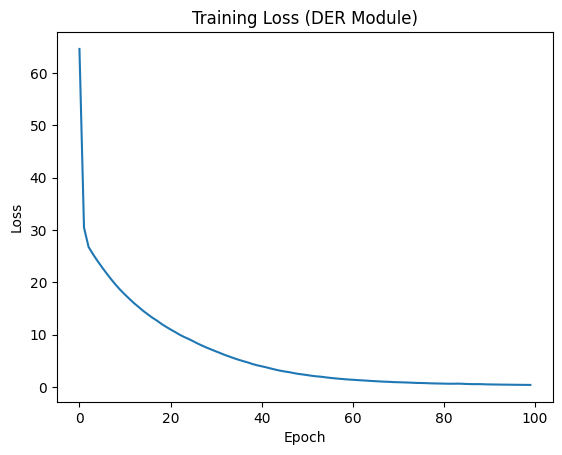

模型訓練完成！


In [ ]:
import matplotlib.pyplot as plt

# 1. 設定參數
num_epochs = 100  # 論文設定
optimizer = torch.optim.Adam(model.parameters(), lr=0.001) # 學習率可以試著調小一點點 (e.g., 0.0005) 如果震盪太大
loss_history = []

print(f"開始訓練 {num_epochs} 個 Epochs...")

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for batch in dataloader:
        tokens, pos, labels, mask = [b.to(device) for b in batch]

        optimizer.zero_grad()

        # 計算 Loss (Batch 總和)
        batch_loss = model(tokens, pos, labels, mask)

        # Backward pass
        batch_loss.backward()
        optimizer.step()

        total_loss += batch_loss.item()

    # 計算「平均每筆資料」的 Loss，以便跟論文比較
    # len(dataloader) 是 batch 的數量，所以這裡我們算的是平均每個 batch 的 loss
    # 若要精確，可以再除以 batch_size
    # avg_batch_loss = total_loss / len(dataloader)
    avg_sentence_loss = (total_loss / len(dataloader)) / 32  # 假設 batch_size=32

    # 紀錄
    loss_history.append(avg_sentence_loss)

    print(f"Epoch {epoch+1}/{num_epochs}, Avg Loss: {avg_sentence_loss:.4f}")

# 2. 繪製 Loss 曲線 (就像論文 Fig 2)
plt.plot(loss_history)
plt.title("Training Loss (DER Module)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# 3. 儲存模型
torch.save(model.state_dict(), '/content/drive/MyDrive/DECEN/der_module_v2_100epochs.pth')
print("模型訓練完成！")

In [ ]:
import torch
import random

# 設定為評估模式
model.eval()

# 建立反查表 (ID -> 文字)
idx2word = {v: k for k, v in word2idx.items()}
idx2tag = {v: k for k, v in tag2idx.items()}

def evaluate_random_samples(model, dataset, num_samples=3):
    print(f"============== 模型預測檢查 (隨機 {num_samples} 筆) ==============")

    # 從資料集中隨機選取索引
    indices = random.sample(range(len(dataset)), num_samples)

    for i in indices:
        # 取出資料 (Tensor)
        tokens_tensor, pos_tensor, labels_tensor = dataset[i]

        # 增加 Batch 維度 (因為模型預期輸入是 Batch)
        tokens_in = tokens_tensor.unsqueeze(0).to(device)
        pos_in = pos_tensor.unsqueeze(0).to(device)
        mask = (tokens_in != 0).byte()

        # 進行預測
        with torch.no_grad():
            predicted_path = model(tokens_in, pos_in, mask=mask)
            predicted_tags = [idx2tag[t] for t in predicted_path[0]]

        # 還原原始文字與標籤
        original_tokens = [idx2word[t.item()] for t in tokens_tensor]
        original_labels = [idx2tag[l.item()] for l in labels_tensor]

        # 顯示結果
        print(f"\n【樣本 ID: {dataset.data[i]['post_id']}】")

        # 格式化輸出對齊
        print(f"{'詞彙':<8} | {'真實標籤':<10} | {'預測標籤':<10}")
        print("-" * 35)
        for w, true_l, pred_l in zip(original_tokens, original_labels, predicted_tags):
            # 只顯示有意義的詞，忽略 padding
            if w != '<PAD>':
                status = "✅" if true_l == pred_l else "❌"
                print(f"{w:<10} | {true_l:<10} | {pred_l:<10} {status}")

    print("\n========================================================")

# 執行檢查
evaluate_random_samples(model, dataset, num_samples=3)

============== 模型預測檢查 (隨機 3 筆) ==============

【樣本 ID: 903】
詞彙       | 真實標籤       | 預測標籤      
-----------------------------------
我          | O          | O          ✅
什麼         | O          | O          ✅
時候         | O          | O          ✅
才          | O          | O          ✅
會          | O          | O          ✅
知道         | O          | O          ✅
自己         | O          | O          ✅
需要         | O          | O          ✅
幫助         | O          | O          ✅
？          | O          | O          ✅
是          | O          | O          ✅
當          | O          | O          ✅
我          | O          | O          ✅
總是         | O          | O          ✅
被          | O          | O          ✅
自我         | O          | O          ✅
評價         | O          | O          ✅
的          | O          | O          ✅
陰影         | S-W        | S-W        ✅
<UNK>      | O          | O          ✅
？          | O          | O          ✅
還是         | O          | O          ✅
當          

In [ ]:
!pip install seqeval

In [ ]:
from seqeval.metrics import classification_report, f1_score, accuracy_score

def evaluate_metrics(model, dataloader):
    model.eval()

    # 儲存所有的預測與真實標籤 (必須是 List of List 格式)
    true_labels_list = []
    pred_labels_list = []

    idx2tag = {v: k for k, v in tag2idx.items()}

    with torch.no_grad():
        for batch in dataloader:
            tokens, pos, labels, mask = [b.to(device) for b in batch]

            # 取得最佳路徑
            pred_tags_ids = model(tokens, pos, mask=mask)

            # 將 Batch 裡的每一句解碼
            for i, pred_seq in enumerate(pred_tags_ids):
                # 取得該句真實長度 (過濾掉 PAD)
                # mask[i] 為 1 的地方才是真資料
                valid_len = mask[i].sum().item()

                # 真實標籤 (只取有效長度)
                true_seq_ids = labels[i][:valid_len].tolist()
                true_seq_str = [idx2tag[ID] for ID in true_seq_ids]

                # 預測標籤 (seqeval 對齊長度)
                # CRF decode 出來的長度通常已經是有效長度，但保險起見對齊一下
                pred_seq_str = [idx2tag[ID] for ID in pred_seq]

                true_labels_list.append(true_seq_str)
                pred_labels_list.append(pred_seq_str)

    # --- 輸出報告 ---
    print("\n【實體層級評估報告 (Entity-level Report)】")
    # seqeval 會自動處理 BMES/BIO 格式，算出每個情緒類別的 F1
    print(classification_report(true_labels_list, pred_labels_list, digits=4))

    f1 = f1_score(true_labels_list, pred_labels_list)
    print(f"整體 F1-Score: {f1:.4f}")

    return f1

# 執行評估 (建議丟入驗證集，這裡先用訓練集示範)
evaluate_metrics(model, dataloader)


【實體層級評估報告 (Entity-level Report)】


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-D seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-W seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-A seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-U seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: <PAD> seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWa

              precision    recall  f1-score   support

           A     0.0010    0.0847    0.0021       177
           D     0.0100    0.0951    0.0180      1304
        PAD>     0.0000    0.0000    0.0000         0
           U     0.0008    0.0265    0.0016       226
           W     0.0050    0.2226    0.0098       521

   micro avg     0.0043    0.1171    0.0084      2228
   macro avg     0.0034    0.0858    0.0063      2228
weighted avg     0.0072    0.1171    0.0132      2228

整體 F1-Score: 0.0084


np.float64(0.008357616318165808)

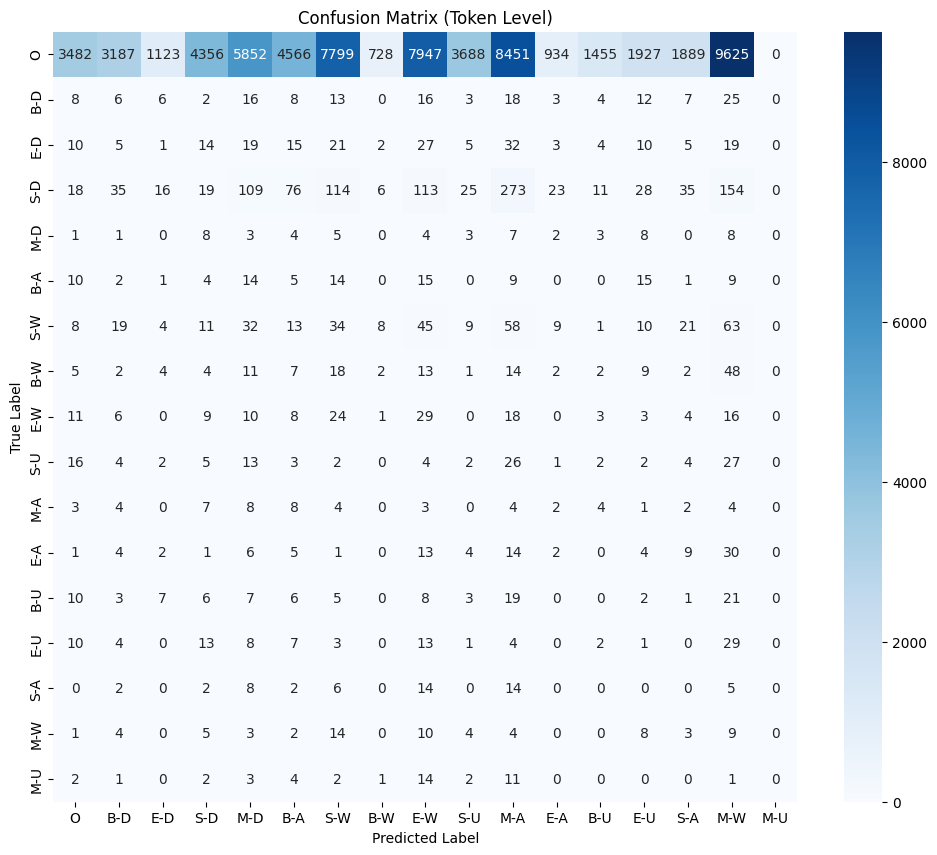

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(model, dataloader):
    model.eval()
    all_true = []
    all_pred = []

    idx2tag = {v: k for k, v in tag2idx.items()}

    with torch.no_grad():
        for batch in dataloader:
            tokens, pos, labels, mask = [b.to(device) for b in batch]
            pred_tags_ids = model(tokens, pos, mask=mask)

            for i, pred_seq in enumerate(pred_tags_ids):
                valid_len = mask[i].sum().item()
                true_seq_ids = labels[i][:valid_len].tolist()

                # 收集所有的 token (展平成一維)
                all_true.extend(true_seq_ids)
                all_pred.extend(pred_seq)

    # 轉換成文字標籤
    labels_list = list(tag2idx.keys())
    # 移除 <PAD> 和 <UNK> 不顯示
    labels_list = [l for l in labels_list if l not in ['<PAD>', '<UNK>']]

    # 計算混淆矩陣
    cm = confusion_matrix(
        [idx2tag[i] for i in all_true],
        [idx2tag[i] for i in all_pred],
        labels=labels_list
    )

    # 繪圖
    plt.figure(figsize=(12, 10))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels_list, yticklabels=labels_list, cmap='Blues')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.title('Confusion Matrix (Token Level)')
    plt.show()

# 執行繪圖
plot_confusion_matrix(model, dataloader)

In [ ]:
!pip -q install torchcrf==1.1.0 seqeval==1.2.2 jieba

In [ ]:
# ============================================
# DECEN DER (Paper-style) with auto POS tagging:
# word embedding + POS embedding -> concat -> BiLSTM -> CRF
# Data columns: post_id, caption, word, human_label, word order
# ============================================

!pip -q install torchcrf==1.1.0 seqeval==1.2.2 jieba

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchcrf import CRF
from seqeval.metrics import f1_score, precision_score, recall_score, classification_report
from sklearn.model_selection import train_test_split
import random
from collections import Counter
import jieba.posseg as pseg

# -------------------------
# 0. Reproducibility
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------------------------
# 1. Load CSV
# -------------------------
CSV_PATH = "/content/drive/MyDrive/select_de_synold_filtered.csv"
df = pd.read_csv(CSV_PATH)

# 你說的主要欄位
POST_COL = "post_id"
WORD_COL = "word"
LAB_COL  = "human_label"
ORDER_COL = "word_order"   # 若你的欄位名稱不同，改這行即可

required = [POST_COL, WORD_COL, LAB_COL, ORDER_COL]
for c in required:
    if c not in df.columns:
        raise ValueError(f"找不到欄位：{c}，目前欄位={df.columns.tolist()}")

print("df.shape:", df.shape)
print(df[[POST_COL, WORD_COL, LAB_COL, ORDER_COL]].head())

# -------------------------
# 2. Auto POS tagging (jieba.posseg)
# -------------------------
# 注意：你是「已斷詞後」的 word，所以這裡用「逐詞 POS」
# 優點：對齊你現有 token，不會斷詞不一致
# 缺點：少了上下文（但仍可作為論文版 POS embedding 的實作替代）
def get_pos_tag_for_word(w: str) -> str:
    w = str(w)
    if w.strip() == "":
        return "x"
    try:
        it = pseg.cut(w)
        first = next(it, None)
        if first is None:
            return "x"
        return first.flag if first.flag else "x"
    except Exception:
        return "x"

print("Building POS tags...")
df["pos"] = df[WORD_COL].astype(str).apply(get_pos_tag_for_word)
print(df[[WORD_COL, "pos"]].head(10))

# -------------------------
# 3. Sort by (post_id, word order) to form sequences
# -------------------------
df = df.sort_values([POST_COL, ORDER_COL]).reset_index(drop=True)

grouped = df.groupby(POST_COL, sort=False)

posts_words, posts_pos, posts_labels = [], [], []
post_ids = []

for pid, g in grouped:
    toks = g[WORD_COL].astype(str).tolist()
    poss = g["pos"].astype(str).tolist()
    labs = g[LAB_COL].astype(str).tolist()
    if len(toks) == 0:
        continue
    posts_words.append(toks)
    posts_pos.append(poss)
    posts_labels.append(labs)
    post_ids.append(pid)

print("num posts:", len(posts_words))
print("example tokens:", posts_words[0][:10])
print("example pos   :", posts_pos[0][:10])
print("example labels:", posts_labels[0][:10])

# -------------------------
# 4. Build vocab: word2id, pos2id, label2id
# -------------------------
PAD = "<PAD>"
UNK = "<UNK>"

word_counter = Counter([w for seq in posts_words for w in seq])
pos_counter  = Counter([p for seq in posts_pos for p in seq])
label_set    = sorted(list(set([y for seq in posts_labels for y in seq])))

word2id = {PAD:0, UNK:1}
for w, _ in word_counter.most_common():
    word2id[w] = len(word2id)

pos2id = {PAD:0, UNK:1}
for p, _ in pos_counter.most_common():
    pos2id[p] = len(pos2id)

label2id = {lab:i for i, lab in enumerate(label_set)}
id2label = {i:lab for lab, i in label2id.items()}

print("vocab size:", len(word2id), "pos size:", len(pos2id), "num labels:", len(label2id))
print("labels sample:", label_set[:30])

# -------------------------
# 5. Train/Val split by post (sequence)
# -------------------------
idx_all = list(range(len(posts_words)))
train_idx, val_idx = train_test_split(idx_all, test_size=0.2, random_state=42, shuffle=True)

def select(arr, idxs):
    return [arr[i] for i in idxs]

train_words  = select(posts_words, train_idx)
train_pos    = select(posts_pos, train_idx)
train_labels = select(posts_labels, train_idx)

val_words  = select(posts_words, val_idx)
val_pos    = select(posts_pos, val_idx)
val_labels = select(posts_labels, val_idx)

print("train posts:", len(train_words), "val posts:", len(val_words))

# -------------------------
# 6. Dataset + collate (pad)
# -------------------------
def encode_seq(seq, vocab):
    return [vocab.get(x, vocab[UNK]) for x in seq]

def encode_label(seq, vocab):
    # label 必須都在 label2id 內
    return [vocab[x] for x in seq]

class SequenceDataset(Dataset):
    def __init__(self, words_list, pos_list, labels_list):
        self.words_list = words_list
        self.pos_list = pos_list
        self.labels_list = labels_list

    def __len__(self):
        return len(self.words_list)

    def __getitem__(self, idx):
        w = encode_seq(self.words_list[idx], word2id)
        p = encode_seq(self.pos_list[idx], pos2id)
        y = encode_label(self.labels_list[idx], label2id)
        return {
            "word_ids": torch.tensor(w, dtype=torch.long),
            "pos_ids": torch.tensor(p, dtype=torch.long),
            "label_ids": torch.tensor(y, dtype=torch.long),
        }

def collate_fn(batch):
    max_len = max(x["word_ids"].size(0) for x in batch)
    bsz = len(batch)

    word_pad = torch.full((bsz, max_len), word2id[PAD], dtype=torch.long)
    pos_pad  = torch.full((bsz, max_len),  pos2id[PAD], dtype=torch.long)
    lab_pad  = torch.full((bsz, max_len), -1, dtype=torch.long)
    mask     = torch.zeros((bsz, max_len), dtype=torch.bool)

    for i, x in enumerate(batch):
        L = x["word_ids"].size(0)
        word_pad[i, :L] = x["word_ids"]
        pos_pad[i, :L]  = x["pos_ids"]
        lab_pad[i, :L]  = x["label_ids"]
        mask[i, :L]     = True

    return {"word_ids": word_pad, "pos_ids": pos_pad, "label_ids": lab_pad, "mask": mask}

train_loader = DataLoader(SequenceDataset(train_words, train_pos, train_labels),
                          batch_size=16, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(SequenceDataset(val_words, val_pos, val_labels),
                          batch_size=16, shuffle=False, collate_fn=collate_fn)

# -------------------------
# 7. Model: WordEmb + POSEmb -> concat -> BiLSTM -> Linear -> CRF
# -------------------------
class BiLSTM_CRF(nn.Module):
    def __init__(self, word_vocab_size, pos_vocab_size, num_labels,
                 word_dim=200, pos_dim=50, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.word_emb = nn.Embedding(word_vocab_size, word_dim, padding_idx=word2id[PAD])
        self.pos_emb  = nn.Embedding(pos_vocab_size,  pos_dim,  padding_idx=pos2id[PAD])

        self.dropout = nn.Dropout(dropout)
        self.lstm = nn.LSTM(
            input_size=word_dim + pos_dim,
            hidden_size=hidden_dim // 2,
            num_layers=1,
            batch_first=True,
            bidirectional=True
        )
        self.fc = nn.Linear(hidden_dim, num_labels)
        self.crf = CRF(num_labels, batch_first=True)

    def forward(self, word_ids, pos_ids, mask, labels=None):
        w = self.word_emb(word_ids)
        p = self.pos_emb(pos_ids)
        x = torch.cat([w, p], dim=-1)  # concat word+POS
        x = self.dropout(x)

        feats, _ = self.lstm(x)
        feats = self.dropout(feats)
        emissions = self.fc(feats)

        if labels is not None:
            loss = -self.crf(emissions, labels, mask=mask, reduction='mean')
            return loss
        else:
            pred = self.crf.decode(emissions, mask=mask)
            return pred

model = BiLSTM_CRF(
    word_vocab_size=len(word2id),
    pos_vocab_size=len(pos2id),
    num_labels=len(label2id),
    word_dim=200,     # 可改 300
    pos_dim=50,
    hidden_dim=256,
    dropout=0.2
).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3)

# -------------------------
# 8. Train / Eval
# -------------------------
def ids_to_labels(batch_preds, batch_true, mask):
    y_true, y_pred = [], []
    for i, pred_seq in enumerate(batch_preds):
        true_seq = batch_true[i][mask[i]].tolist()
        y_true.append([id2label[t] for t in true_seq])
        y_pred.append([id2label[p] for p in pred_seq])
    return y_true, y_pred

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_true, all_pred = [], []
    total_loss, n_batches = 0.0, 0

    for batch in loader:
        word_ids = batch["word_ids"].to(device)
        pos_ids  = batch["pos_ids"].to(device)
        labels   = batch["label_ids"].to(device)
        mask     = batch["mask"].to(device)

        loss = model(word_ids, pos_ids, mask, labels=labels)
        preds = model(word_ids, pos_ids, mask, labels=None)

        yt, yp = ids_to_labels(preds, labels, mask)
        all_true.extend(yt)
        all_pred.extend(yp)

        total_loss += loss.item()
        n_batches += 1

    f1 = f1_score(all_true, all_pred)
    p  = precision_score(all_true, all_pred)
    r  = recall_score(all_true, all_pred)
    return total_loss / max(n_batches, 1), p, r, f1, all_true, all_pred

def train_one_epoch(model, loader):
    model.train()
    total_loss, n_batches = 0.0, 0

    for batch in loader:
        word_ids = batch["word_ids"].to(device)
        pos_ids  = batch["pos_ids"].to(device)
        labels   = batch["label_ids"].to(device)
        mask     = batch["mask"].to(device)

        loss = model(word_ids, pos_ids, mask, labels=labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()

        total_loss += loss.item()
        n_batches += 1

    return total_loss / max(n_batches, 1)




device: cuda


Building prefix dict from the default dictionary ...
DEBUG:jieba:Building prefix dict from the default dictionary ...
Loading model from cache /tmp/jieba.cache
DEBUG:jieba:Loading model from cache /tmp/jieba.cache


df.shape: (73371, 12)
   post_id word human_label  word_order
0        3   心情           O         1.0
1        3   情緒           O         2.0
2        3   部份           O         3.0
3        3   一直           O         4.0
4        3   覺得           O         5.0
Building POS tags...


Loading model cost 1.974 seconds.
DEBUG:jieba:Loading model cost 1.974 seconds.
Prefix dict has been built successfully.
DEBUG:jieba:Prefix dict has been built successfully.


  word pos
0   心情   n
1   情緒   n
2   部份   n
3   一直   d
4   覺得   v
5   哪裡   r
6  怪怪的   z
7    （   x
8    ？   x
9    ）   x
num posts: 664
example tokens: ['心情', '情緒', '部份', '一直', '覺得', '哪裡', '怪怪的', '（', '？', '）']
example pos   : ['n', 'n', 'n', 'd', 'v', 'r', 'z', 'x', 'x', 'x']
example labels: ['O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O']
vocab size: 7967 pos size: 53 num labels: 17
labels sample: ['B-A', 'B-D', 'B-U', 'B-W', 'E-A', 'E-D', 'E-U', 'E-W', 'M-A', 'M-D', 'M-U', 'M-W', 'O', 'S-A', 'S-D', 'S-U', 'S-W']
train posts: 531 val posts: 133


/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-A seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-U seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-W seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/sequence_labeling.py:171: UserWarning: M-D seems not to be NE tag.
  warnings.warn('{} seems not to be NE tag.'.format(chunk))
/usr/local/lib/python3.12/dist-packages/seqeval/metrics/v1.py:57: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(r

[Epoch 01] TrainLoss=76.1589 | ValLoss=24.3904 | P=0.0000 R=0.0000 F1=0.0000
[Epoch 02] TrainLoss=23.1385 | ValLoss=18.8963 | P=0.7662 R=0.1460 F1=0.2453
[Epoch 03] TrainLoss=17.0266 | ValLoss=16.9029 | P=0.7417 R=0.2203 F1=0.3397
[Epoch 04] TrainLoss=13.9379 | ValLoss=16.0377 | P=0.6839 R=0.2624 F1=0.3792
[Epoch 05] TrainLoss=11.5846 | ValLoss=14.4977 | P=0.5719 R=0.3936 F1=0.4663
[Epoch 06] TrainLoss=9.6541 | ValLoss=14.3681 | P=0.6050 R=0.3564 F1=0.4486
[Epoch 07] TrainLoss=7.9137 | ValLoss=14.7397 | P=0.5903 R=0.4208 F1=0.4913
[Epoch 08] TrainLoss=6.4584 | ValLoss=14.9814 | P=0.6624 R=0.3886 F1=0.4899
[Epoch 09] TrainLoss=5.3790 | ValLoss=14.2382 | P=0.5828 R=0.4530 F1=0.5097
[Epoch 10] TrainLoss=4.2180 | ValLoss=15.1344 | P=0.6267 R=0.4530 F1=0.5259
[Epoch 11] TrainLoss=3.4590 | ValLoss=15.7828 | P=0.6374 R=0.4134 F1=0.5015
[Epoch 12] TrainLoss=3.0228 | ValLoss=16.6093 | P=0.6815 R=0.4183 F1=0.5184
[Epoch 13] TrainLoss=2.3512 | ValLoss=17.0543 | P=0.6353 R=0.4183 F1=0.5045
[Epoch 

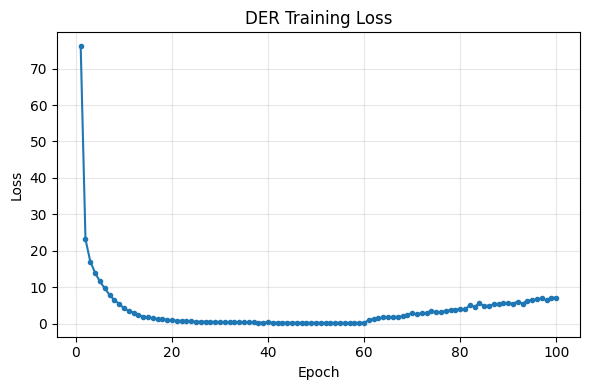

In [ ]:
EPOCHS = 100
best_f1 = -1
train_loss_history = []
for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    train_loss_history.append(tr_loss)

    va_loss, p, r, f1, yt, yp = evaluate(model, val_loader)
    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | ValLoss={va_loss:.4f} | P={p:.4f} R={r:.4f} F1={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        torch.save({
            "model_state": model.state_dict(),
            "word2id": word2id,
            "pos2id": pos2id,
            "label2id": label2id,
            "id2label": id2label
        }, "/content/drive/MyDrive/DECEN/best_der_bilstm_crf_with_jieba_pos_100.pt")

print("\nBest F1:", best_f1)
print("\nClassification report (val):")
print(classification_report(yt, yp, digits=4))

import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_history, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DER Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


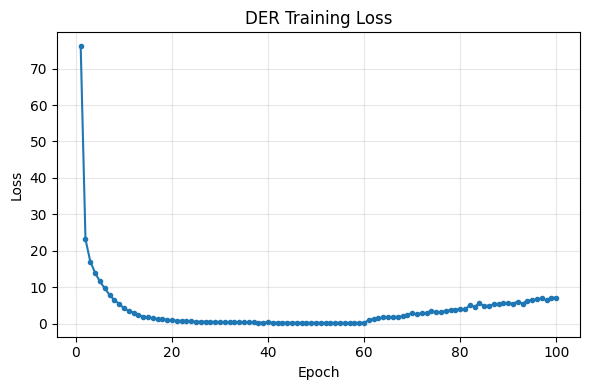

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_history, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DER Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
EPOCHS = 100
best_f1 = -1
best_epoch = -1

patience = 10     # 連續 10 個 epoch 沒進步就停（可調 5/10/15）
min_delta = 1e-4  # 最小提升幅度，小於這個不算進步
no_improve = 0

train_loss_history = []
val_loss_history = []
val_f1_history = []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    train_loss_history.append(tr_loss)

    va_loss, p, r, f1, yt, yp = evaluate(model, val_loader)
    val_loss_history.append(va_loss)
    val_f1_history.append(f1)

    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | ValLoss={va_loss:.4f} | P={p:.4f} R={r:.4f} F1={f1:.4f}")

    # ---- F1 early stopping logic ----
    if f1 > best_f1 + min_delta:
        best_f1 = f1
        best_epoch = epoch
        no_improve = 0

        torch.save({
            "model_state": model.state_dict(),
            "word2id": word2id,
            "pos2id": pos2id,
            "label2id": label2id,
            "id2label": id2label,
            "best_epoch": best_epoch,
            "best_f1": best_f1
        }, "/content/drive/MyDrive/DECEN/best_der_bilstm_crf_with_jieba_pos.pt")

        print(f"  ✅ New best F1={best_f1:.4f} at epoch {best_epoch}, model saved.")
    else:
        no_improve += 1
        print(f"  ⏳ No improvement: {no_improve}/{patience}")

        if no_improve >= patience:
            print(f"\n🛑 Early stopping triggered. Best F1={best_f1:.4f} at epoch {best_epoch}.")
            break

print("\nBest F1:", best_f1, "Best epoch:", best_epoch)
print("\nClassification report (last evaluated epoch):")
print(classification_report(yt, yp, digits=4))


[Epoch 01] TrainLoss=23.1385 | ValLoss=18.8963 | P=0.7662 R=0.1460 F1=0.2453
  ✅ New best F1=0.2453 at epoch 1, model saved.
[Epoch 02] TrainLoss=17.0266 | ValLoss=16.9029 | P=0.7417 R=0.2203 F1=0.3397
  ✅ New best F1=0.3397 at epoch 2, model saved.
[Epoch 03] TrainLoss=13.9379 | ValLoss=16.0377 | P=0.6839 R=0.2624 F1=0.3792
  ✅ New best F1=0.3792 at epoch 3, model saved.
[Epoch 04] TrainLoss=11.5846 | ValLoss=14.4977 | P=0.5719 R=0.3936 F1=0.4663
  ✅ New best F1=0.4663 at epoch 4, model saved.
[Epoch 05] TrainLoss=9.6541 | ValLoss=14.3681 | P=0.6050 R=0.3564 F1=0.4486
  ⏳ No improvement: 1/10
[Epoch 06] TrainLoss=7.9137 | ValLoss=14.7397 | P=0.5903 R=0.4208 F1=0.4913
  ✅ New best F1=0.4913 at epoch 6, model saved.
[Epoch 07] TrainLoss=6.4584 | ValLoss=14.9814 | P=0.6624 R=0.3886 F1=0.4899
  ⏳ No improvement: 1/10
[Epoch 08] TrainLoss=5.3790 | ValLoss=14.2382 | P=0.5828 R=0.4530 F1=0.5097
  ✅ New best F1=0.5097 at epoch 8, model saved.
[Epoch 09] TrainLoss=4.2180 | ValLoss=15.1344 | P=

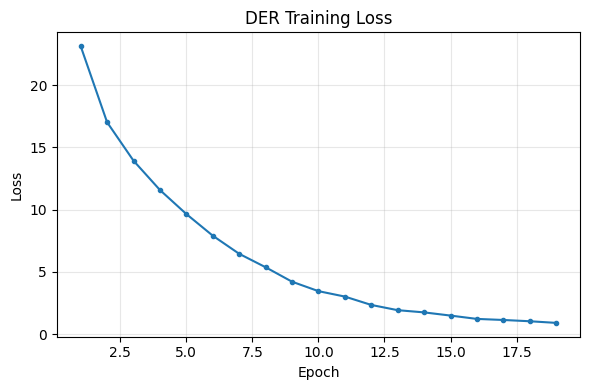

In [ ]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_history) + 1))

plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_history, marker='o', markersize=3)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DER Training Loss")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
from collections import Counter

all_pred_labels = []
for seq in yp:          # yp 是 seqeval 用的 entity label
    all_pred_labels.extend(seq)

Counter(all_pred_labels)


Counter({'O': 11459,
         'S-D': 123,
         'S-W': 54,
         'B-D': 18,
         'E-D': 18,
         'B-A': 12,
         'M-A': 1,
         'E-A': 11,
         'B-U': 14,
         'M-U': 5,
         'E-U': 15,
         'B-W': 15,
         'M-W': 5,
         'E-W': 15,
         'S-U': 10,
         'M-D': 4,
         'S-A': 1})

Total entity tokens (excluding 'O'): 547
Sample true labels: ['B-A', 'M-A', 'E-A', 'S-D', 'S-D', 'S-W', 'S-W', 'S-U', 'S-D', 'S-D']
Sample pred labels: ['O', 'O', 'S-D', 'O', 'S-D', 'O', 'S-W', 'O', 'O', 'O']
Labels in confusion matrix: ['B-A', 'B-D', 'B-U', 'B-W', 'E-A', 'E-D', 'E-U', 'E-W', 'M-A', 'M-D', 'M-U', 'M-W', 'O', 'S-A', 'S-D', 'S-U', 'S-W']
Confusion matrix shape: (17, 17)


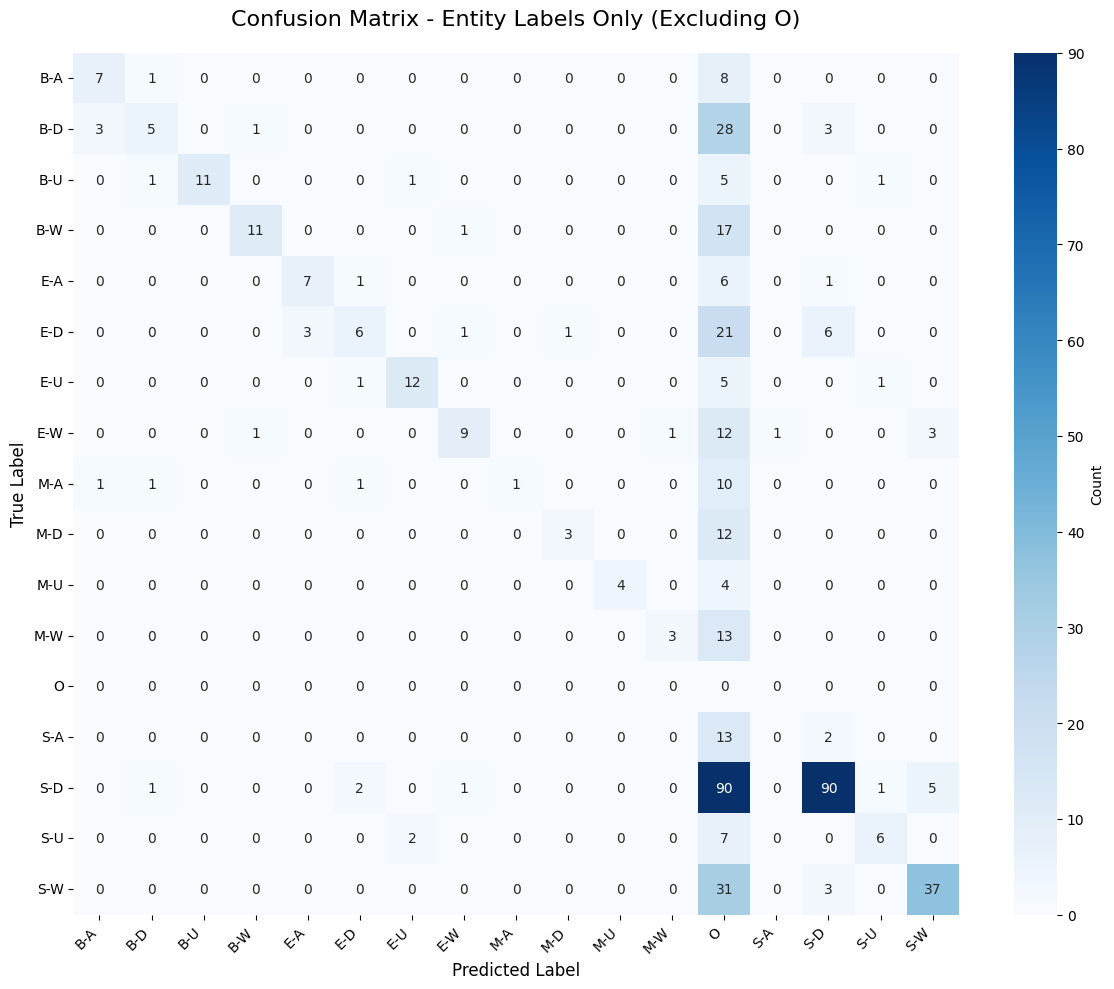

/tmp/ipython-input-1879536444.py:45: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


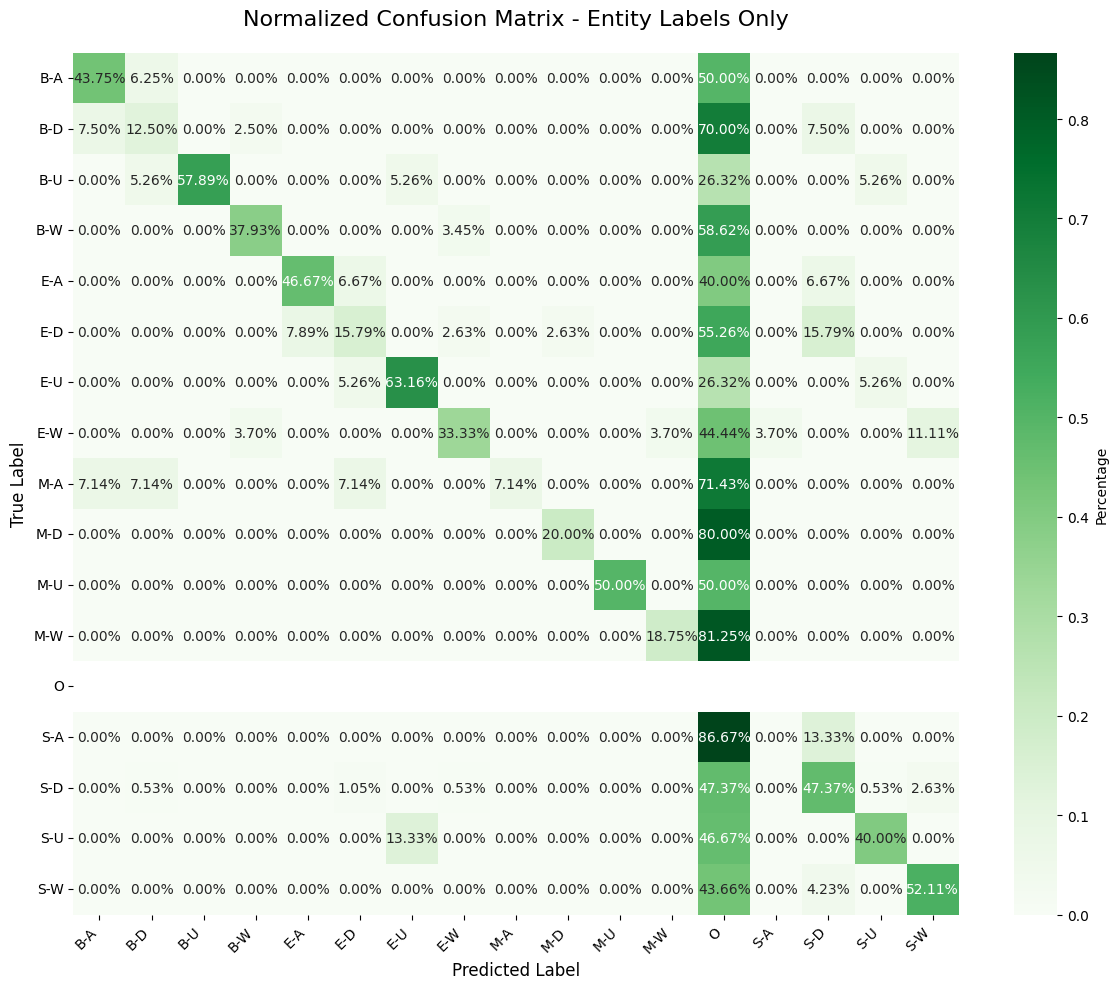


📊 Confusion Matrix Analysis (Entity Labels Only):
B-A            :     7/   16 = 43.75%
B-D            :     5/   40 = 12.50%
B-U            :    11/   19 = 57.89%
B-W            :    11/   29 = 37.93%
E-A            :     7/   15 = 46.67%
E-D            :     6/   38 = 15.79%
E-U            :    12/   19 = 63.16%
E-W            :     9/   27 = 33.33%
M-A            :     1/   14 = 7.14%
M-D            :     3/   15 = 20.00%
M-U            :     4/    8 = 50.00%
M-W            :     3/   16 = 18.75%
O              :     0/    0 = 0.00%
S-A            :     0/   15 = 0.00%
S-D            :    90/  190 = 47.37%
S-U            :     6/   15 = 40.00%
S-W            :    37/   71 = 52.11%

🔍 Most Confused Label Pairs:
S-D        → O         :   90 times
S-W        → O         :   31 times
B-D        → O         :   28 times
E-D        → O         :   21 times
B-W        → O         :   17 times
M-W        → O         :   13 times
S-A        → O         :   13 times
E-W        → O         :

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# 1. 將nested lists展平並過濾掉 'O' 標籤
yt_flat_filtered = []
yp_flat_filtered = []

for yt_sent, yp_sent in zip(yt, yp):
    for true_label, pred_label in zip(yt_sent, yp_sent):
        if true_label != 'O':  # 只保留非O標籤
            yt_flat_filtered.append(true_label)
            yp_flat_filtered.append(pred_label)

print(f"Total entity tokens (excluding 'O'): {len(yt_flat_filtered)}")
print(f"Sample true labels: {yt_flat_filtered[:10]}")
print(f"Sample pred labels: {yp_flat_filtered[:10]}")

# 2. 計算混淆矩陣
cm = confusion_matrix(yt_flat_filtered, yp_flat_filtered)

# 3. 取得所有出現過的標籤名稱(已經是字串,不需要轉換)
unique_labels = sorted(set(yt_flat_filtered) | set(yp_flat_filtered))
labels = unique_labels

print(f"Labels in confusion matrix: {labels}")
print(f"Confusion matrix shape: {cm.shape}")

# 4. 繪製混淆矩陣
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'})

plt.title('Confusion Matrix - Entity Labels Only (Excluding O)', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. 顯示歸一化的混淆矩陣(百分比)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(12, 10))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Percentage'})

plt.title('Normalized Confusion Matrix - Entity Labels Only', fontsize=16, pad=20)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 6. 印出詳細統計
print("\n📊 Confusion Matrix Analysis (Entity Labels Only):")
print("=" * 60)
for i, label in enumerate(labels):
    total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0
    print(f"{label:15s}: {correct:5d}/{total:5d} = {acc:.2%}")

# 7. 找出最容易混淆的標籤對
print("\n🔍 Most Confused Label Pairs:")
print("=" * 60)
confused_pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((labels[i], labels[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_lab, pred_lab, count in confused_pairs[:10]:
    print(f"{true_lab:10s} → {pred_lab:10s}: {count:4d} times")

Total entity tokens (main categories only): 547
Sample true categories: ['A', 'A', 'A', 'D', 'D', 'W', 'W', 'U', 'D', 'D', 'D', 'A', 'A', 'A', 'A', 'A', 'D', 'W', 'W', 'U']
Sample pred categories: ['O', 'O', 'D', 'O', 'D', 'O', 'W', 'O', 'O', 'O', 'O', 'O', 'O', 'A', 'A', 'A', 'O', 'O', 'O', 'U']

Main categories: ['A', 'D', 'O', 'U', 'W']
Confusion matrix shape: (5, 5)


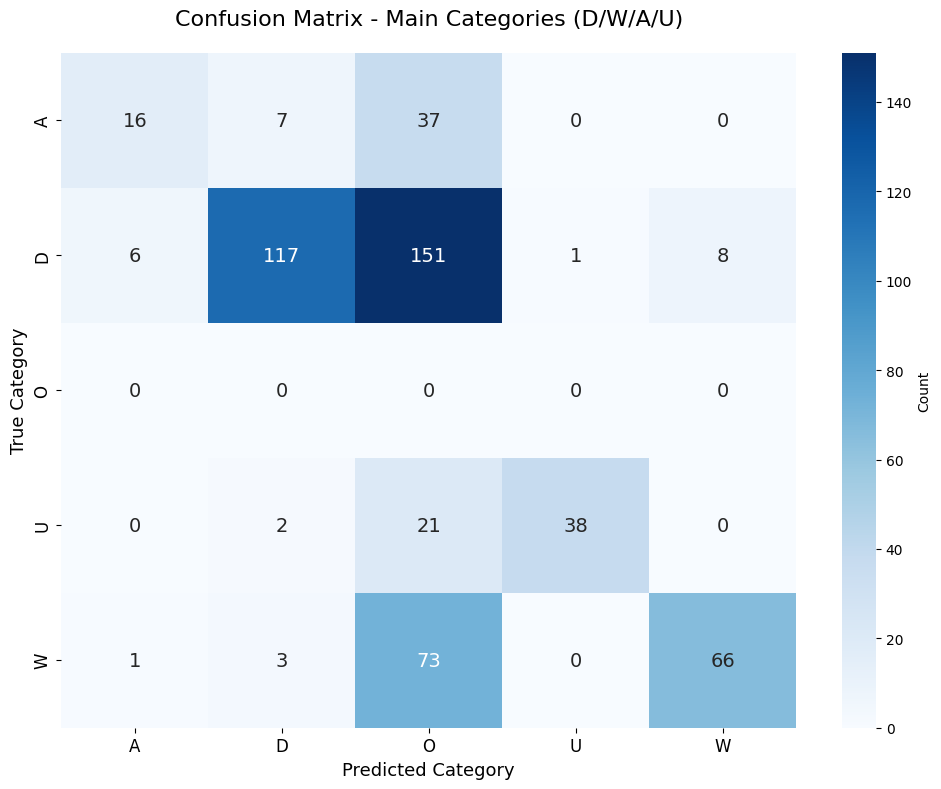

/tmp/ipython-input-3791846445.py:64: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


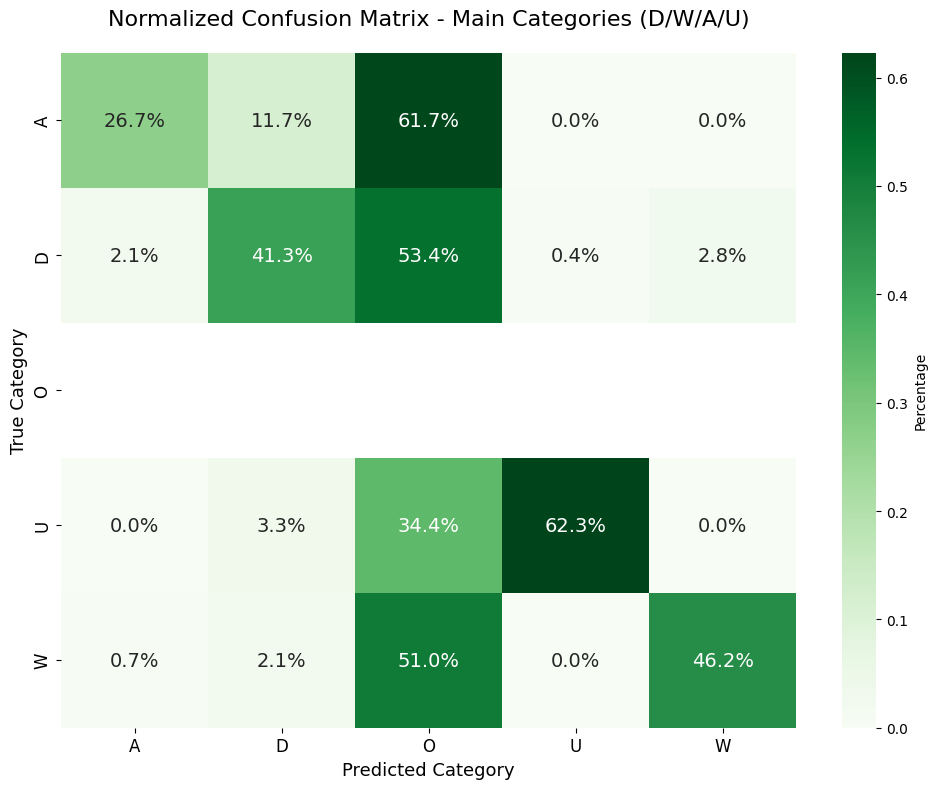


📊 Confusion Matrix Analysis (Main Categories):
A         :    16/   60 = 26.67%
D         :   117/  283 = 41.34%
O         :     0/    0 = 0.00%
U         :    38/   61 = 62.30%
W         :    66/  143 = 46.15%

🔍 Most Confused Category Pairs:
D     → O    :  151 times
W     → O    :   73 times
A     → O    :   37 times
U     → O    :   21 times
D     → W    :    8 times
A     → D    :    7 times
D     → A    :    6 times
W     → D    :    3 times
U     → D    :    2 times
D     → U    :    1 times
W     → A    :    1 times

📈 Classification Report (Main Categories):
              precision    recall  f1-score   support

           A     0.6957    0.2667    0.3855        60
           D     0.9070    0.4134    0.5680       283
           O     0.0000    0.0000    0.0000         0
           U     0.9744    0.6230    0.7600        61
           W     0.8919    0.4615    0.6083       143

    accuracy                         0.4333       547
   macro avg     0.6938    0.3529    0.4644  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

# 1. 定義函數:將 BIO 標籤轉換為主類別
def extract_main_category(label):
    """
    B-A, M-A, E-A, S-A -> A
    B-D, M-D, E-D, S-D -> D
    O -> O
    """
    if label == 'O':
        return 'O'
    # 取最後一個字元作為主類別 (B-A -> A, S-D -> D)
    parts = label.split('-')
    if len(parts) == 2:
        return parts[1]  # 取 '-' 後面的部分
    return label  # 防止異常格式

# 2. 將 yt 和 yp 轉換為主類別並展平
yt_main_flat = []
yp_main_flat = []

for yt_sent, yp_sent in zip(yt, yp):
    for true_label, pred_label in zip(yt_sent, yp_sent):
        true_main = extract_main_category(true_label)
        pred_main = extract_main_category(pred_label)

        # 只保留非O的標籤
        if true_main != 'O':
            yt_main_flat.append(true_main)
            yp_main_flat.append(pred_main)

print(f"Total entity tokens (main categories only): {len(yt_main_flat)}")
print(f"Sample true categories: {yt_main_flat[:20]}")
print(f"Sample pred categories: {yp_main_flat[:20]}")

# 3. 計算混淆矩陣
cm = confusion_matrix(yt_main_flat, yp_main_flat)

# 4. 取得類別標籤
unique_labels = sorted(set(yt_main_flat) | set(yp_main_flat))
labels = unique_labels

print(f"\nMain categories: {labels}")
print(f"Confusion matrix shape: {cm.shape}")

# 5. 繪製混淆矩陣
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 14})

plt.title('Confusion Matrix - Main Categories (D/W/A/U)', fontsize=16, pad=20)
plt.xlabel('Predicted Category', fontsize=13)
plt.ylabel('True Category', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 6. 顯示歸一化的混淆矩陣(百分比)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens',
            xticklabels=labels, yticklabels=labels,
            cbar_kws={'label': 'Percentage'}, annot_kws={'size': 14})

plt.title('Normalized Confusion Matrix - Main Categories (D/W/A/U)', fontsize=16, pad=20)
plt.xlabel('Predicted Category', fontsize=13)
plt.ylabel('True Category', fontsize=13)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.tight_layout()
plt.show()

# 7. 印出詳細統計
print("\n📊 Confusion Matrix Analysis (Main Categories):")
print("=" * 60)
for i, label in enumerate(labels):
    total = cm[i].sum()
    correct = cm[i, i]
    acc = correct / total if total > 0 else 0
    print(f"{label:10s}: {correct:5d}/{total:5d} = {acc:.2%}")

# 8. 找出最容易混淆的類別對
print("\n🔍 Most Confused Category Pairs:")
print("=" * 60)
confused_pairs = []
for i in range(len(labels)):
    for j in range(len(labels)):
        if i != j and cm[i, j] > 0:
            confused_pairs.append((labels[i], labels[j], cm[i, j]))

confused_pairs.sort(key=lambda x: x[2], reverse=True)
for true_cat, pred_cat, count in confused_pairs:
    print(f"{true_cat:5s} → {pred_cat:5s}: {count:4d} times")

# 9. 計算整體的 Precision, Recall, F1
print("\n📈 Classification Report (Main Categories):")
print("=" * 60)
print(classification_report(yt_main_flat, yp_main_flat, digits=4))

In [ ]:
# ============================================
# Pipeline B (No BMES): Sentence-level DER' + Focal Loss
# Data: post_id, caption, word, human_label, word order
# Steps:
# 1) Build sentences from caption
# 2) Map tokens (word order) to sentence by char span
# 3) Derive sentence label from token BMES labels
# 4) Train BERT classifier with Focal Loss
# ============================================

!pip -q install transformers==4.44.2 accelerate==0.33.0 jieba

import re
import os
import random
import numpy as np
import pandas as pd
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, precision_score, recall_score

from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup

# -------------------------
# 0. Reproducibility
# -------------------------
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

# -------------------------
# 1. Load CSV
# -------------------------
CSV_PATH = "D:\\時間序列\\depress_dataset\\select_de_synold_filtered.csv"
df = pd.read_csv(CSV_PATH)

POST_COL  = "post_id"
CAP_COL   = "caption"
WORD_COL  = "word"
LAB_COL   = "human_label"
ORDER_COL = "word_order"

for c in [POST_COL, CAP_COL, WORD_COL, LAB_COL, ORDER_COL]:
    if c not in df.columns:
        raise ValueError(f"Missing column: {c}. Current columns={df.columns.tolist()}")

df = df.copy()
df[CAP_COL] = df[CAP_COL].fillna("").astype(str)
df[WORD_COL] = df[WORD_COL].fillna("").astype(str)
df[LAB_COL] = df[LAB_COL].fillna("O").astype(str)

# sort tokens within each post
df = df.sort_values([POST_COL, ORDER_COL]).reset_index(drop=True)
print("df.shape:", df.shape)
print(df[[POST_COL, CAP_COL, WORD_COL, LAB_COL, ORDER_COL]].head())

# -------------------------
# 2. Utilities: sentence splitting + token span mapping
# -------------------------
SENT_SPLIT_RE = re.compile(r'([。！？!?\n]+)')

def split_sentences_with_spans(text: str):
    """
    Split text into sentences and return [(sent, start_idx, end_idx), ...]
    Keep punctuation at sentence end.
    """
    text = text.strip()
    if not text:
        return []

    parts = SENT_SPLIT_RE.split(text)
    sents = []
    cursor = 0
    buf = ""
    start = 0

    for part in parts:
        if part == "":
            continue
        buf += part
        # if part is punctuation group, finalize a sentence
        if SENT_SPLIT_RE.fullmatch(part):
            end = start + len(buf)
            sents.append((buf, start, end))
            start = end
            buf = ""

    # leftover without ending punctuation
    if buf.strip():
        end = start + len(buf)
        sents.append((buf, start, end))

    # remove empty
    sents = [(s, a, b) for (s, a, b) in sents if s.strip()]
    return sents

def build_token_char_spans_from_words(caption: str, words: list):
    """
    Given a caption and its token list (in order),
    try to find each token in caption sequentially to get char spans.
    Returns list of (start, end) for each token, or (-1,-1) if fail.
    This assumes your tokens come from segmenting caption in order.
    """
    spans = []
    pos = 0
    for w in words:
        w = str(w)
        if w == "":
            spans.append((-1, -1))
            continue
        idx = caption.find(w, pos)
        if idx == -1:
            # fallback: try from earlier (rare)
            idx = caption.find(w)
            if idx == -1:
                spans.append((-1, -1))
                continue
        start = idx
        end = idx + len(w)
        spans.append((start, end))
        pos = end
    return spans

def span_to_sentence_id(token_span, sentence_spans):
    """
    token_span: (s,e)
    sentence_spans: [(sent, s0, e0), ...]
    return sentence index if overlap, else None
    """
    s, e = token_span
    if s < 0 or e < 0:
        return None
    # choose the sentence with maximal overlap
    best_i, best_overlap = None, 0
    for i, (_, ss, ee) in enumerate(sentence_spans):
        overlap = max(0, min(e, ee) - max(s, ss))
        if overlap > best_overlap:
            best_overlap = overlap
            best_i = i
    return best_i if best_overlap > 0 else None

# -------------------------
# 3. Convert BMES labels to emotion (D/A/W/U/O)
# -------------------------
PRIORITY = ["U", "A", "W", "D", "O"]  # you can adjust if needed

def bmes_to_emotion(lab: str):
    lab = str(lab)
    if lab == "O":
        return "O"
    # e.g., B-D, M-W, E-U, S-A
    if "-" in lab:
        return lab.split("-")[-1]
    # if your label is just D/A/W/U
    if lab in ["D","W","A","U"]:
        return lab
    return "O"

def aggregate_sentence_label(bmes_labels: list):
    emos = [bmes_to_emotion(x) for x in bmes_labels]
    for p in PRIORITY:
        if p in emos:
            return p
    return "O"

label2id = {"O":0, "D":1, "W":2, "A":3, "U":4}
id2label = {v:k for k,v in label2id.items()}

# -------------------------
# 4. Build sentence-level dataset from posts
# -------------------------
rows = []

for pid, g in df.groupby(POST_COL, sort=False):
    caption = g[CAP_COL].iloc[0]
    words = g[WORD_COL].tolist()
    bmes  = g[LAB_COL].tolist()

    sentence_spans = split_sentences_with_spans(caption)

    # If caption can't be split (empty), treat whole caption as one segment
    if len(sentence_spans) == 0:
        sentence_spans = [(caption, 0, len(caption))] if caption.strip() else []

    token_spans = build_token_char_spans_from_words(caption, words)

    # group token indices by sentence id
    sent2token_idx = {i: [] for i in range(len(sentence_spans))}
    for ti, sp in enumerate(token_spans):
        sid = span_to_sentence_id(sp, sentence_spans)
        if sid is not None:
            sent2token_idx[sid].append(ti)

    # Create sentence samples
    for sid, (sent_text, ss, ee) in enumerate(sentence_spans):
        token_idxs = sent2token_idx.get(sid, [])
        if len(token_idxs) == 0:
            # no aligned tokens; still keep as O (or drop)
            sent_label = "O"
        else:
            sent_label = aggregate_sentence_label([bmes[i] for i in token_idxs])

        rows.append({
            "post_id": pid,
            "sentence_id": sid,
            "text": sent_text.strip(),
            "label": sent_label,
            "label_id": label2id[sent_label]
        })

sent_df = pd.DataFrame(rows)
# remove empty sentences
sent_df = sent_df[sent_df["text"].astype(str).str.len() > 0].reset_index(drop=True)

print("Sentence-level samples:", sent_df.shape)
print(sent_df["label"].value_counts())

# Optional: remove all-O sentences if you want focus only on emotional sentences
# sent_df = sent_df[sent_df["label"] != "O"].reset_index(drop=True)

# -------------------------
# 5. Train/Val split (by post_id to avoid leakage)
# -------------------------
unique_posts = sent_df["post_id"].unique().tolist()
train_posts, val_posts = train_test_split(unique_posts, test_size=0.2, random_state=42, shuffle=True)

train_df = sent_df[sent_df["post_id"].isin(train_posts)].reset_index(drop=True)
val_df   = sent_df[sent_df["post_id"].isin(val_posts)].reset_index(drop=True)

print("train sentences:", train_df.shape, "val sentences:", val_df.shape)
print("train label dist:\n", train_df["label"].value_counts())
print("val label dist:\n", val_df["label"].value_counts())

# -------------------------
# 6. Dataset
# -------------------------
MODEL_NAME = "bert-base-chinese"
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 100
LR = 2e-5
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class SentDataset(Dataset):
    def __init__(self, df):
        self.texts = df["text"].astype(str).tolist()
        self.labels = df["label_id"].astype(int).tolist()

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=MAX_LEN,
            return_tensors="pt"
        )
        return {
            "input_ids": enc["input_ids"].squeeze(0),
            "attention_mask": enc["attention_mask"].squeeze(0),
            "labels": torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_loader = DataLoader(SentDataset(train_df), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(SentDataset(val_df), batch_size=BATCH_SIZE, shuffle=False)

# -------------------------
# 7. Focal Loss (multi-class)
# -------------------------
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        """
        alpha: None or tensor shape [num_classes] for class weighting
        """
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        # logits: [B,C], targets: [B]
        ce = F.cross_entropy(logits, targets, reduction="none")
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.alpha is not None:
            a = self.alpha.to(logits.device)[targets]
            loss = a * loss
        return loss.mean()

# optional alpha (class weighting) from training distribution
train_counts = Counter(train_df["label_id"].tolist())
num_classes = len(label2id)
freq = np.array([train_counts.get(i, 1) for i in range(num_classes)], dtype=np.float32)
alpha = (freq.sum() / freq)
alpha = alpha / alpha.sum()  # normalize
alpha_t = torch.tensor(alpha, dtype=torch.float32)

print("alpha (normalized inverse freq):", alpha)

criterion = FocalLoss(gamma=2.0, alpha=alpha_t)

# -------------------------
# 8. Model: BERT encoder + classifier
# -------------------------
class BertSentClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()
        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(self.bert.config.hidden_size, num_labels)

    def forward(self, input_ids, attention_mask):
        out = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls = out.last_hidden_state[:, 0]   # [CLS]
        cls = self.dropout(cls)
        logits = self.classifier(cls)
        return logits

model = BertSentClassifier(MODEL_NAME, num_labels=num_classes).to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# -------------------------
# 9. Train / Eval
# -------------------------
def run_eval(model, loader):
    model.eval()
    losses = []
    all_true, all_pred = [], []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            logits = model(input_ids, attention_mask)
            loss = criterion(logits, labels)

            preds = torch.argmax(logits, dim=-1)

            losses.append(loss.item())
            all_true.extend(labels.cpu().numpy().tolist())
            all_pred.extend(preds.cpu().numpy().tolist())

    p = precision_score(all_true, all_pred, average="macro", zero_division=0)
    r = recall_score(all_true, all_pred, average="macro", zero_division=0)
    f1 = f1_score(all_true, all_pred, average="macro", zero_division=0)
    return float(np.mean(losses)), p, r, f1, all_true, all_pred

def train_one_epoch(model, loader):
    model.train()
    losses = []
    for batch in loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        logits = model(input_ids, attention_mask)
        loss = criterion(logits, labels)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        losses.append(loss.item())
    return float(np.mean(losses))

device: cuda
df.shape: (73371, 12)
   post_id                               caption word human_label  word_order
0        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   心情           O         1.0
1        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   情緒           O         2.0
2        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   部份           O         3.0
3        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   一直           O         4.0
4        3  心情情緒部份一直覺得哪裡怪怪的（？）\n我不舒服我不舒服、我好累我好累💤   覺得           O         5.0
Sentence-level samples: (5675, 5)
label
O    4182
D     805
W     348
U     198
A     142
Name: count, dtype: int64
train sentences: (4678, 5) val sentences: (997, 5)
train label dist:
 label
O    3456
D     657
W     281
U     168
A     116
Name: count, dtype: int64
val label dist:
 label
O    726
D    148
W     67
U     30
A     26
Name: count, dtype: int64
alpha (normalized inverse freq): [0.01450879 0.07632021 0.17844261 0.43226188 0.29846653]


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[Epoch 01] TrainLoss=0.0470 | ValLoss=0.0245 | P=0.5197 R=0.7015 F1(macro)=0.5638
  ✅ Saved best model @ epoch 1 (F1=0.5638)
[Epoch 02] TrainLoss=0.0215 | ValLoss=0.0231 | P=0.5594 R=0.7412 F1(macro)=0.6178
  ✅ Saved best model @ epoch 2 (F1=0.6178)
[Epoch 03] TrainLoss=0.0096 | ValLoss=0.0208 | P=0.6149 R=0.7722 F1(macro)=0.6720
  ✅ Saved best model @ epoch 3 (F1=0.6720)
[Epoch 04] TrainLoss=0.0051 | ValLoss=0.0269 | P=0.5854 R=0.7577 F1(macro)=0.6430
[Epoch 05] TrainLoss=0.0027 | ValLoss=0.0315 | P=0.6272 R=0.7364 F1(macro)=0.6709
[Epoch 06] TrainLoss=0.0019 | ValLoss=0.0376 | P=0.6921 R=0.7302 F1(macro)=0.7064
  ✅ Saved best model @ epoch 6 (F1=0.7064)
[Epoch 07] TrainLoss=0.0012 | ValLoss=0.0421 | P=0.6715 R=0.7244 F1(macro)=0.6883
[Epoch 08] TrainLoss=0.0008 | ValLoss=0.0477 | P=0.6999 R=0.6890 F1(macro)=0.6935
[Epoch 09] TrainLoss=0.0010 | ValLoss=0.0395 | P=0.6538 R=0.7243 F1(macro)=0.6828
[Epoch 10] TrainLoss=0.0007 | ValLoss=0.0503 | P=0.6947 R=0.6942 F1(macro)=0.6918
[Epoch 1

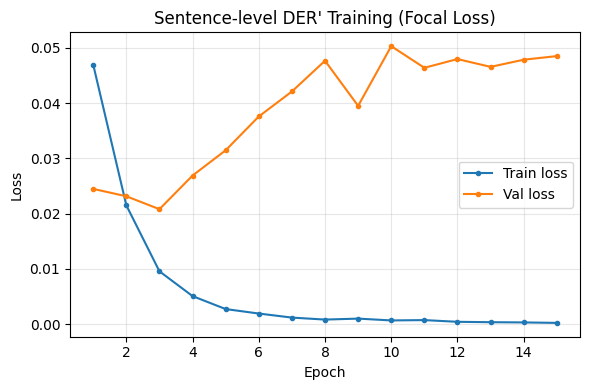

In [ ]:
# -------------------------
# 10. Training loop + best checkpoint
# -------------------------
SAVE_PATH = "/content/drive/MyDrive/DECEN/best_sentence_level_bert_focal.pt"
EPOCHS = 15
best_f1 = -1
best_epoch = -1
# LR = 2e-5
train_loss_hist, val_loss_hist, val_f1_hist = [], [], []

for epoch in range(1, EPOCHS + 1):
    tr_loss = train_one_epoch(model, train_loader)
    va_loss, p, r, f1, y_true, y_pred = run_eval(model, val_loader)

    train_loss_hist.append(tr_loss)
    val_loss_hist.append(va_loss)
    val_f1_hist.append(f1)

    print(f"[Epoch {epoch:02d}] TrainLoss={tr_loss:.4f} | ValLoss={va_loss:.4f} | P={p:.4f} R={r:.4f} F1(macro)={f1:.4f}")

    if f1 > best_f1:
        best_f1 = f1
        best_epoch = epoch
        torch.save({
            "model_state": model.state_dict(),
            "tokenizer_name": MODEL_NAME,
            "label2id": label2id,
            "id2label": id2label,
            "best_f1": best_f1,
            "best_epoch": best_epoch,
            "max_len": MAX_LEN
        }, SAVE_PATH)
        print(f"  ✅ Saved best model @ epoch {best_epoch} (F1={best_f1:.4f})")

print("\nBest F1:", best_f1, "Best epoch:", best_epoch)
print("\nClassification report (val, last epoch):")
print(classification_report(y_true, y_pred, target_names=[id2label[i] for i in range(num_classes)], digits=4))

# -------------------------
# 11. Plot loss curve (paper-style)
# -------------------------
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_loss_hist) + 1))
plt.figure(figsize=(6,4))
plt.plot(epochs, train_loss_hist, marker='o', markersize=3, label="Train loss")
plt.plot(epochs, val_loss_hist, marker='o', markersize=3, label="Val loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Sentence-level DER' Training (Focal Loss)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))
print("Confusion matrix:\n", cm)


Confusion matrix:
 [[646  49  16  10   5]
 [ 34 107   2   2   3]
 [ 21   6  40   0   0]
 [  7   4   0  15   0]
 [  4   1   1   0  24]]


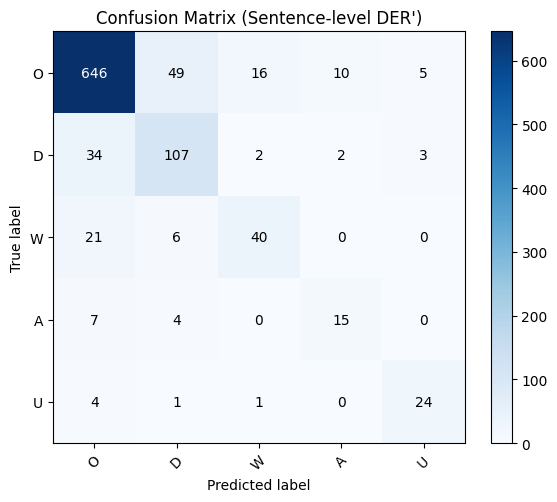

In [ ]:
import matplotlib.pyplot as plt

labels = [id2label[i] for i in range(num_classes)]

cm = confusion_matrix(y_true, y_pred, labels=list(range(num_classes)))

plt.figure(figsize=(6, 5))
plt.imshow(cm, interpolation="nearest",cmap="Blues")
plt.title("Confusion Matrix (Sentence-level DER')")
plt.colorbar()

tick_marks = np.arange(len(labels))
plt.xticks(tick_marks, labels, rotation=45)
plt.yticks(tick_marks, labels)

# 在格子中標數字
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(
            j, i, cm[i, j],
            ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black"
        )

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()


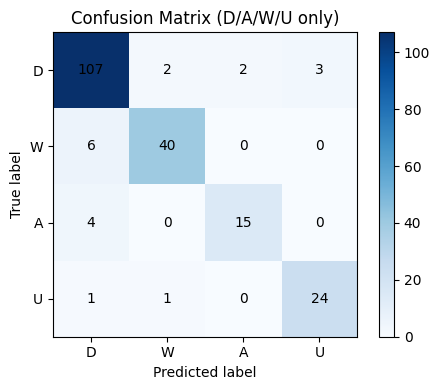

In [ ]:
# filter out O (label_id == 0)
filtered = [(t, p) for t, p in zip(y_true, y_pred) if t != label2id["O"]]

y_true_noO = [t for t, _ in filtered]
y_pred_noO = [p for _, p in filtered]

labels_noO = ["D", "W", "A", "U"]
label_ids_noO = [label2id[l] for l in labels_noO]

cm_noO = confusion_matrix(y_true_noO, y_pred_noO, labels=label_ids_noO)

plt.figure(figsize=(5, 4))
plt.imshow(cm_noO, interpolation="nearest",cmap="Blues")
plt.title("Confusion Matrix (D/A/W/U only)")
plt.colorbar()

tick_marks = np.arange(len(labels_noO))
plt.xticks(tick_marks, labels_noO)
plt.yticks(tick_marks, labels_noO)

for i in range(cm_noO.shape[0]):
    for j in range(cm_noO.shape[1]):
        plt.text(j, i, cm_noO[i, j], ha="center", va="center")

plt.ylabel("True label")
plt.xlabel("Predicted label")
plt.tight_layout()
plt.show()



# 標註一致性驗證
抽 300–500 句，由 2 位人工標註 D/A/W/U/O，計算 Cohen’s kappa

資料流程
1. 選擇當初由 DER′ 半自動標註、後續用於訓練 DECEN 的原始文本。
2. 排除 select_de_synold_filtered.csv 中出現過的 post_id，避免 DER′ 訓練資料洩漏。
3. 使用與 DER′ 訓練時完全相同的切句規則。
4. 載入 best_sentence_level_bert_focal.pt，對句子推論。


In [26]:
import re
import unicodedata
from pathlib import Path

import pandas as pd


# =========================
# 1. 路徑設定
# =========================
BASE_DIR = Path(r"D:\時間序列\DECEN")

DECEN_DATA_PATH = BASE_DIR / "post_level_dataset_800_plus_syn.csv"
DER_TRAIN_PATH = BASE_DIR / "select_de_synold_filtered.csv"

OUTPUT_PATH = BASE_DIR / "post_level_dataset_excluding_DER_train.csv"
EXCLUDED_PATH = BASE_DIR / "posts_used_in_DER_training.csv"
AUDIT_PATH = BASE_DIR / "DER_training_exclusion_audit.csv"


# =========================
# 2. Caption 正規化
# =========================
def normalize_caption(text):
    """
    僅統一不影響語意的文字格式：
    1. Unicode NFC
    2. Windows/Mac 換行轉為 \\n
    3. 移除每行尾端空白
    4. 移除整段前後空白

    不移除標點、emoji、hashtag 或句中空白。
    """
    if pd.isna(text):
        return ""

    text = str(text)
    text = unicodedata.normalize("NFC", text)
    text = text.replace("\r\n", "\n").replace("\r", "\n")
    text = "\n".join(line.rstrip() for line in text.split("\n"))
    return text.strip()


# =========================
# 3. 讀取資料
# =========================
decen_df = pd.read_csv(
    DECEN_DATA_PATH,
    encoding="utf-8-sig"
)

# DER′ 訓練資料為 token-level，
# 同一 caption 會重複多列，因此只讀 caption 欄位
der_train_df = pd.read_csv(
    DER_TRAIN_PATH,
    usecols=["caption"],
    encoding="utf-8-sig"
)

if "caption" not in decen_df.columns:
    raise ValueError(
        f"DECEN 資料缺少 caption 欄位：{decen_df.columns.tolist()}"
    )


# =========================
# 4. 建立正規化文字
# =========================
decen_df = decen_df.copy()

decen_df["_normalized_caption"] = (
    decen_df["caption"].map(normalize_caption)
)

der_train_captions = {
    normalize_caption(text)
    for text in der_train_df["caption"]
}

# 空字串不應作為排除依據
der_train_captions.discard("")


# =========================
# 5. 依 Caption 排除
# =========================
used_in_der_mask = (
    decen_df["_normalized_caption"].ne("")
    & decen_df["_normalized_caption"].isin(der_train_captions)
)

excluded_df = decen_df.loc[used_in_der_mask].copy()
remaining_df = decen_df.loc[~used_in_der_mask].copy()


# =========================
# 6. 建立排除稽核資料
# =========================
audit_df = decen_df[
    ["post_id", "caption", "_normalized_caption"]
].copy()

audit_df["used_in_DER_training"] = used_in_der_mask.to_numpy()
audit_df["exclusion_reason"] = ""

audit_df.loc[
    audit_df["used_in_DER_training"],
    "exclusion_reason"
] = "caption_matched_DER_training_data"


# =========================
# 7. 驗證結果
# =========================
assert len(decen_df) == len(excluded_df) + len(remaining_df)

remaining_overlap = (
    remaining_df["_normalized_caption"]
    .isin(der_train_captions)
    .sum()
)

assert remaining_overlap == 0, (
    f"排除後仍有 {remaining_overlap} 筆 caption 出現在 DER′ 訓練資料"
)

# 檢查正規化後是否有重複文本
duplicate_count = int(
    remaining_df["_normalized_caption"]
    .duplicated(keep=False)
    .sum()
)


# =========================
# 8. 輸出檔案
# =========================
# 正式資料不保留暫時正規化欄位
remaining_df.drop(
    columns=["_normalized_caption"]
).to_csv(
    OUTPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

excluded_df.drop(
    columns=["_normalized_caption"]
).to_csv(
    EXCLUDED_PATH,
    index=False,
    encoding="utf-8-sig"
)

audit_df.to_csv(
    AUDIT_PATH,
    index=False,
    encoding="utf-8-sig"
)


# =========================
# 9. 顯示摘要
# =========================
print("===== DER′ 訓練資料排除結果 =====")
print(f"DECEN 原始筆數：{len(decen_df)}")
print(f"DER′ 訓練資料的唯一 caption 數：{len(der_train_captions)}")
print(f"排除筆數：{len(excluded_df)}")
print(f"剩餘筆數：{len(remaining_df)}")
print(f"排除後仍重疊：{remaining_overlap}")
print(f"剩餘資料的重複 caption 筆數：{duplicate_count}")

print("\n輸出檔案：")
print(f"待 DER′ 推論資料：{OUTPUT_PATH}")
print(f"被排除資料：{EXCLUDED_PATH}")
print(f"排除稽核表：{AUDIT_PATH}")

===== DER′ 訓練資料排除結果 =====
DECEN 原始筆數：963
DER′ 訓練資料的唯一 caption 數：623
排除筆數：199
剩餘筆數：764
排除後仍重疊：0
剩餘資料的重複 caption 筆數：0

輸出檔案：
待 DER′ 推論資料：D:\時間序列\DECEN\post_level_dataset_excluding_DER_train.csv
被排除資料：D:\時間序列\DECEN\posts_used_in_DER_training.csv
排除稽核表：D:\時間序列\DECEN\DER_training_exclusion_audit.csv


In [33]:
# 若在 Colab 執行，請先把 CSV 放到 Google Drive，並修改下方路徑。

import re
from pathlib import Path

import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel


# ============================================================
# 1. 路徑及模型設定
# ============================================================
INPUT_CSV = Path(
    "D:/時間序列/DECEN/"
    "post_level_dataset_excluding_DER_train.csv"
)

CHECKPOINT_PATH = Path(
    "D:/時間序列/DECEN/"
    "best_sentence_level_bert_focal.pt"
)

OUTPUT_CSV = Path(
    "D:/時間序列/DECEN/"
    "DER_prime_sentence_predictions.csv"
)

MODEL_NAME = "bert-base-chinese"
MAX_LENGTH = 128
BATCH_SIZE = 32

POST_COL = "post_id"
TEXT_COL = "caption"

LABELS = ["O", "D", "W", "A", "U"]

label2id = {
    "O": 0,
    "D": 1,
    "W": 2,
    "A": 3,
    "U": 4
}

id2label = {value: key for key, value in label2id.items()}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# 2. 讀取資料
# ============================================================
post_df = pd.read_csv(
    INPUT_CSV,
    encoding="utf-8-sig"
)

required_columns = [POST_COL, TEXT_COL]
missing_columns = [
    column for column in required_columns
    if column not in post_df.columns
]

if missing_columns:
    raise ValueError(f"輸入資料缺少欄位：{missing_columns}")

post_df = post_df.copy()

post_df["original_caption"] = (
    post_df[TEXT_COL]
    .fillna("")
    .astype(str)
)


# ============================================================
# 3. 文本預處理
# ============================================================
URL_RE = re.compile(
    r"""
    (?:
        https?://[^\s]+
        |
        www\.[^\s]+
    )
    """,
    flags=re.IGNORECASE | re.VERBOSE
)

MENTION_RE = re.compile(r"@[^\s@#]+")
HASHTAG_RE = re.compile(r"#[^\s@#]+")


def preprocess_caption(text):
    text = str(text)

    # 統一換行
    text = text.replace("\r\n", "\n").replace("\r", "\n")

    # 移除 URL、@mention、#hashtag
    text = URL_RE.sub(" ", text)
    text = MENTION_RE.sub(" ", text)
    text = HASHTAG_RE.sub(" ", text)

    # 每行連續空白縮成一格，但保留換行供後續切句
    cleaned_lines = []

    for line in text.split("\n"):
        line = re.sub(r"[ \t\u3000]+", " ", line).strip()

        if line:
            cleaned_lines.append(line)

    return "\n".join(cleaned_lines).strip()


post_df["cleaned_caption"] = (
    post_df["original_caption"]
    .map(preprocess_caption)
)

empty_after_cleaning = (
    post_df["cleaned_caption"].str.len() == 0
).sum()

print("Post 數量：", len(post_df))
print("清理後空白 Post 數：", empty_after_cleaning)


# ============================================================
# 4. 切句
# ============================================================
SENT_SPLIT_RE = re.compile(r"([。！？!?\n]+)")


def split_sentences_with_spans(text):
    text = str(text)

    if not text.strip():
        return []

    parts = SENT_SPLIT_RE.split(text)

    sentences = []
    buffer = ""
    start = 0

    for part in parts:
        if part == "":
            continue

        buffer += part

        if SENT_SPLIT_RE.fullmatch(part):
            end = start + len(buffer)

            if buffer.strip():
                sentences.append((buffer, start, end))

            start = end
            buffer = ""

    if buffer.strip():
        end = start + len(buffer)
        sentences.append((buffer, start, end))

    return sentences


# ============================================================
# 5. 建立 Sentence-level 資料
# ============================================================
sentence_rows = []

for source_row_id, row in post_df.iterrows():
    post_id = row[POST_COL]
    original_caption = row["original_caption"]
    cleaned_caption = row["cleaned_caption"]

    sentence_spans = split_sentences_with_spans(
        cleaned_caption
    )

    for sentence_id, (sentence, start, end) in enumerate(
        sentence_spans
    ):
        cleaned_sentence = sentence.strip()

        if not cleaned_sentence:
            continue

        sentence_rows.append({
            "source_row_id": source_row_id,
            "post_id": post_id,
            "sentence_id": sentence_id,
            "text": cleaned_sentence,
            "cleaned_char_start": start,
            "cleaned_char_end": end
        })

sentence_df = pd.DataFrame(sentence_rows)

if sentence_df.empty:
    raise ValueError("預處理及切句後沒有任何有效句子。")

duplicate_keys = sentence_df.duplicated(
    subset=["source_row_id", "sentence_id"],
    keep=False
)

if duplicate_keys.any():
    raise ValueError(
        "發現重複的 source_row_id + sentence_id。"
    )

print("Sentence 數量：", len(sentence_df))
print(sentence_df.head())


# ============================================================
# 5. 先讀取 checkpoint 設定
# ============================================================
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=device,
    weights_only=False
)

if "model_state" not in checkpoint:
    raise KeyError(
        f"Checkpoint 找不到 model_state，目前 keys："
        f"{list(checkpoint.keys())}"
    )

checkpoint_tokenizer_name = checkpoint.get(
    "tokenizer_name",
    MODEL_NAME
)

checkpoint_max_length = int(
    checkpoint.get("max_len", MAX_LENGTH)
)

checkpoint_label2id = checkpoint.get(
    "label2id",
    label2id
)

checkpoint_label2id = {
    str(label): int(label_id)
    for label, label_id in checkpoint_label2id.items()
}

checkpoint_id2label = checkpoint.get("id2label")

if checkpoint_id2label is None:
    checkpoint_id2label = {
        label_id: label
        for label, label_id in checkpoint_label2id.items()
    }
else:
    checkpoint_id2label = {
        int(label_id): str(label)
        for label_id, label in checkpoint_id2label.items()
    }

print("Checkpoint tokenizer:", checkpoint_tokenizer_name)
print("Checkpoint max length:", checkpoint_max_length)
print("Checkpoint label2id:", checkpoint_label2id)
print("Checkpoint id2label:", checkpoint_id2label)
print("Best epoch:", checkpoint.get("best_epoch"))
print("Best F1:", checkpoint.get("best_f1"))


# ============================================================
# 6. 再建立 tokenizer 與 DataLoader
# ============================================================
tokenizer = AutoTokenizer.from_pretrained(
    checkpoint_tokenizer_name
)


class SentenceInferenceDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length):
        self.texts = (
            dataframe["text"]
            .fillna("")
            .astype(str)
            .tolist()
        )
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, index):
        encoded = self.tokenizer(
            self.texts[index],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoded["input_ids"].squeeze(0),
            "attention_mask": encoded[
                "attention_mask"
            ].squeeze(0)
        }


inference_dataset = SentenceInferenceDataset(
    dataframe=sentence_df,
    tokenizer=tokenizer,
    max_length=checkpoint_max_length
)

inference_loader = DataLoader(
    inference_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)


# ============================================================
# 7. 建立模型並載入權重
# ============================================================
class BertSentClassifier(nn.Module):
    def __init__(self, model_name, num_labels, dropout=0.1):
        super().__init__()

        self.bert = AutoModel.from_pretrained(model_name)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(
            self.bert.config.hidden_size,
            num_labels
        )

    def forward(self, input_ids, attention_mask):
        output = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_embedding = output.last_hidden_state[:, 0]
        cls_embedding = self.dropout(cls_embedding)

        return self.classifier(cls_embedding)


model = BertSentClassifier(
    model_name=checkpoint_tokenizer_name,
    num_labels=len(checkpoint_label2id),
    dropout=0.1
).to(device)

state_dict = checkpoint["model_state"]

clean_state_dict = {}

for key, value in state_dict.items():
    if key.startswith("module."):
        clean_key = key[len("module."):]
    else:
        clean_key = key

    clean_state_dict[clean_key] = value

model.load_state_dict(
    clean_state_dict,
    strict=True
)

model.eval()

print("DER′ checkpoint 載入成功")


# ============================================================
# 8. 執行 DER′ 推論
# ============================================================
predicted_ids = []
predicted_labels = []
predicted_confidences = []
all_probabilities = []

with torch.no_grad():
    for batch in inference_loader:
        input_ids = batch["input_ids"].to(
            device,
            non_blocking=True
        )

        attention_mask = batch["attention_mask"].to(
            device,
            non_blocking=True
        )

        logits = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        probabilities = torch.softmax(
            logits,
            dim=-1
        )

        confidence, prediction = torch.max(
            probabilities,
            dim=-1
        )

        batch_pred_ids = prediction.cpu().tolist()
        batch_confidences = confidence.cpu().tolist()
        batch_probabilities = probabilities.cpu().tolist()

        predicted_ids.extend(batch_pred_ids)
        predicted_confidences.extend(
            batch_confidences
        )
        all_probabilities.extend(
            batch_probabilities
        )

        predicted_labels.extend(
            checkpoint_id2label[pred_id]
            for pred_id in batch_pred_ids
        )


# ============================================================
# 9. 建立輸出資料
# ============================================================
if len(predicted_labels) != len(sentence_df):
    raise ValueError(
        "預測數量與句子數量不一致："
        f"{len(predicted_labels)} != {len(sentence_df)}"
    )

prediction_df = sentence_df.copy()

prediction_df["DER_prime_pred_id"] = predicted_ids
prediction_df["DER_prime_pred_label"] = predicted_labels
prediction_df["DER_prime_confidence"] = (
    predicted_confidences
)

# 各類別預測機率
for label, label_id in checkpoint_label2id.items():
    prediction_df[f"prob_{label}"] = [
        probabilities[int(label_id)]
        for probabilities in all_probabilities
    ]

output_columns = [
    "source_row_id",
    "post_id",
    "sentence_id",
    "text",
    "cleaned_char_start",
    "cleaned_char_end",
    "DER_prime_pred_id",
    "DER_prime_pred_label",
    "DER_prime_confidence",
    "prob_O",
    "prob_D",
    "prob_W",
    "prob_A",
    "prob_U"
]

prediction_df = prediction_df[output_columns]


# ============================================================
# 10. 輸出 CSV
# ============================================================
OUTPUT_CSV.parent.mkdir(
    parents=True,
    exist_ok=True
)

prediction_df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig"
)

print("\n===== DER′ 推論完成 =====")
print("Post 數量：", len(post_df))
print("Sentence 數量：", len(prediction_df))

print("\nDER′ 預測類別分布：")
print(
    prediction_df[
        "DER_prime_pred_label"
    ].value_counts()
)

print("\n平均預測信心：")
print(
    prediction_df[
        "DER_prime_confidence"
    ].mean()
)

print("\n輸出位置：")
print(OUTPUT_CSV)

Device: cuda
Post 數量： 764
清理後空白 Post 數： 0
Sentence 數量： 8317
   source_row_id         post_id  sentence_id                text  \
0              0  keke.lifediary            0  ‼️更正第8項為：誠品480商場‼️   
1              0  keke.lifediary            1       👇🏻加入keke大家庭👇🏻   
2              0  keke.lifediary            2          Keke 帶我去旅行   
3              0  keke.lifediary            3           Keke 吃貨日記   
4              0  keke.lifediary            4            Keke 住宿趣   

   cleaned_char_start  cleaned_char_end  
0                   0                19  
1                  19                33  
2                  33                44  
3                  44                54  
4                  54                62  
Checkpoint tokenizer: bert-base-chinese
Checkpoint max length: 128
Checkpoint label2id: {'O': 0, 'D': 1, 'W': 2, 'A': 3, 'U': 4}
Checkpoint id2label: {0: 'O', 1: 'D', 2: 'W', 3: 'A', 4: 'U'}
Best epoch: 15
Best F1: 0.7105974191758616


c:\Users\Angle\Anaconda3\lib\site-packages\transformers\tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


DER′ checkpoint 載入成功

===== DER′ 推論完成 =====
Post 數量： 764
Sentence 數量： 8317

DER′ 預測類別分布：
O    7246
D     620
W     238
U     153
A      60
Name: DER_prime_pred_label, dtype: int64

平均預測信心：
0.9331168359871365

輸出位置：
D:\時間序列\DECEN\DER_prime_sentence_predictions.csv


In [34]:
from pathlib import Path
import pandas as pd

INPUT_PATH = Path(
    r"D:\時間序列\DECEN\DER_prime_sentence_predictions.csv"
)

OUTPUT_DIR = Path(
    r"D:\時間序列\DER'_human_label\DER_prime_human_validation"
)

LABELS = ["O", "D", "W", "A", "U"]
SAMPLE_PER_LABEL = 60
RANDOM_STATE = 42

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =========================
# 1. 讀取預測結果
# =========================
df = pd.read_csv(INPUT_PATH, encoding="utf-8-sig")

required_columns = [
    "source_row_id",
    "post_id",
    "sentence_id",
    "text",
    "DER_prime_pred_label",
    "DER_prime_confidence"
]

missing = [c for c in required_columns if c not in df.columns]

if missing:
    raise ValueError(f"缺少欄位：{missing}")

df = df.copy()

df["text_normalized"] = (
    df["text"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["DER_prime_pred_label"] = (
    df["DER_prime_pred_label"]
    .fillna("")
    .astype(str)
    .str.strip()
    .str.upper()
)
print("預測檔修改時間：", INPUT_PATH.stat().st_mtime)
print("讀取句子數：", len(df))
print("欄位：", df.columns.tolist())

# =========================
# 2. 清理資料
# =========================
# 排除空句與無效模型標籤
eligible_df = df[
    df["text_normalized"].ne("")
    & df["DER_prime_pred_label"].isin(LABELS)
].copy()

# 相同文字只保留一次，避免重複標註
eligible_df = eligible_df.drop_duplicates(
    subset=["text_normalized"],
    keep="first"
).reset_index(drop=True)

print("可抽樣類別分布：")
print(
    eligible_df["DER_prime_pred_label"]
    .value_counts()
    .reindex(LABELS, fill_value=0)
)


# =========================
# 3. 檢查每類是否足夠
# =========================
class_counts = eligible_df[
    "DER_prime_pred_label"
].value_counts()

insufficient = {
    label: int(class_counts.get(label, 0))
    for label in LABELS
    if class_counts.get(label, 0) < SAMPLE_PER_LABEL
}

if insufficient:
    raise ValueError(
        f"以下類別不足 {SAMPLE_PER_LABEL} 句：{insufficient}"
    )


# =========================
# 4. 每類平衡抽樣
# =========================
sample_frames = []

for label in LABELS:
    class_df = eligible_df[
        eligible_df["DER_prime_pred_label"] == label
    ]

    sampled = class_df.sample(
        n=SAMPLE_PER_LABEL,
        random_state=RANDOM_STATE
    )

    sample_frames.append(sampled)

sample_df = pd.concat(
    sample_frames,
    ignore_index=True
)

# 打亂類別排列
sample_df = sample_df.sample(
    frac=1,
    random_state=RANDOM_STATE
).reset_index(drop=True)

# 使用隨機 sample_id，人工檔不顯示原始排列
sample_df.insert(
    0,
    "sample_id",
    [f"S{i:03d}" for i in range(1, len(sample_df) + 1)]
)


# =========================
# 5. 儲存含答案的對照檔
# =========================
answer_key_df = sample_df[
    [
        "sample_id",
        "source_row_id",
        "post_id",
        "sentence_id",
        "text",
        "DER_prime_pred_label",
        "DER_prime_confidence",
        "prob_O",
        "prob_D",
        "prob_W",
        "prob_A",
        "prob_U"
    ]
].copy()

answer_key_df.to_csv(
    OUTPUT_DIR / "DER_prime_validation_answer_key.csv",
    index=False,
    encoding="utf-8-sig"
)


# =========================
# 6. 建立兩份相同順序的盲標檔
# =========================
annotation_template = sample_df[
    ["sample_id", "text"]
].copy()

annotation_template["human_label"] = ""
annotation_template["note"] = ""

annotation_template.to_csv(
    OUTPUT_DIR / "DER_prime_annotation_annotator_1.csv",
    index=False,
    encoding="utf-8-sig"
)

annotation_template.to_csv(
    OUTPUT_DIR / "DER_prime_annotation_annotator_2.csv",
    index=False,
    encoding="utf-8-sig"
)


# =========================
# 7. 輸出摘要
# =========================
print("\n抽樣完成：")
print(f"總數：{len(sample_df)}")

print("\n各 DER′ 預測類別數：")
print(
    sample_df["DER_prime_pred_label"]
    .value_counts()
    .reindex(LABELS, fill_value=0)
)

print("\n輸出檔案：")
print(OUTPUT_DIR / "DER_prime_validation_answer_key.csv")
print(OUTPUT_DIR / "DER_prime_annotation_annotator_1.csv")
print(OUTPUT_DIR / "DER_prime_annotation_annotator_2.csv")

預測檔修改時間： 1781430921.8948863
讀取句子數： 8317
欄位： ['source_row_id', 'post_id', 'sentence_id', 'text', 'cleaned_char_start', 'cleaned_char_end', 'DER_prime_pred_id', 'DER_prime_pred_label', 'DER_prime_confidence', 'prob_O', 'prob_D', 'prob_W', 'prob_A', 'prob_U', 'text_normalized']
可抽樣類別分布：
O    6160
D     619
W     237
A      60
U     153
Name: DER_prime_pred_label, dtype: int64

抽樣完成：
總數：300

各 DER′ 預測類別數：
O    60
D    60
W    60
A    60
U    60
Name: DER_prime_pred_label, dtype: int64

輸出檔案：
D:\時間序列\DER'_human_label\DER_prime_human_validation\DER_prime_validation_answer_key.csv
D:\時間序列\DER'_human_label\DER_prime_human_validation\DER_prime_annotation_annotator_1.csv
D:\時間序列\DER'_human_label\DER_prime_human_validation\DER_prime_annotation_annotator_2.csv


===== 標註進度 =====
抽樣總數：300
Annotator 1 已標註：300
Annotator 2 已標註：300

===== Annotator 1 vs DER′ =====
有效標註數：300
label  human_annotation_count  agreement_count  per_class_agreement
    O                      92               48             0.521739
    D                      58               41             0.706897
    W                      56               43             0.767857
    A                      31               27             0.870968
    U                      63               53             0.841270
Overall agreement：0.7067
Macro per-class agreement：0.7417
Macro F1：0.7046
Cohen's kappa：0.6333


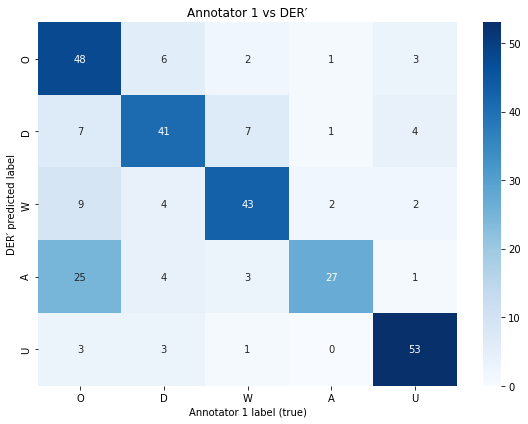


===== Annotator 2 vs DER′ =====
有效標註數：300
label  human_annotation_count  agreement_count  per_class_agreement
    O                     123               52             0.422764
    D                      41               30             0.731707
    W                      50               32             0.640000
    A                      31               26             0.838710
    U                      55               46             0.836364
Overall agreement：0.6200
Macro per-class agreement：0.6939
Macro F1：0.6231
Cohen's kappa：0.5250


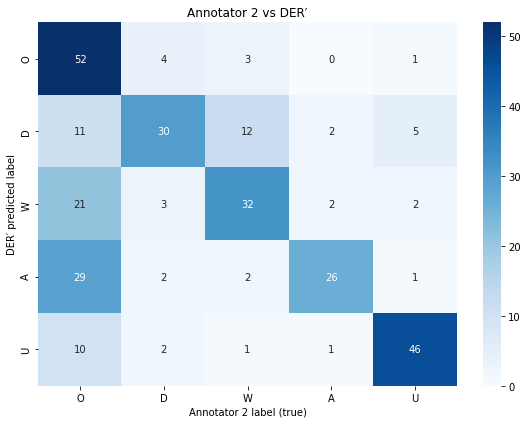


===== Annotator 1 vs Annotator 2 =====
共同完成數：300
Overall agreement：0.7833
Macro F1：0.7695
Cohen's kappa：0.7177


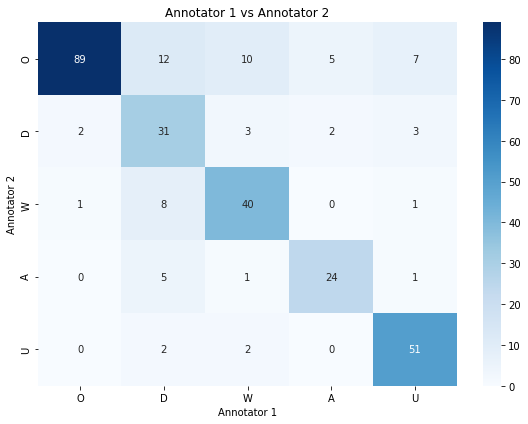


===== 輸出完成 =====
所有結果目錄：D:\時間序列\DER'_human_label\DER_prime_human_validation\analysis_results
不重複的不一致句子數：129
不一致資料： D:\時間序列\DER'_human_label\DER_prime_human_validation\analysis_results\all_annotation_disagreements.csv
整體指標： D:\時間序列\DER'_human_label\DER_prime_human_validation\analysis_results\all_agreement_metrics_summary.csv


In [87]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    confusion_matrix,
    cohen_kappa_score,
    f1_score
)


# ============================================================
# 0. 路徑與設定
# ============================================================
DATA_DIR = Path(
    r"D:\時間序列\DER'_human_label\DER_prime_human_validation"
)

DER_FILE = DATA_DIR / "DER_prime_validation_answer_key.csv"
ANNOTATOR_1_FILE = DATA_DIR / "DER_prime_annotation_annotator_1_v2.csv"
ANNOTATOR_2_FILE = DATA_DIR / "DER_prime_annotation_annotator_2_v3.csv"
# ANNOTATOR_2_FILE = DATA_DIR / "DER_prime_annotation_annotator_小明.csv"

OUTPUT_DIR = DATA_DIR / "analysis_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

KEY_COLS = ["sample_id"]
LABELS = ["O", "D", "W", "A", "U"]

DER_COL = "DER_prime_pred_label"
ANN1_COL = "annotator_1"
ANN2_COL = "annotator_2"


# ============================================================
# 1. 讀取資料
# ============================================================
der_df = pd.read_csv(
    DER_FILE,
    encoding="utf-8-sig"
)

ann1_df = pd.read_csv(
    ANNOTATOR_1_FILE,
    encoding="utf-8-sig"
).rename(
    columns={"human_label": ANN1_COL}
)

ann2_df = pd.read_csv(
    ANNOTATOR_2_FILE,
    encoding="utf-8-sig"
).rename(
    columns={"human_label": ANN2_COL}
)


# ============================================================
# 2. 檢查必要欄位
# ============================================================
required_der_columns = [
    "sample_id",
    "source_row_id",
    "post_id",
    "sentence_id",
    "text",
    DER_COL
]

required_ann1_columns = ["sample_id", ANN1_COL]
required_ann2_columns = ["sample_id", ANN2_COL]


def check_columns(dataframe, required_columns, file_name):
    missing = [
        column
        for column in required_columns
        if column not in dataframe.columns
    ]

    if missing:
        raise ValueError(
            f"{file_name} 缺少欄位：{missing}"
        )


check_columns(
    der_df,
    required_der_columns,
    DER_FILE.name
)

check_columns(
    ann1_df,
    required_ann1_columns,
    ANNOTATOR_1_FILE.name
)

check_columns(
    ann2_df,
    required_ann2_columns,
    ANNOTATOR_2_FILE.name
)


# 檢查 sample_id 是否唯一
for dataframe, file_path in [
    (der_df, DER_FILE),
    (ann1_df, ANNOTATOR_1_FILE),
    (ann2_df, ANNOTATOR_2_FILE)
]:
    if dataframe["sample_id"].duplicated().any():
        duplicated_ids = dataframe.loc[
            dataframe["sample_id"].duplicated(keep=False),
            "sample_id"
        ].tolist()

        raise ValueError(
            f"{file_path.name} 有重複 sample_id："
            f"{duplicated_ids[:10]}"
        )


# ============================================================
# 3. 合併 DER′ 與兩位人工標註
# ============================================================
eval_df = (
    der_df[
        [
            "sample_id",
            "source_row_id",
            "post_id",
            "sentence_id",
            "text",
            DER_COL,
            "DER_prime_confidence"
        ]
    ]
    .merge(
        ann1_df[["sample_id", ANN1_COL]],
        on="sample_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        ann2_df[["sample_id", ANN2_COL]],
        on="sample_id",
        how="left",
        validate="one_to_one"
    )
)

# 清理標籤
for column in [DER_COL, ANN1_COL, ANN2_COL]:
    eval_df[column] = (
        eval_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

print("===== 標註進度 =====")
print(f"抽樣總數：{len(eval_df)}")
print(
    f"Annotator 1 已標註："
    f"{eval_df[ANN1_COL].isin(LABELS).sum()}"
)
print(
    f"Annotator 2 已標註："
    f"{eval_df[ANN2_COL].isin(LABELS).sum()}"
)


# ============================================================
# 4. 人工標註 vs DER′
# ============================================================
def evaluate_against_der(
    dataframe,
    human_col,
    annotator_name
):
    valid_df = dataframe[
        dataframe[human_col].isin(LABELS)
        & dataframe[DER_COL].isin(LABELS)
    ].copy()

    if valid_df.empty:
        print(f"\n{annotator_name} 尚無有效標註。")
        return None

    # sklearn 原始格式：
    # row = 人工標註（true）
    # column = DER′ 預測（predict）
    cm = confusion_matrix(
        valid_df[human_col],
        valid_df[DER_COL],
        labels=LABELS
    )

    per_class_rows = []

    for index, label in enumerate(LABELS):
        human_count = int(cm[index, :].sum())
        agreement_count = int(cm[index, index])

        agreement = (
            agreement_count / human_count
            if human_count > 0
            else float("nan")
        )

        per_class_rows.append({
            "label": label,
            "human_annotation_count": human_count,
            "agreement_count": agreement_count,
            "per_class_agreement": agreement
        })

    per_class_df = pd.DataFrame(per_class_rows)

    # 僅平均人工標註中實際出現的類別
    macro_per_class_agreement = (
        per_class_df["per_class_agreement"]
        .mean(skipna=True)
    )

    # 固定以 DAWUO 五類計算
    macro_f1 = f1_score(
        valid_df[human_col],
        valid_df[DER_COL],
        labels=LABELS,
        average="macro",
        zero_division=0
    )

    overall_agreement = (
        valid_df[human_col]
        == valid_df[DER_COL]
    ).mean()

    kappa = cohen_kappa_score(
        valid_df[human_col],
        valid_df[DER_COL],
        labels=LABELS
    )

    print(f"\n===== {annotator_name} vs DER′ =====")
    print(f"有效標註數：{len(valid_df)}")
    print(per_class_df.to_string(index=False))
    print(f"Overall agreement：{overall_agreement:.4f}")
    print(
        "Macro per-class agreement："
        f"{macro_per_class_agreement:.4f}"
    )
    print(f"Macro F1：{macro_f1:.4f}")
    print(f"Cohen's kappa：{kappa:.4f}")

    # 儲存每類結果
    per_class_df.to_csv(
        OUTPUT_DIR / f"{human_col}_vs_DER_prime_metrics.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # 儲存整體結果
    summary_df = pd.DataFrame([{
        "comparison": f"{annotator_name} vs DER_prime",
        "valid_count": len(valid_df),
        "overall_agreement": overall_agreement,
        "macro_per_class_agreement": (
            macro_per_class_agreement
        ),
        "macro_f1": macro_f1,
        "cohen_kappa": kappa
    }])

    summary_df.to_csv(
        OUTPUT_DIR / f"{human_col}_vs_DER_prime_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # 轉置後：
    # X 軸 = 人工標註（true）
    # Y 軸 = DER′ 預測（predict）
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm.T,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABELS,
        yticklabels=LABELS
    )

    plt.xlabel(f"{annotator_name} label (true)")
    plt.ylabel("DER′ predicted label")
    plt.title(f"{annotator_name} vs DER′")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / f"{human_col}_vs_DER_prime_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    return summary_df


# 分別分析兩位標註者
ann1_summary = evaluate_against_der(
    eval_df,
    ANN1_COL,
    "Annotator 1"
)

ann2_summary = evaluate_against_der(
    eval_df,
    ANN2_COL,
    "Annotator 2"
)


# ============================================================
# 5. Annotator 1 vs Annotator 2
# ============================================================
both_annotated = eval_df[
    eval_df[ANN1_COL].isin(LABELS)
    & eval_df[ANN2_COL].isin(LABELS)
].copy()

inter_summary = None

if both_annotated.empty:
    print("\n目前沒有兩位標註者皆完成的共同樣本。")

else:
    # row = Annotator 1
    # column = Annotator 2
    inter_cm = confusion_matrix(
        both_annotated[ANN1_COL],
        both_annotated[ANN2_COL],
        labels=LABELS
    )

    inter_agreement = (
        both_annotated[ANN1_COL]
        == both_annotated[ANN2_COL]
    ).mean()

    inter_macro_f1 = f1_score(
        both_annotated[ANN1_COL],
        both_annotated[ANN2_COL],
        labels=LABELS,
        average="macro",
        zero_division=0
    )

    inter_kappa = cohen_kappa_score(
        both_annotated[ANN1_COL],
        both_annotated[ANN2_COL],
        labels=LABELS
    )

    print("\n===== Annotator 1 vs Annotator 2 =====")
    print(f"共同完成數：{len(both_annotated)}")
    print(f"Overall agreement：{inter_agreement:.4f}")
    print(f"Macro F1：{inter_macro_f1:.4f}")
    print(f"Cohen's kappa：{inter_kappa:.4f}")

    inter_summary = pd.DataFrame([{
        "comparison": "Annotator 1 vs Annotator 2",
        "valid_count": len(both_annotated),
        "overall_agreement": inter_agreement,
        "macro_per_class_agreement": float("nan"),
        "macro_f1": inter_macro_f1,
        "cohen_kappa": inter_kappa
    }])

    inter_summary.to_csv(
        OUTPUT_DIR / "annotator_1_vs_annotator_2_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # X 軸 = Annotator 1
    # Y 軸 = Annotator 2
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        inter_cm.T,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABELS,
        yticklabels=LABELS
    )

    plt.xlabel("Annotator 1")
    plt.ylabel("Annotator 2")
    plt.title("Annotator 1 vs Annotator 2")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR
        / "annotator_1_vs_annotator_2_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()


# ============================================================
# 6. 彙整所有整體指標
# ============================================================
summary_frames = [
    summary
    for summary in [
        ann1_summary,
        ann2_summary,
        inter_summary
    ]
    if summary is not None
]

if summary_frames:
    all_metrics_summary = pd.concat(
        summary_frames,
        ignore_index=True
    )

    all_metrics_summary.to_csv(
        OUTPUT_DIR / "all_agreement_metrics_summary.csv",
        index=False,
        encoding="utf-8-sig"
    )


# ============================================================
# 7. 彙整所有不一致項目
# 每個 sample_id 只輸出一次
# ============================================================
ann1_vs_der_disagree = (
    eval_df[ANN1_COL].isin(LABELS)
    & (eval_df[ANN1_COL] != eval_df[DER_COL])
)

ann2_vs_der_disagree = (
    eval_df[ANN2_COL].isin(LABELS)
    & (eval_df[ANN2_COL] != eval_df[DER_COL])
)

ann1_vs_ann2_disagree = (
    eval_df[ANN1_COL].isin(LABELS)
    & eval_df[ANN2_COL].isin(LABELS)
    & (eval_df[ANN1_COL] != eval_df[ANN2_COL])
)

any_disagreement = (
    ann1_vs_der_disagree
    | ann2_vs_der_disagree
    | ann1_vs_ann2_disagree
)

all_disagreements = eval_df.loc[
    any_disagreement
].copy()

all_disagreements[
    "annotator_1_vs_DER_disagree"
] = ann1_vs_der_disagree.loc[any_disagreement].to_numpy()

all_disagreements[
    "annotator_2_vs_DER_disagree"
] = ann2_vs_der_disagree.loc[any_disagreement].to_numpy()

all_disagreements[
    "annotator_1_vs_2_disagree"
] = ann1_vs_ann2_disagree.loc[any_disagreement].to_numpy()

all_disagreements = all_disagreements[
    [
        "sample_id",
        "source_row_id",
        "post_id",
        "sentence_id",
        "text",
        ANN1_COL,
        DER_COL,
        ANN2_COL,
        "DER_prime_confidence",
        "annotator_1_vs_DER_disagree",
        "annotator_2_vs_DER_disagree",
        "annotator_1_vs_2_disagree"
    ]
].sort_values("sample_id").reset_index(drop=True)

all_disagreements.to_csv(
    OUTPUT_DIR / "all_annotation_disagreements.csv",
    index=False,
    encoding="utf-8-sig"
)

print("\n===== 輸出完成 =====")
print(f"所有結果目錄：{OUTPUT_DIR}")
print(f"不重複的不一致句子數：{len(all_disagreements)}")
print(
    "不一致資料：",
    OUTPUT_DIR / "all_annotation_disagreements.csv"
)
print(
    "整體指標：",
    OUTPUT_DIR / "all_agreement_metrics_summary.csv"
)

In [88]:
# ============================================================
# 單獨輸出 Annotator 1 vs Annotator 2 不一致項目
# ============================================================
annotator_disagreements = eval_df[
    eval_df[ANN1_COL].isin(LABELS)
    & eval_df[ANN2_COL].isin(LABELS)
    & (eval_df[ANN1_COL] != eval_df[ANN2_COL])
][
    [
        "sample_id",
        "source_row_id",
        "post_id",
        "sentence_id",
        "text",
        ANN1_COL,
        ANN2_COL,
        DER_COL,
        "DER_prime_confidence"
    ]
].copy()

annotator_disagreements = (
    annotator_disagreements
    .sort_values("sample_id")
    .reset_index(drop=True)
)

annotator_disagreements.to_csv(
    OUTPUT_DIR / "annotator_1_vs_annotator_2_disagreements.csv",
    index=False,
    encoding="utf-8-sig"
)

print(
    "Annotator 1 vs Annotator 2 不一致筆數：",
    len(annotator_disagreements)
)
print(
    "輸出位置：",
    OUTPUT_DIR / "annotator_1_vs_annotator_2_disagreements.csv"
)

Annotator 1 vs Annotator 2 不一致筆數： 65
輸出位置： D:\時間序列\DER'_human_label\DER_prime_human_validation\analysis_results\annotator_1_vs_annotator_2_disagreements.csv


===== 人工標註可靠度 =====
共同完成數：300
Overall agreement：0.7833
Cohen's kappa：0.7177


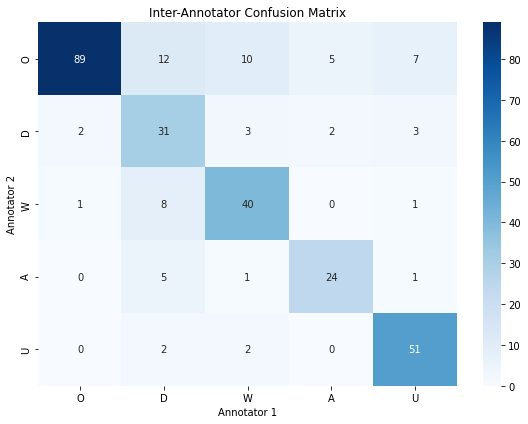


共識標註完成數：300
尚未完成數：0

===== DER′ 標註效能 =====
Macro F1：0.6665

Per-class precision / recall / F1：
label  precision   recall  f1_score  support
    O   0.833333 0.458716  0.591716      109
    D   0.550000 0.785714  0.647059       42
    W   0.633333 0.703704  0.666667       54
    A   0.483333 0.828571  0.610526       35
    U   0.816667 0.816667  0.816667       60


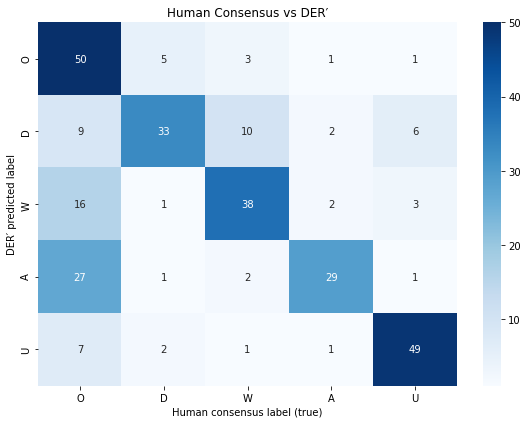


Human consensus vs DER′ 不一致數： 101


In [89]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    cohen_kappa_score,
    confusion_matrix,
    f1_score
)


# ============================================================
# 0. 路徑與設定
# ============================================================
DATA_DIR = Path(
    r"D:\時間序列\DER'_human_label\DER_prime_human_validation"
)

OUTPUT_DIR = DATA_DIR / "analysis_results"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DER_FILE = DATA_DIR / "DER_prime_validation_answer_key.csv"
ANNOTATOR_1_FILE = DATA_DIR / "DER_prime_annotation_annotator_1_v2.csv"
ANNOTATOR_2_FILE = DATA_DIR / "DER_prime_annotation_annotator_2_v3.csv"

# 第一次執行會建立此檔案。
# 完成人工共識標註後，再次執行本程式即可分析 DER′ 效能。
CONSENSUS_FILE = DATA_DIR / "human_consensus_annotation_A.csv"

LABELS = ["O", "D", "W", "A", "U"]


# ============================================================
# 1. 讀取並合併資料
# ============================================================
der_df = pd.read_csv(
    DER_FILE,
    encoding="utf-8-sig"
)

ann1_df = pd.read_csv(
    ANNOTATOR_1_FILE,
    encoding="utf-8-sig"
).rename(columns={"human_label": "annotator_1"})

ann2_df = pd.read_csv(
    ANNOTATOR_2_FILE,
    encoding="utf-8-sig"
).rename(columns={"human_label": "annotator_2"})

eval_df = (
    der_df[
        [
            "sample_id",
            "source_row_id",
            "post_id",
            "sentence_id",
            "text",
            "DER_prime_pred_label",
            "DER_prime_confidence"
        ]
    ]
    .merge(
        ann1_df[["sample_id", "annotator_1"]],
        on="sample_id",
        how="left",
        validate="one_to_one"
    )
    .merge(
        ann2_df[["sample_id", "annotator_2"]],
        on="sample_id",
        how="left",
        validate="one_to_one"
    )
)

for column in [
    "DER_prime_pred_label",
    "annotator_1",
    "annotator_2"
]:
    eval_df[column] = (
        eval_df[column]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )


# ============================================================
# 2. 人工標註可靠度
# Annotator 1 vs Annotator 2
# ============================================================
both_annotated = eval_df[
    eval_df["annotator_1"].isin(LABELS)
    & eval_df["annotator_2"].isin(LABELS)
].copy()

if both_annotated.empty:
    print("目前沒有兩位標註者共同完成的有效樣本。")

else:
    overall_agreement = accuracy_score(
        both_annotated["annotator_1"],
        both_annotated["annotator_2"]
    )

    inter_kappa = cohen_kappa_score(
        both_annotated["annotator_1"],
        both_annotated["annotator_2"],
        labels=LABELS
    )

    inter_cm = confusion_matrix(
        both_annotated["annotator_1"],
        both_annotated["annotator_2"],
        labels=LABELS
    )

    print("===== 人工標註可靠度 =====")
    print(f"共同完成數：{len(both_annotated)}")
    print(f"Overall agreement：{overall_agreement:.4f}")
    print(f"Cohen's kappa：{inter_kappa:.4f}")

    reliability_summary = pd.DataFrame([{
        "comparison": "Annotator 1 vs Annotator 2",
        "sample_count": len(both_annotated),
        "overall_agreement": overall_agreement,
        "cohen_kappa": inter_kappa
    }])

    reliability_summary.to_csv(
        OUTPUT_DIR / "inter_annotator_reliability.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # X 軸 Annotator 1，Y 軸 Annotator 2
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        inter_cm.T,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=LABELS,
        yticklabels=LABELS
    )

    plt.xlabel("Annotator 1")
    plt.ylabel("Annotator 2")
    plt.title("Inter-Annotator Confusion Matrix")
    plt.tight_layout()

    plt.savefig(
        OUTPUT_DIR / "inter_annotator_confusion_matrix.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

    # 單獨輸出兩位標註者不一致的項目
    annotator_disagreements = both_annotated[
        both_annotated["annotator_1"]
        != both_annotated["annotator_2"]
    ][
        [
            "sample_id",
            "source_row_id",
            "post_id",
            "sentence_id",
            "text",
            "annotator_1",
            "annotator_2",
            "DER_prime_pred_label"
        ]
    ].copy()

    annotator_disagreements["consensus_label"] = ""
    annotator_disagreements["consensus_note"] = ""

    annotator_disagreements.to_csv(
        OUTPUT_DIR / "annotator_disagreements_for_review.csv",
        index=False,
        encoding="utf-8-sig"
    )


# ============================================================
# 3. 建立人工共識標註檔
# 相同標註自動採用；不一致項目留白待討論
# ============================================================
consensus_template = both_annotated[
    [
        "sample_id",
        "source_row_id",
        "post_id",
        "sentence_id",
        "text",
        "annotator_1",
        "annotator_2",
        "DER_prime_pred_label"
    ]
].copy()

consensus_template["human_consensus_label"] = ""

same_mask = (
    consensus_template["annotator_1"]
    == consensus_template["annotator_2"]
)

consensus_template.loc[
    same_mask,
    "human_consensus_label"
] = consensus_template.loc[same_mask, "annotator_1"]

consensus_template["consensus_note"] = ""

# 不覆寫已存在且可能已人工編輯的共識檔
if not CONSENSUS_FILE.exists():
    consensus_template.to_csv(
        CONSENSUS_FILE,
        index=False,
        encoding="utf-8-sig"
    )

    print(f"\n已建立人工共識標註檔：{CONSENSUS_FILE}")
    print("請填寫空白的 human_consensus_label 後重新執行。")


# ============================================================
# 4. DER′ 標註效能
# Human consensus vs DER′
# ============================================================
if CONSENSUS_FILE.exists():
    consensus_df = pd.read_csv(
        CONSENSUS_FILE,
        encoding="utf-8-sig"
    )

    if "human_consensus_label" not in consensus_df.columns:
        raise ValueError(
            "共識檔缺少 human_consensus_label 欄位。"
        )

    consensus_df["human_consensus_label"] = (
        consensus_df["human_consensus_label"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    consensus_df["DER_prime_pred_label"] = (
        consensus_df["DER_prime_pred_label"]
        .fillna("")
        .astype(str)
        .str.strip()
        .str.upper()
    )

    valid_consensus = consensus_df[
        consensus_df["human_consensus_label"].isin(LABELS)
        & consensus_df["DER_prime_pred_label"].isin(LABELS)
    ].copy()

    incomplete_count = (
        len(consensus_df) - len(valid_consensus)
    )

    print(f"\n共識標註完成數：{len(valid_consensus)}")
    print(f"尚未完成數：{incomplete_count}")

    if not valid_consensus.empty:
        y_true = valid_consensus["human_consensus_label"]
        y_pred = valid_consensus["DER_prime_pred_label"]

        macro_f1 = f1_score(
            y_true,
            y_pred,
            labels=LABELS,
            average="macro",
            zero_division=0
        )

        report = classification_report(
            y_true,
            y_pred,
            labels=LABELS,
            target_names=LABELS,
            output_dict=True,
            zero_division=0
        )

        per_class_df = pd.DataFrame([
            {
                "label": label,
                "precision": report[label]["precision"],
                "recall": report[label]["recall"],
                "f1_score": report[label]["f1-score"],
                "support": int(report[label]["support"])
            }
            for label in LABELS
        ])

        print("\n===== DER′ 標註效能 =====")
        print(f"Macro F1：{macro_f1:.4f}")
        print("\nPer-class precision / recall / F1：")
        print(per_class_df.to_string(index=False))

        per_class_df.to_csv(
            OUTPUT_DIR / "DER_prime_per_class_metrics.csv",
            index=False,
            encoding="utf-8-sig"
        )

        der_summary = pd.DataFrame([{
            "comparison": "Human consensus vs DER_prime",
            "sample_count": len(valid_consensus),
            "macro_f1": macro_f1
        }])

        der_summary.to_csv(
            OUTPUT_DIR / "DER_prime_performance_summary.csv",
            index=False,
            encoding="utf-8-sig"
        )

        der_cm = confusion_matrix(
            y_true,
            y_pred,
            labels=LABELS
        )

        # X 軸人工共識 true label，Y 軸 DER′ prediction
        plt.figure(figsize=(8, 6))

        sns.heatmap(
            der_cm.T,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=LABELS,
            yticklabels=LABELS
        )

        plt.xlabel("Human consensus label (true)")
        plt.ylabel("DER′ predicted label")
        plt.title("Human Consensus vs DER′")
        plt.tight_layout()

        plt.savefig(
            OUTPUT_DIR
            / "human_consensus_vs_DER_prime_confusion_matrix.png",
            dpi=300,
            bbox_inches="tight"
        )
        plt.show()

        # 輸出人工共識與 DER′ 不一致項目
        der_disagreements = valid_consensus[
            valid_consensus["human_consensus_label"]
            != valid_consensus["DER_prime_pred_label"]
        ].copy()

        der_disagreements.to_csv(
            OUTPUT_DIR
            / "human_consensus_vs_DER_prime_disagreements.csv",
            index=False,
            encoding="utf-8-sig"
        )

        print(
            "\nHuman consensus vs DER′ 不一致數：",
            len(der_disagreements)
        )